# Bigquery Project
- 공휴일 신규 사용자 유입 패턴을 통한 배달 플랫폼 성장 정체 원인 분석

## 1. 앱에 존재하는 이벤트 파악
→ 각각의 event_name에 DISTINCT 명령어 적용해 파악

→ 및 각각의 이벤트 전후 페이지 파악

### 1-1. screen_view

- Explanation

    → 사용자가 앱을 사용하며 이동한 화면들을 보여줌

- Question

    → screen_view를 통해 각각의 이벤트가 발생한 화면 파악

- event_key
    1. firebase_screen
        
        → welcome

        → home
        
        → search
        
        → search_result
        
        → food_category
        
        → restaurant
        
        → food_detail
        
        → cart

### 1-2. click_login

- Explanation

    → Welcome 화면에서 발생

- Question

    → 비회원/회원 비율 파악
        
    → 로그인창에서 이탈하는 유저 파악

- event_key
    1. firebase_screen
        
        → Welcome 화면에서 로그인 버튼 누르기
        
        → <mark>screen_view(welcome) → click_login(welcome) → screen_view(home) 순서면 로그인 성공</mark>

### 1-3. click_banner

- Explanation
    
    → Home 화면에서 배너 누르면 다른 랜딩 페이지가 열림
- Question
    
    → Home 화면에서 배너 광고를 클릭해보는 사용자는 전환까지 이어지는 비율 파악
    
    → banner_id의 값과 restaurant_id, category_id, food_id 중 겹치는게 있는지 확인하여 광고 효과 파악

- event_key
    1. firebase_screen
        
        → Home 화면에서만 발생
        
        → 광고 효율성 체크
        
    2. banner_id
        
        → 어떤 배너 광고를 눌렀는지 숫자형으로 제공 (정확히 어떤 광고인지는 해당 정보만으로는 파악 불가)

### 1-4. click_search

- Explanation

    → Home 화면에서 Search 화면으로 이동

- event_key
    1. firebase_screen
        
        → Home 화면에서 검색창을 눌러서 이동

### 1-5. request_search

- Explanation

    → Search 화면에서 Search_result 화면으로 이동

- Question

    → 가장 많이 검색해본 키워드 파악

- event_key
    1. firebase_screen
    
        → Search 화면에서만 발생
    
        → Search 화면에서 검색한 결과 파악 가능
    
    2. search_keyword
    
        → 유저들이 검색해본 키워드 파악 가능

### 1-6. click_food_category

- Explanation

    → Home 화면에서 Food_category 화면으로 이동

- Question

    → 사용자들이 어떤 종류의 음식을 많이 찾아보는지 파악

- event_key
    1. firebase_screen
    
        → Home 화면에서만 발생
    
    2. food_category
    
        → Home 화면에서 8가지 음식 카테고리 중 하나 선택

### 1-7 click_restaurant_nearby

- Explanation

    → Home 화면에서 Restaurant 화면으로 이동

- event_key
    1. firebase_screen
    
        → Home 화면에서만 발생
    
        → 동네 맛집 누르면 이동하는 듯
    
    2. restaurant_id
    
        → 음식점 정보 정수값으로 이동

### 1-8 click_restaurant

- Explanation

    → Search_result, Food_category 화면에서 Restaurant으로 이동

- Question

    → 어떤 경로로 음식점으로 진입하는지 파악

- event_key
    1. firebase_screen
    
        → ‘search_result’ / ’food_category’ 값으로 존재
    
    2. restaurant_id
    
        → 음식점 정보 제공

### 1-9 click_food

- Explanation

    → Restaurant 화면에서 Food_detail 화면로 이동

- event_key
    1. firebase_screen
        
        → Restaurant 화면에서 음식 클릭
        
    2. food_id
        
        → 음식 정보를 정수값으로 제공

### 1-10 click_recommend_food

- Explanation

    → Home 화면에서 Food_detail 화면으로 이동

- event_key
    1. firebase_screen
    
        → Home 화면에서만 발생
    
        → Home 화면에 있는 추천 음식 누르면 이동
    
    2. food_id
    
        → 어떤 음식인지 정보를 정수값으로 제공

### 1-11 click_cart

- Explanation

    → Food_detail 화면에서 Cart 화면으로 이동

- event_key
    1. firebase_screen
    
        → Food_detail 화면에서(음식 상세보기) 장바구니에 음식 추가
    
    2. food_id
    
        → 추가하는 음식 정보 제공

### 1-12 view_recommend_extra_food

- Explanation

    → Cart 화면에서 확인

- event_key
    1. firebase_screen
    
        → Cart 화면에서만 발생
    
    2. food_id
    
        → 추가적으로 더 담으려고 하는 음식의 정보를 정수형으로 제공
    
    3. is_meet_min_order_price
    
        → 0/1 값 존재
    
        → 0 이면 최소 주문 금액을 충족하지 못하여 추천 음식을 더 담으려고 하는 경우
    
        → 1 이면 최소 주문 금액을 충족하였지만 추천 음식을 더 담으려고 하는 경우

### 1-13 click_recommend_extra_food

- Explanation

    → Cart 화면에서 확인

    → 마음에 드는 extra_food가 있다면 장바구니에 추가

- Question

    → view_recommend_extra_food에서 클릭하지 않고 이탈하는 비율 파악

    → 어떤 경우에서 해당 버튼을 이탈하지 않고 더 많이 클릭하는지 파악

- event_key
    1. firebase_screen
    
        → Cart 화면에서만 발생
    
    2. food_id
    
        → 추가적으로 더 담으려고 하는 음식의 정보를 정수형으로 제공
    
    3. is_meet_min_order_price
    
        → 0/1 값 존재
    
        → 0 이면 최소 주문 금액을 충족하지 못하여 추천 음식을 더 담으려고 하는 경우
    
        → 1 이면 최소 주문 금액을 충족하였지만 추천 음식을 더 담으려고 하는 경우

### 1-14 click_payment 🚨<mark>전환</mark>🚨

- Explanation

    → 최종 전환 이벤트

- Question

    → 추천 음식을 주문하는지 하지 않는지 파악

    → 앱에서 제공하는 결제수단의 사용 비율 파악

- event_key
    1. firebase_screen
    
        → Cart 화면에서만 발생
    
    2. use_recommend_food
    
        → True/False값으로 존재
    
    3. payment_type
    
        → foodiepay/card 존재
    
        → 결제 타입 두 가지 존재

## 2. 앱 현황 파악
데이터 수집기간: 2022-08-01 ~ 2023-01-20

### 2-1. 활성 접속 구분하기
<mark>조건: 2개 이상의 이벤트 발생(처음 welcome 화면 벗어나기)</mark>

→ 앱 키자마자 이탈하는 유저 비율 파악 가능

→ 유저ID와 세션ID 그룹화하여 유저별 방문 횟수 파악 가능

#### 활성 접속 로그 만들기
→ 활성 접속: 105,080건

``` sql
CREATE OR REPLACE TABLE `foodie.activate_user_log` AS
WITH base AS (
  SELECT
    user_pseudo_id,
    DATETIME(TIMESTAMP_MICROS(event_timestamp), 'Asia/Seoul') AS `event_datetime`, 
    event_name,
    event_params,
    platform
  FROM foodie.app_log
), event_datetime_diff AS (
  SELECT
    *,
    DATETIME_DIFF(event_datetime, LAG(event_datetime) OVER (PARTITION BY user_pseudo_id ORDER BY event_datetime), SECOND) AS `pre_datetime_diff`
  FROM base
  
), check_session AS (
  SELECT
    *,
    # 첫 방문이라서 null인 경우, 혹은 마지막 로그 이후 20분 이상 지났으면 새로운 세션으로 정의
    IF(pre_datetime_diff IS NULL OR pre_datetime_diff >= 1200, 1, NULL) AS check_new_session
  FROM event_datetime_diff
), define_session AS (
  SELECT
    *,
    SUM(check_new_session) OVER (PARTITION BY user_pseudo_id ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW) AS `session_id`
  FROM check_session
  ORDER BY user_pseudo_id, event_datetime
), activate_user AS (
  # 활성 사용자 기준
  # 확인한 페이지가 2 페이지 이상 -> welcome 페이지에서 바로 이탈하지 않은 경우
  SELECT
    *,
    COUNT(event_name) OVER (PARTITION BY user_pseudo_id, session_id) AS `total_session_cnt`
  FROM define_session
  QUALIFY total_session_cnt >= 2
), not_activate_user AS (
  SELECT
    *,
    COUNT(event_name) OVER (PARTITION BY user_pseudo_id, session_id) AS `total_session_cnt`
  FROM define_session
  QUALIFY total_session_cnt <= 1
)

SELECT
  user_pseudo_id,
  DATE(event_datetime) AS `event_date`,
  event_datetime,
  session_id,
  event_name,
  event_params,
  platform
FROM activate_user;
```

---

``` sql
# 파티셜 설정
CREATE OR REPLACE TABLE `foodie.activate_user_logs`
PARTITION BY event_date
 AS
SELECT
 *
FROM foodie.activate_user_log;
```

#### 비활성 접속 로그 만들기
→ 비활성 접속: 21,287건

``` sql
CREATE OR REPLACE TABLE `foodie.not_activate_user_log` AS
WITH base AS (
  SELECT
    user_pseudo_id,
    DATETIME(TIMESTAMP_MICROS(event_timestamp), 'Asia/Seoul') AS `event_datetime`, 
    event_name,
    event_params,
    platform
  FROM foodie.app_log
  # WHERE event_date BETWEEN '2022-08-01' AND '2022-08-15'
), event_datetime_diff AS (
  SELECT
    *,
    DATETIME_DIFF(event_datetime, LAG(event_datetime) OVER (PARTITION BY user_pseudo_id ORDER BY event_datetime), SECOND) AS `pre_datetime_diff`
  FROM base
  
), check_session AS (
  SELECT
    *,
    # 첫 방문이라서 null인 경우, 혹은 마지막 로그 이후 20분 이상 지났으면 새로운 세션으로 정의
    IF(pre_datetime_diff IS NULL OR pre_datetime_diff >= 1200, 1, NULL) AS check_new_session
  FROM event_datetime_diff
), define_session AS (
  SELECT
    *,
    SUM(check_new_session) OVER (PARTITION BY user_pseudo_id ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW) AS `session_id`
  FROM check_session
  ORDER BY user_pseudo_id, event_datetime
), activate_user AS (
  # 활성 사용자 기준
  # 확인한 페이지가 2 페이지 이상 -> welcome 페이지에서 바로 이탈하지 않은 경우
  SELECT
    *,
    COUNT(event_name) OVER (PARTITION BY user_pseudo_id, session_id) AS `total_session_cnt`
  FROM define_session
  QUALIFY total_session_cnt >= 2
), not_activate_user AS (
  SELECT
    *,
    COUNT(event_name) OVER (PARTITION BY user_pseudo_id, session_id) AS `total_session_cnt`
  FROM define_session
  QUALIFY total_session_cnt <= 1
)

SELECT
  user_pseudo_id,
  DATE(event_datetime) AS `event_date`,
  event_datetime,
  session_id,
  event_name,
  event_params,
  platform
FROM not_activate_user;
```

---

``` sql
# 파티션 설정
CREATE OR REPLACE TABLE `foodie.not_activate_user_logs`
PARTITION BY event_date
 AS
SELECT
 *
FROM foodie.not_activate_user_log;
```

### 2-2. 비활성 접속 탐색

#### 일별 비활성 접속 수
→ 비활성 접속 수가 10월(초)까지 계속 증가하다가 그 이후로 감소하는 추세

``` sql
SELECT
  event_date,
  COUNT(DISTINCT(user_pseudo_id)) `daily_not_activate_user_cnt`
FROM foodie.not_activate_user_logs
GROUP BY event_date
ORDER BY event_date;
```

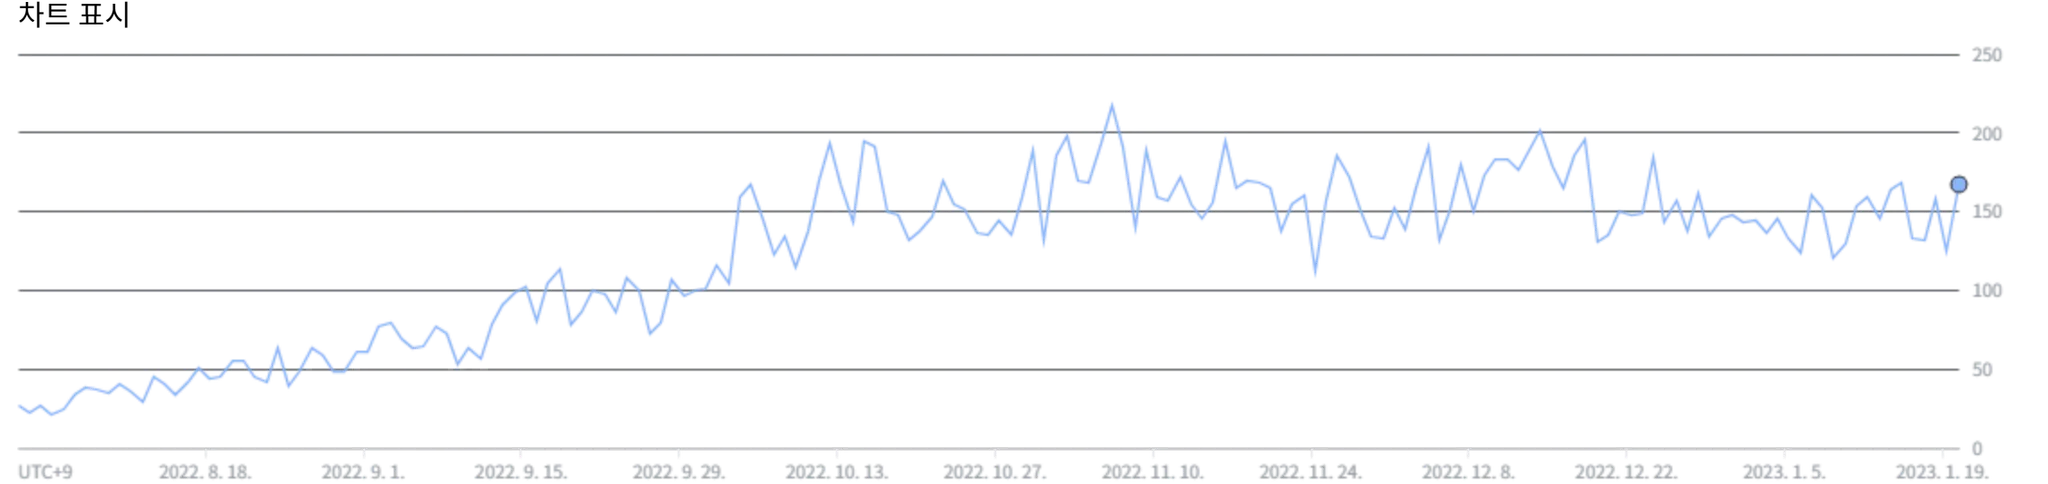

#### 일별 비활성 접속 수의 비율

``` sql
WITH daily_not_act_user_cnt AS (
  SELECT
    event_date,
    COUNT(DISTINCT(user_pseudo_id)) `daily_not_activate_user_cnt`
  FROM foodie.not_activate_user_logs
  GROUP BY event_date
), daily_act_user_cnt AS (
  SELECT
    event_date,
    COUNT(DISTINCT(user_pseudo_id)) `daily_activate_user_cnt`
  FROM foodie.activate_user_logs
  GROUP BY event_date
)

SELECT
  act.event_date,
  daily_activate_user_cnt,
  daily_not_activate_user_cnt,
  daily_activate_user_cnt + daily_not_activate_user_cnt AS `sum_of_user_cnt`,
  ROUND(SAFE_DIVIDE(daily_not_activate_user_cnt, daily_activate_user_cnt + daily_not_activate_user_cnt), 2) AS `not_activate_ratio`
FROM daily_act_user_cnt AS act 
  LEFT JOIN daily_not_act_user_cnt AS not_act ON not_act.event_date = act.event_date
ORDER BY act.event_date;
```

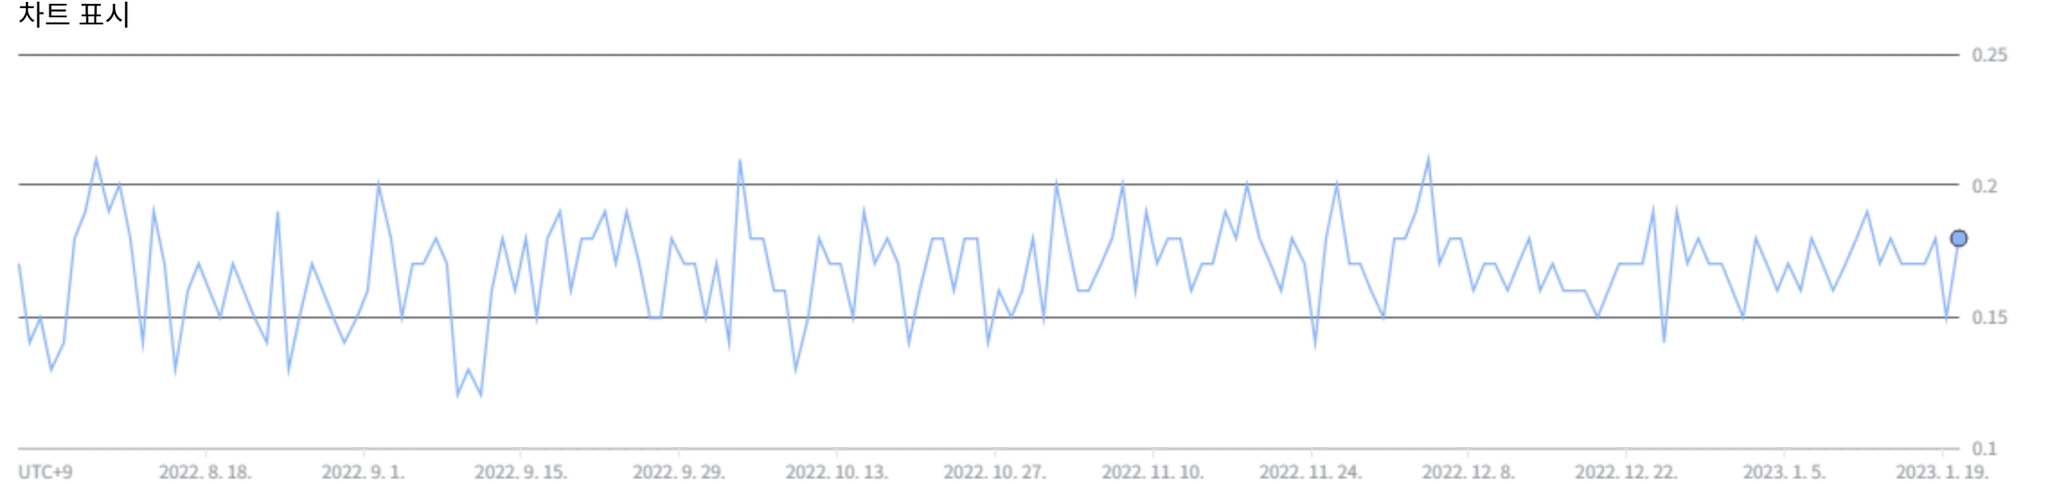

#### 비활성 접속 일별 리텐션

```sql
WITH base AS (
  SELECT
    DISTINCT
      user_pseudo_id,
      event_date
  FROM foodie.not_activate_user_logs
), cal_diff_of_event_date AS (
  SELECT
    user_pseudo_id,
    event_date,
    DATE_DIFF(event_date ,first_event_date, DAY) AS `diff_of_event_date`
  FROM (
    SELECT
      *,
      MIN(event_date) OVER (PARTITION BY user_pseudo_id) AS `first_event_date`
    FROM base
  )
), retention_day_cnt AS (
  SELECT
    diff_of_event_date,
    COUNT(diff_of_event_date) AS `retention_cnt`,
    FIRST_VALUE(COUNT(diff_of_event_date)) OVER (ORDER BY diff_of_event_date) AS `first_retentio_cnt`
  FROM cal_diff_of_event_date
  GROUP BY diff_of_event_date
)

SELECT
  *,
  ROUND(SAFE_DIVIDE(retention_cnt, first_retentio_cnt), 3) AS `retention_ratio`
FROM retention_day_cnt
ORDER BY diff_of_event_date;
```

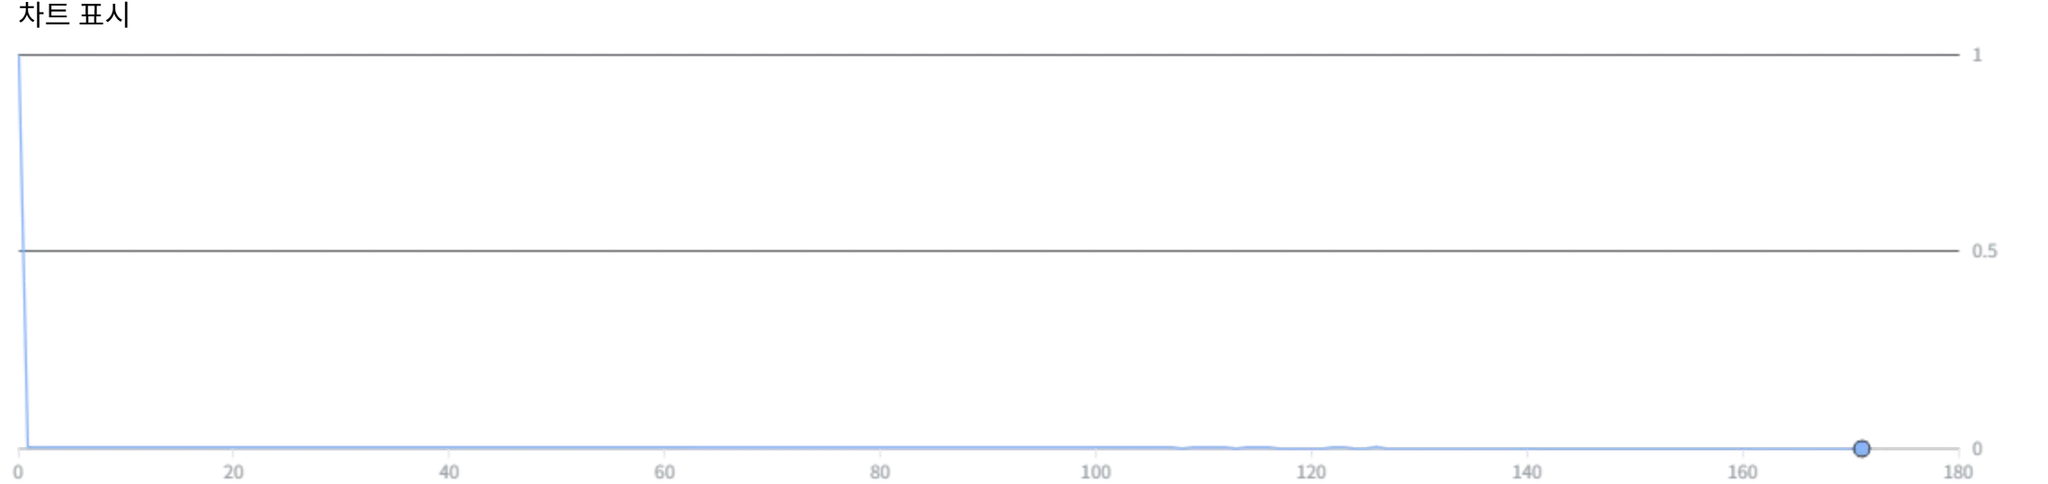

#### 주별 비활성 접속 수

``` sql
SELECT
  event_week,
  COUNT(DISTINCT(user_pseudo_id)) AS `weekly_not_activate_user_cnt`
FROM (
  SELECT
    user_pseudo_id,
    DATE_TRUNC(event_date, WEEK(MONDAY)) AS `event_week`
  FROM foodie.not_activate_user_logs
  )
GROUP BY event_week
ORDER BY event_week;
```

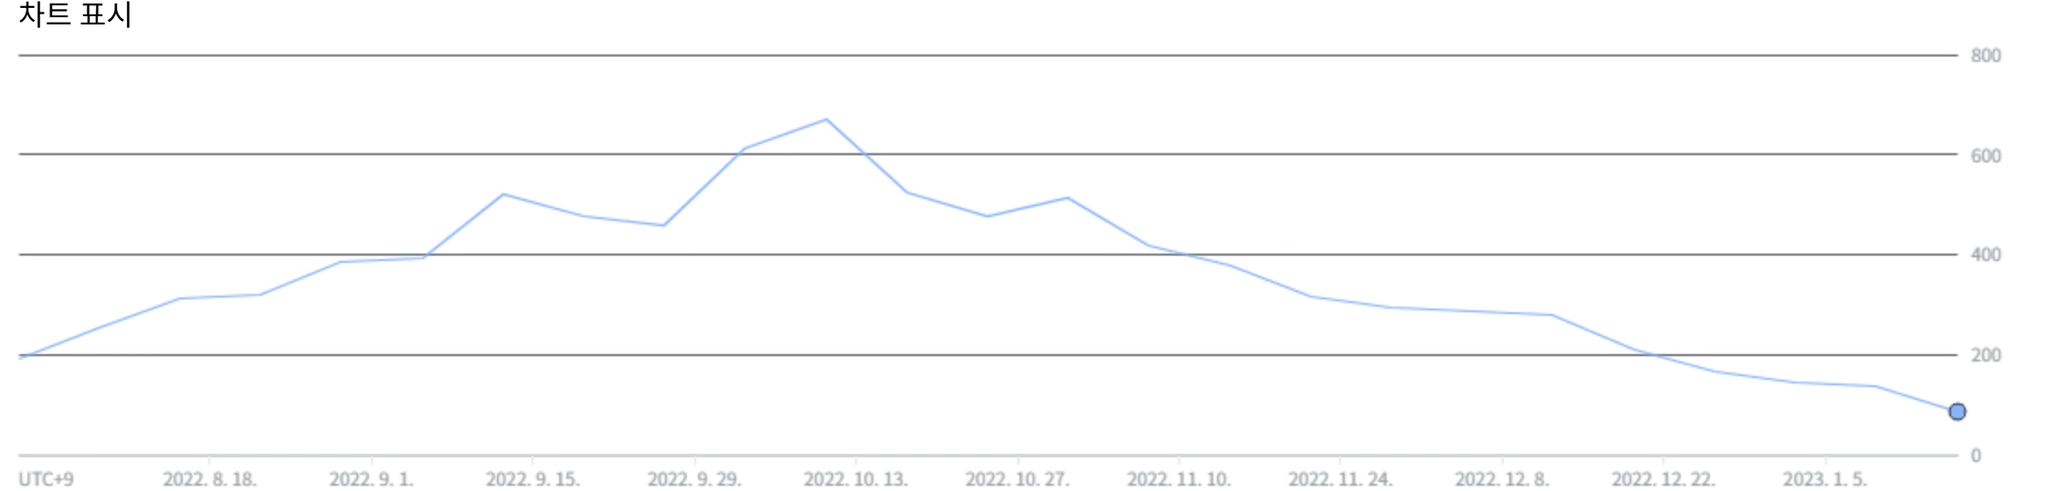

#### 비활성 접속 Weekly 리텐션

``` sql
WITH base AS (
  SELECT
    *,
    DATE_DIFF(event_week, first_event_week, week) AS event_week_diff
  FROM (
    SELECT
      user_pseudo_id,
      MIN(DATE_TRUNC(event_date, WEEK(MONDAY))) OVER (PARTITION BY user_pseudo_id) AS `first_event_week`,
      DATE_TRUNC(event_date, WEEK(MONDAY)) AS `event_week`
    FROM foodie.not_activate_user_logs
    )
)

SELECT
  event_week_diff,
  COUNT(*) AS `retention_cnt`
FROM base
GROUP BY event_week_diff
ORDER BY event_week_diff;
```

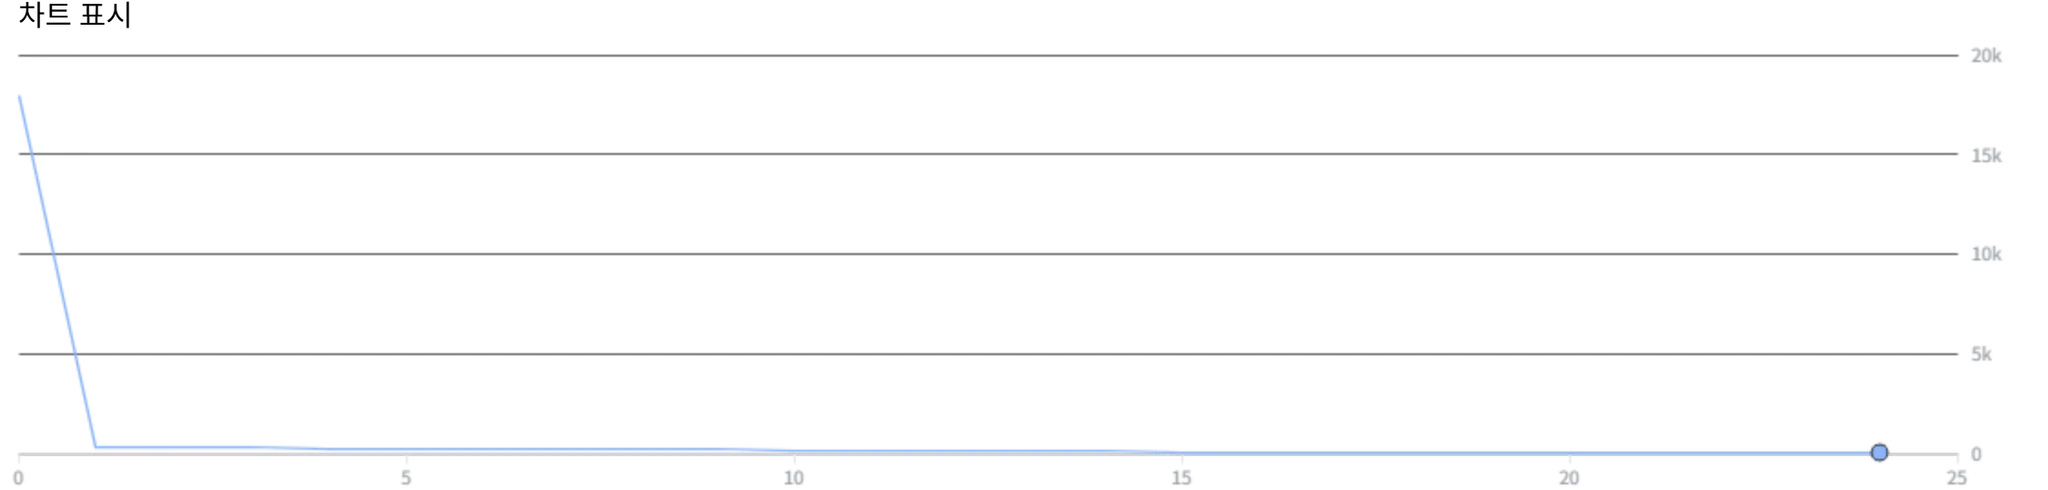

#### 월별 비활성 접속 수

``` sql
SELECT
  event_month,
  COUNT(DISTINCT(user_pseudo_id)) AS `monthly_not_activate_user_cnt`
FROM (
  SELECT
    user_pseudo_id,
    DATE_TRUNC(event_date, MONTH) AS `event_month`
  FROM foodie.not_activate_user_logs
  )
GROUP BY event_month
ORDER BY event_month;
```

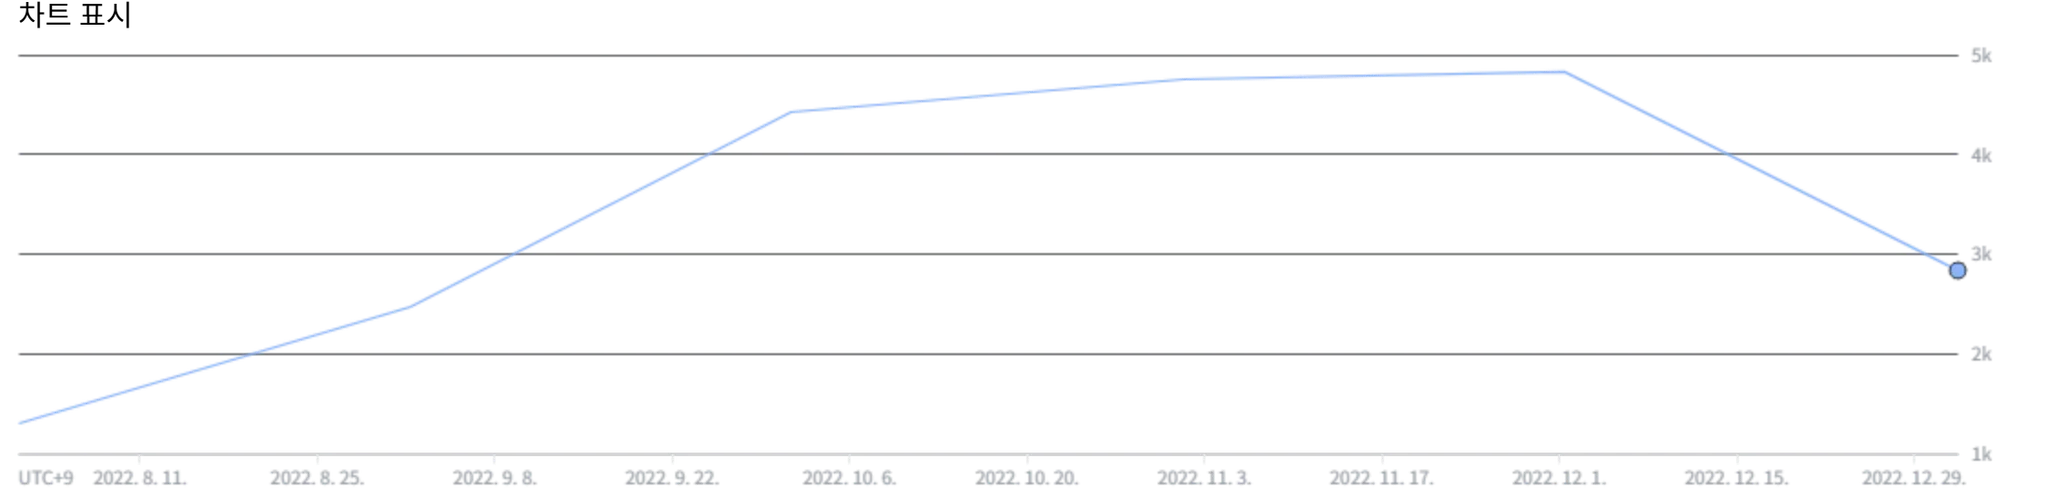

#### 활성 접속도 있고 비활성 접속도 있는 유저들은 어떤 접속이 먼저 발생했을까?
→ 활성 접속 이전 비활성 접속이 먼저 발생한 경우: 5,642건

→ 비활성 접속 이전 활성 접속이 먼저 발생한 경우: 8,983건

→ 활성 접속과 비활성 접속이 같은 날에 발생한 경우: 85건

→ 활성 접속이 일어나고 나서 비활성 접속이 이뤄진 경우가 가장 많은데 이들이 활성 접속으로 온다면 리텐션이 상승될 것으로 예상됨

``` sql
WITH not_activate_user_first_event AS (
  SELECT
    user_pseudo_id,
    MIN(event_date) OVER (PARTITION BY user_pseudo_id) AS not_act_first_event_date
  FROM foodie.not_activate_user_logs
), define_first_date AS (
  SELECT
    DISTINCT
      act.user_pseudo_id,
      MIN(event_date) OVER (PARTITION BY act.user_pseudo_id) AS act_first_event_date,
      not_act_first_event_date
  FROM foodie.activate_user_logs AS act
    INNER JOIN not_activate_user_first_event AS not_act ON act.user_pseudo_id = not_act.user_pseudo_id
)

SELECT
  check,
  COUNT(*) AS `cnt`
FROM (
  SELECT
    *,
    CASE
      # 활성 접속 이전 비활성 접속이 먼저 있었음
      WHEN act_first_event_date > not_act_first_event_date THEN 1
      # 비활성 접속 이전 활성 접속이 먼저 있었음
      WHEN act_first_event_date < not_act_first_event_date THEN 0
      # 활성 접속과 비활성 접속이 동일한 날짜에 발생
      ELSE 2
    END AS `check`
  FROM define_first_date)
GROUP BY check;
```

#### 비활성 접속 후 활성 접속한 사용자들은 어느 정도의 텀을 두고 접속했을까?
→ 비활성 접속 후 빠른 시일 내에 다시 접속해보는 경우가 가장 많음

``` sql
WITH not_activate_user_first_event AS (
  SELECT
    user_pseudo_id,
    MIN(event_date) OVER (PARTITION BY user_pseudo_id) AS not_act_first_event_date
  FROM foodie.not_activate_user_logs
), define_first_date AS (
  SELECT
    DISTINCT
      act.user_pseudo_id,
      MIN(event_date) OVER (PARTITION BY act.user_pseudo_id) AS act_first_event_date,
      not_act_first_event_date
  FROM foodie.activate_user_logs AS act
    INNER JOIN not_activate_user_first_event AS not_act ON act.user_pseudo_id = not_act.user_pseudo_id
)
SELECT
  diff_of_first_event_date,
  COUNT(*) AS `cnt`
FROM (
  SELECT
    *,
    DATE_DIFF(act_first_event_date, not_act_first_event_date, DAY) AS `diff_of_first_event_date`
  FROM define_first_date
  WHERE act_first_event_date > not_act_first_event_date
  )
GROUP BY diff_of_first_event_date
ORDER BY diff_of_first_event_date;
```

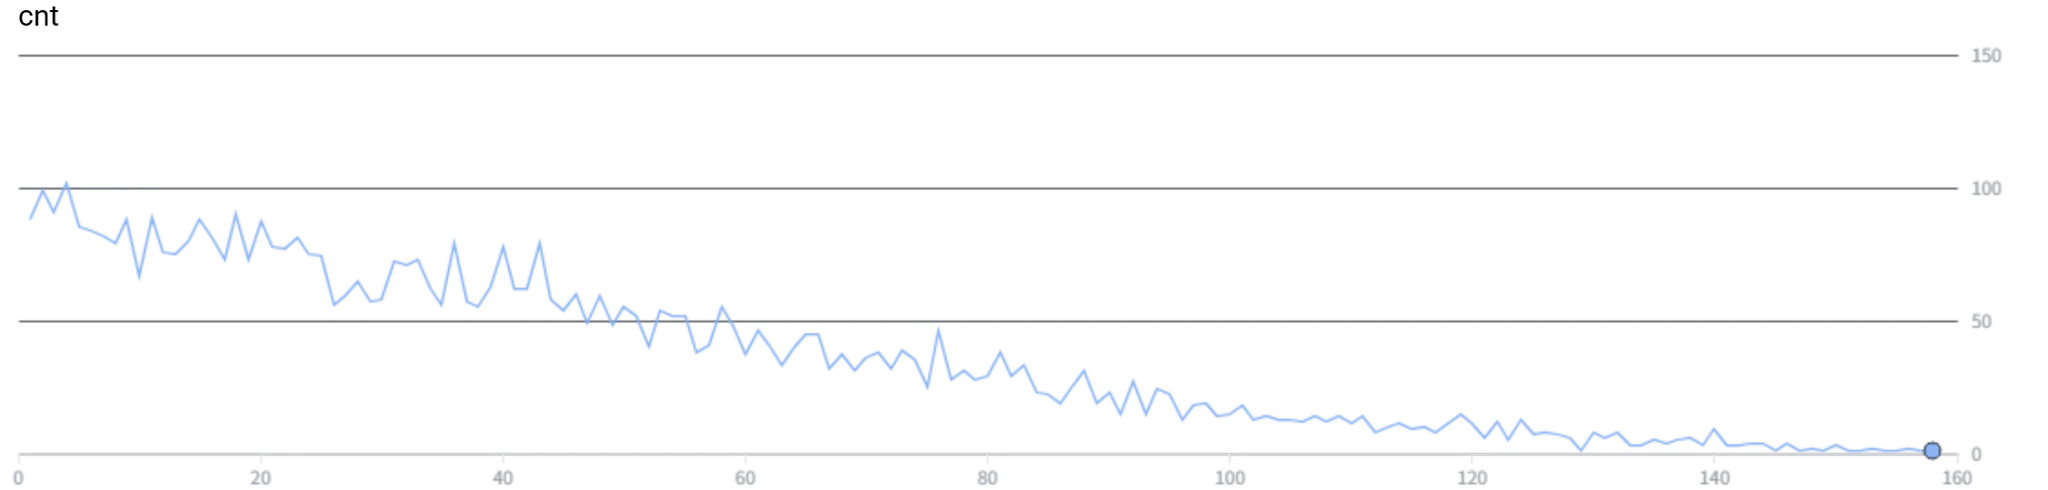

#### 활성 접속 후 비활성 접속한 사용자들은 어느 정도의 텀을 두고 접속했을까?

``` sql
WITH not_activate_user_first_event AS (
  SELECT
    user_pseudo_id,
    MIN(event_date) OVER (PARTITION BY user_pseudo_id) AS not_act_first_event_date
  FROM foodie.not_activate_user_logs
), define_first_date AS (
  SELECT
    DISTINCT
      act.user_pseudo_id,
      MIN(event_date) OVER (PARTITION BY act.user_pseudo_id) AS act_first_event_date,
      not_act_first_event_date
  FROM foodie.activate_user_logs AS act
    INNER JOIN not_activate_user_first_event AS not_act ON act.user_pseudo_id = not_act.user_pseudo_id
)
SELECT
  diff_of_first_event_date,
  COUNT(*) AS `cnt`
FROM (
  SELECT
    *,
    DATE_DIFF(not_act_first_event_date, act_first_event_date, DAY) AS `diff_of_first_event_date`
  FROM define_first_date
  WHERE act_first_event_date < not_act_first_event_date
  )
GROUP BY diff_of_first_event_date
ORDER BY diff_of_first_event_date;
```

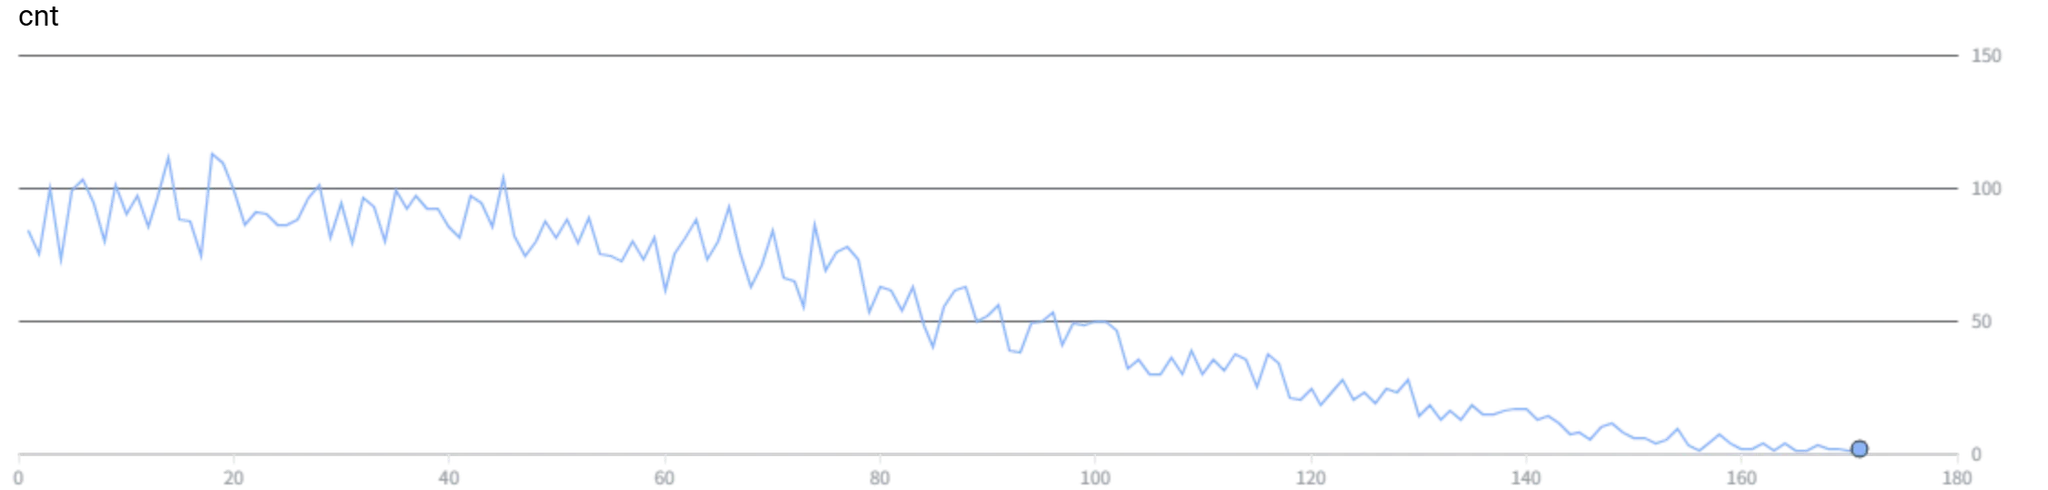

### 2-3. 활성 접속 탐색

#### 지표 집계

##### 일별 활성 접속 수
→ 10월까지 점차 증가하다가 10월 이후로는 어느 정도 변동이 있지만 유지 중

``` sql
SELECT
  event_date,
  COUNT(DISTINCT(user_pseudo_id)) `daily_activate_user_cnt`
FROM foodie.activate_user_logs
GROUP BY event_date
ORDER BY event_date;
```

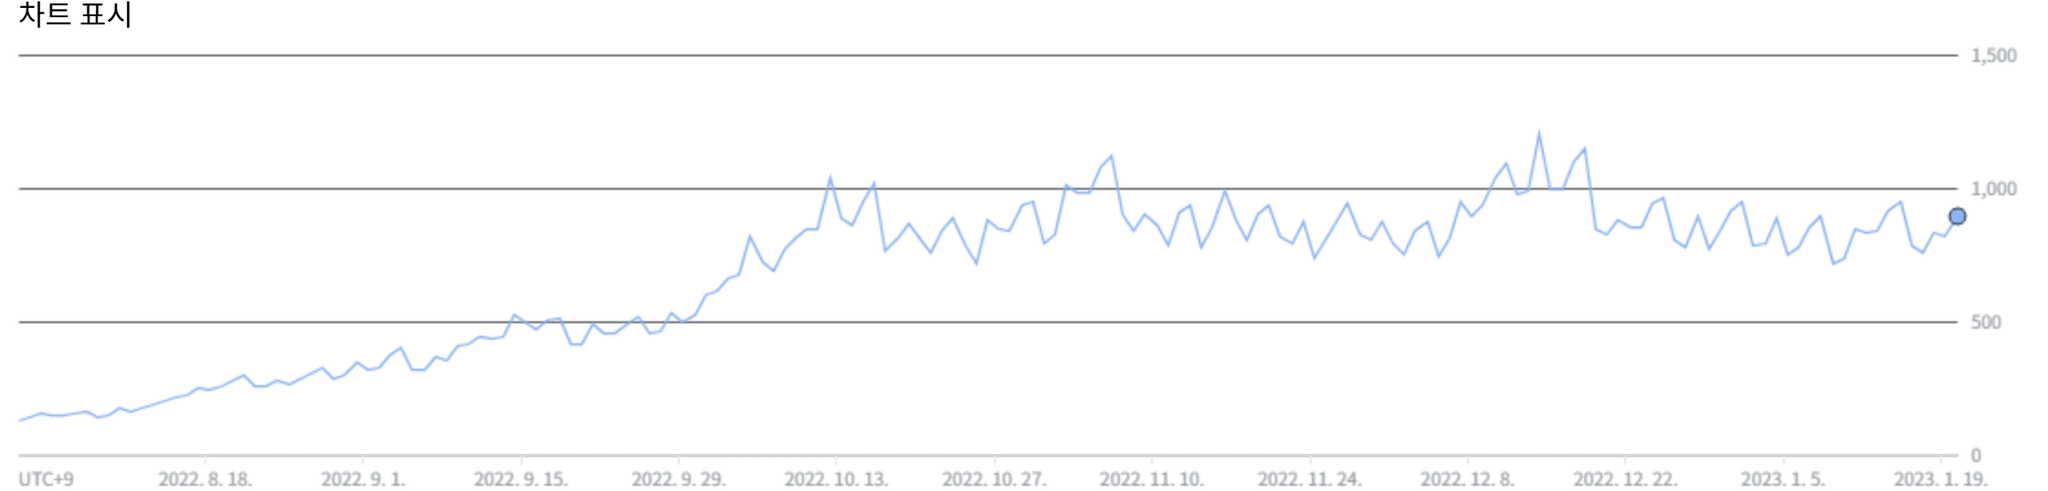

##### 주별 활성 접속 수
→ 10월까지 점차 증가하다가 10월 이후로는 어느 정도 변동이 있지만 유지 중이다가 1월에 조금 감소하는 추세

``` sql
SELECT
  event_week,
  COUNT(DISTINCT(user_pseudo_id)) AS `weekly_not_activate_user_cnt`
FROM (
  SELECT
    user_pseudo_id,
    DATE_TRUNC(event_date, WEEK(MONDAY)) AS `event_week`
  FROM foodie.activate_user_logs
  )
GROUP BY event_week
ORDER BY event_week;
```

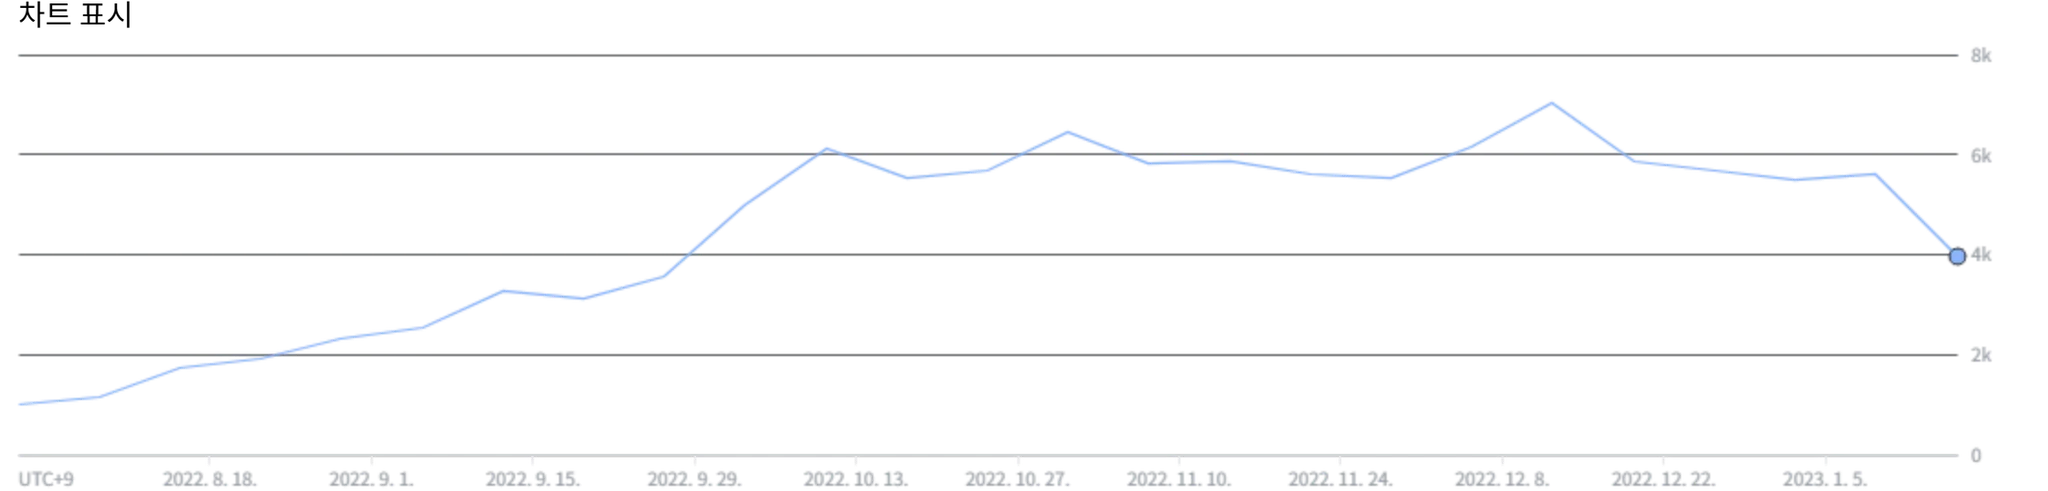

##### 월별 활성 접속 수
→ 12월까지 점차 증가하다가 1월에 조금 감소하는 추세

``` sql
SELECT
  event_month,
  COUNT(DISTINCT(user_pseudo_id)) AS `monthly_not_activate_user_cnt`
FROM (
  SELECT
    user_pseudo_id,
    DATE_TRUNC(event_date, MONTH) AS `event_month`
  FROM foodie.activate_user_logs
  )
GROUP BY event_month
ORDER BY event_month;
```

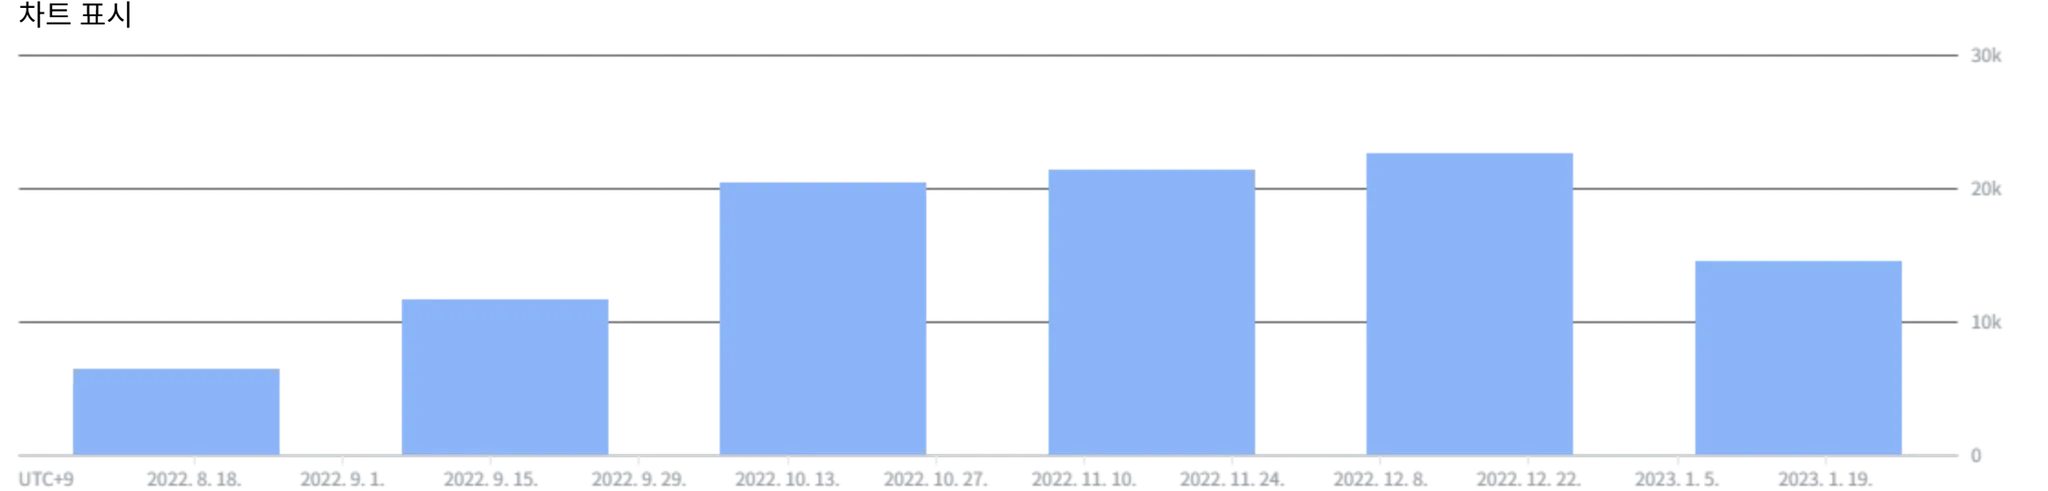

##### 일별 전환 수
→ 중간 중간 가파르게 전환이 많이 되는 구간 존재 (공휴일)

→ 가파르게 증가한 후에는 바로 다시 평균치로 떨어짐

→ 프로모션을 진행해서 공휴일에 전환 수가 급격히 상승했을 수도 있는데 이런 상승 이후로 추가적인 증가가 이뤄지지 않으므로 제품 성장이 정체

    → 광복절 (22년 8월 15일)

    → 추석 연휴 (22년 9월 9일 ~ 22년 9월 12일)

    → 개천절 (22년 10월 3일)

    → 한글날 연휴 (22년 10월 9일 ~ 22년 10월 10일)

    → 크리스마스 (22년 12월 25일)

    → 신정 ( 23년 1월 1일)

``` sql
SELECT
  event_date,
  COUNT(*)
FROM foodie.activate_user_logs
WHERE event_name = 'click_payment'
GROUP BY event_date
ORDER BY event_date;
```

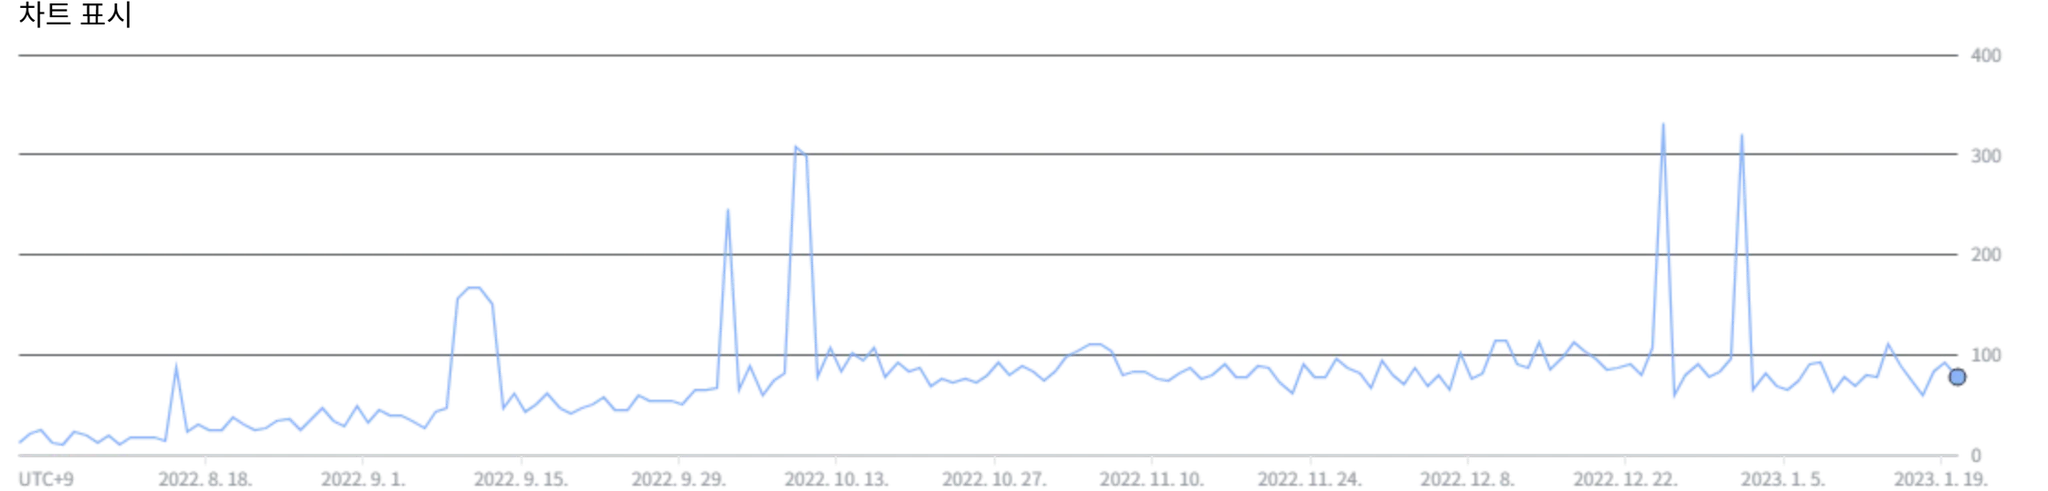

#### 퍼널
→ screen_view-welcome에서 screen_view-home으로 가는 수는 모든 퍼널 동일

→ 결제하는데 어떤 기능을 가장 많이 사용하는지, 이탈률이 낮은지 등을 파악

##### 퍼널 도식화

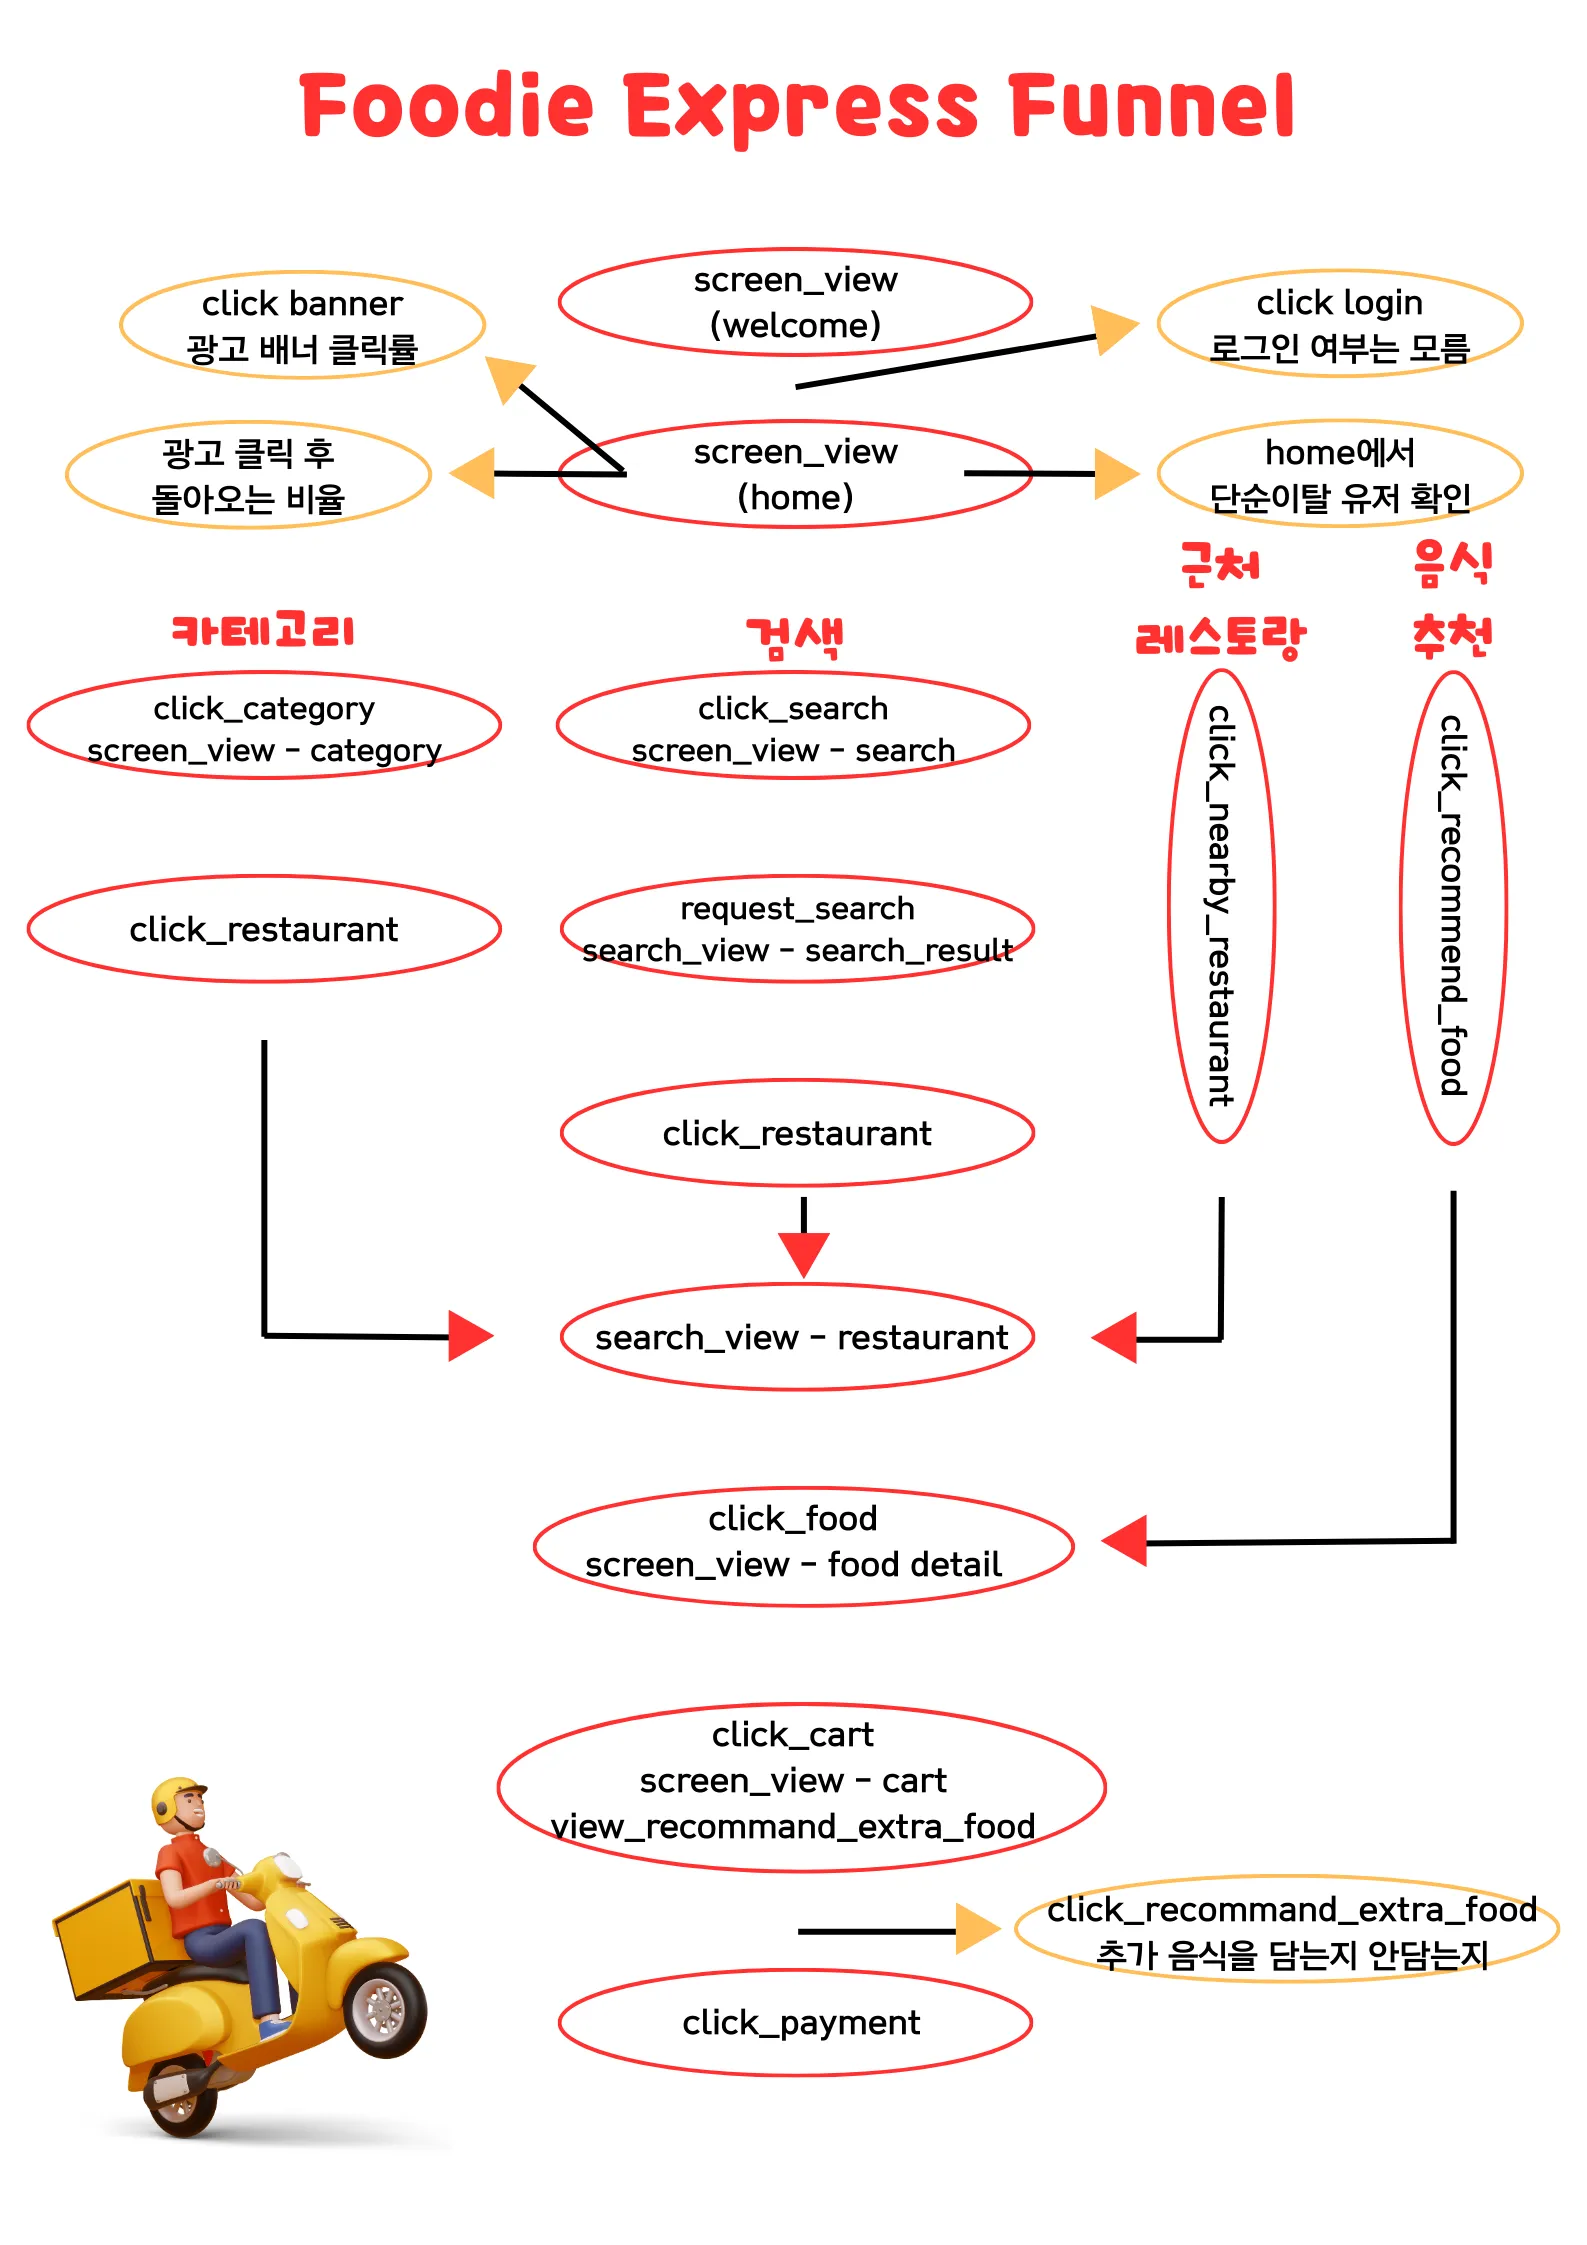

##### 카테고리를 통한 결제 퍼널
→ screen_view-food_category를 포함한 세션만 뽑아내서 퍼널 구하기

``` sql
WITH base AS (
  SELECT
    event_date,
    event_datetime,
    event_name,
    user_pseudo_id,
    session_id,
    platform,
    MAX(IF(event_param.key = "firebase_screen", event_param.value.string_value, NULL)) AS firebase_screen,
  FROM foodie.activate_user_logs, UNNEST(event_params) AS event_param
  GROUP BY ALL
), set_event_name_with_screen AS (
  SELECT
    user_pseudo_id,
    session_id,
    event_datetime,
    event_name,
    firebase_screen,
    platform,
    CONCAT(event_name, '-', firebase_screen)AS event_name_with_screen,
  FROM base
), select_food_category_funnel AS (
  SELECT
    user_pseudo_id,
    session_id,
    event_datetime,
    event_name_with_screen,
    platform,
    MAX(check_num) OVER (PARTITION BY user_pseudo_id, session_id) AS `check_category_funnel`
  FROM (SELECT
      *,
      IF(event_name_with_screen = 'screen_view-food_category', 1, null) AS `check_num`
    FROM set_event_name_with_screen)
  QUALIFY check_category_funnel IS NOT NULL
), set_funnel_step AS (
  SELECT
    * EXCEPT(check_category_funnel, platform),
    CASE
      WHEN event_name_with_screen = 'screen_view-food_category' THEN 3
      WHEN event_name_with_screen = 'screen_view-restaurant' THEN 4
      WHEN event_name_with_screen = 'screen_view-food_detail' THEN 5
      WHEN event_name_with_screen = 'screen_view-cart' THEN 6
      WHEN event_name_with_screen = 'click_payment-cart' THEN 7
      ELSE NULL
    END AS step
  FROM select_food_category_funnel
), set_category_funnel AS (
  SELECT
    event_name_with_screen,
    CASE 
      WHEN event_name_with_screen = 'screen_view-welcome' THEN 1
      WHEN event_name_with_screen = 'screen_view-home' THEN 2
    END AS step,
    COUNT(*) AS funnel_cnt
  FROM (
    SELECT
      # 다른 화면을 보다가 screen_view-home으로 돌아가는 경우 존재
      DISTINCT
        user_pseudo_id,
        session_id,
        event_name_with_screen
    FROM set_event_name_with_screen
    WHERE event_name_with_screen IN ('screen_view-welcome', 'screen_view-home')
  )
  GROUP BY event_name_with_screen
  UNION ALL
  SELECT
    event_name_with_screen,
    step,
    COUNT(*) AS `funnel_cnt`
  FROM set_funnel_step
  WHERE step IS NOT NULL
  GROUP BY event_name_with_screen, step
)

SELECT *
FROM set_category_funnel
ORDER BY step;
```

| event\_name\_with\_screen   | step | funnel\_cnt |
| --------------------------- | ---: | ----------: |
| screen\_view-welcome        |    1 |      105080 |
| screen\_view-home           |    2 |      105079 |
| screen\_view-food\_category |    3 |       46897 |
| screen\_view-restaurant     |    4 |       30437 |
| screen\_view-food\_detail   |    5 |       16165 |
| screen\_view-cart           |    6 |       13129 |
| click\_payment-cart         |    7 |        8519 |

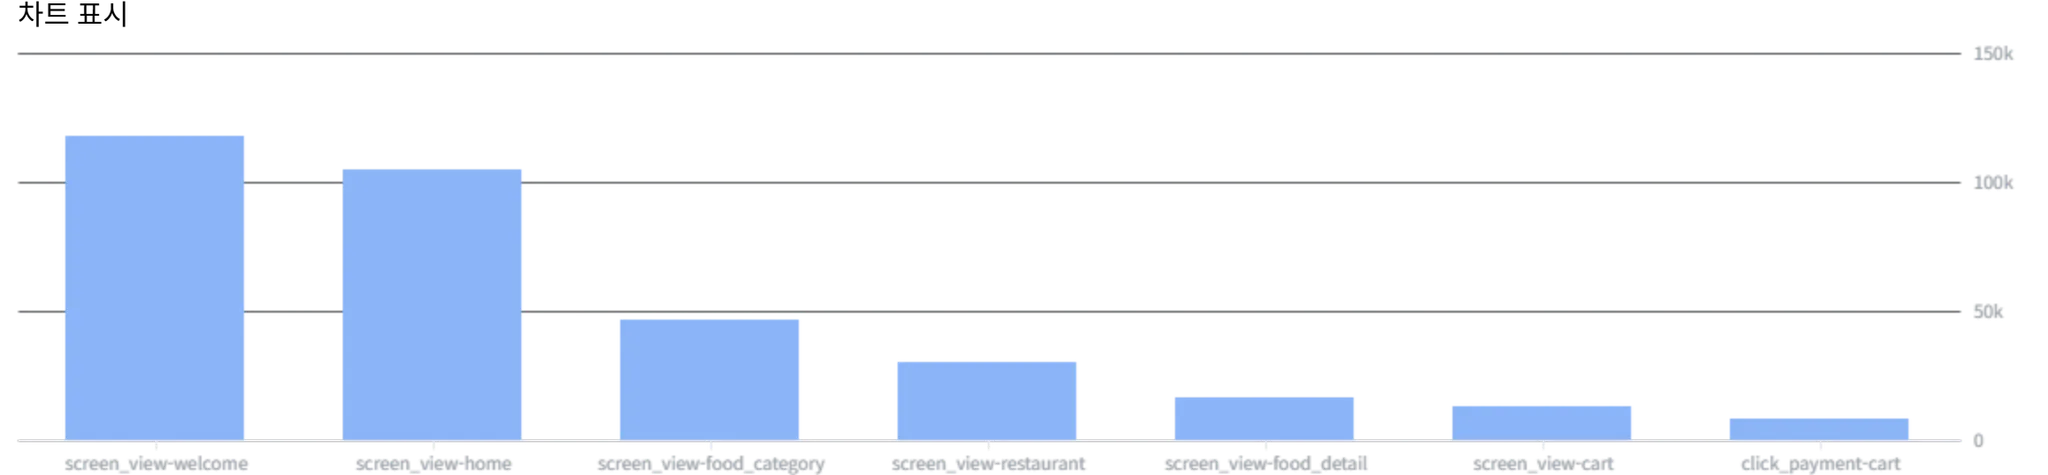

##### 검색을 통한 결제 퍼널
→ screen_view-search를 포함한 세션만 뽑아내서 퍼널 구하기

``` sql
WITH base AS (
  SELECT
    event_date,
    event_datetime,
    event_name,
    user_pseudo_id,
    session_id,
    platform,
    MAX(IF(event_param.key = "firebase_screen", event_param.value.string_value, NULL)) AS firebase_screen,
  FROM foodie.activate_user_logs, UNNEST(event_params) AS event_param
  GROUP BY ALL
), set_event_name_with_screen AS (
  SELECT
    user_pseudo_id,
    session_id,
    event_datetime,
    event_name,
    firebase_screen,
    platform,
    CONCAT(event_name, '-', firebase_screen)AS event_name_with_screen,
  FROM base
), select_food_search_funnel AS (
  SELECT
    user_pseudo_id,
    session_id,
    event_datetime,
    event_name_with_screen,
    platform,
    MAX(check_num) OVER (PARTITION BY user_pseudo_id, session_id) AS `check_search_funnel`
  FROM (SELECT
      *,
      IF(event_name_with_screen = 'screen_view-search', 1, null) AS `check_num`
    FROM set_event_name_with_screen)
  QUALIFY check_search_funnel IS NOT NULL
), set_funnel_step AS (
  SELECT
    * EXCEPT(check_search_funnel, platform),
    CASE
      WHEN event_name_with_screen = 'screen_view-search' THEN 3
      WHEN event_name_with_screen = 'screen_view-search_result' THEN 4
      WHEN event_name_with_screen = 'screen_view-restaurant' THEN 5
      WHEN event_name_with_screen = 'screen_view-food_detail' THEN 6
      WHEN event_name_with_screen = 'screen_view-cart' THEN 7
      WHEN event_name_with_screen = 'click_payment-cart' THEN 8
      ELSE NULL
    END AS step
  FROM select_food_search_funnel
), set_search_funnel AS (
  SELECT
    event_name_with_screen,
    CASE 
      WHEN event_name_with_screen = 'screen_view-welcome' THEN 1
      WHEN event_name_with_screen = 'screen_view-home' THEN 2
    END AS step,
    COUNT(*) AS funnel_cnt
  FROM (
    SELECT
      # 다른 화면을 보다가 screen_view-home으로 돌아가는 경우 존재
      DISTINCT
        user_pseudo_id,
        session_id,
        event_name_with_screen
    FROM set_event_name_with_screen
    WHERE event_name_with_screen IN ('screen_view-welcome', 'screen_view-home')
  )
  GROUP BY event_name_with_screen
  UNION ALL
  SELECT
    event_name_with_screen,
    step,
    COUNT(*) AS `funnel_cnt`
  FROM set_funnel_step
  WHERE step IS NOT NULL
  GROUP BY event_name_with_screen, step
)

SELECT *
FROM set_search_funnel
ORDER BY step;
```

| event\_name\_with\_screen   | step | funnel\_cnt |
| --------------------------- | ---: | ----------: |
| screen\_view-welcome        |    1 |      105080 |
| screen\_view-home           |    2 |      105079 |
| screen\_view-search         |    3 |       16693 |
| screen\_view-search\_result |    4 |       16693 |
| screen\_view-restaurant     |    5 |        6776 |
| screen\_view-food\_detail   |    6 |        2754 |
| screen\_view-cart           |    7 |        2263 |
| click\_payment-cart         |    8 |        1260 |

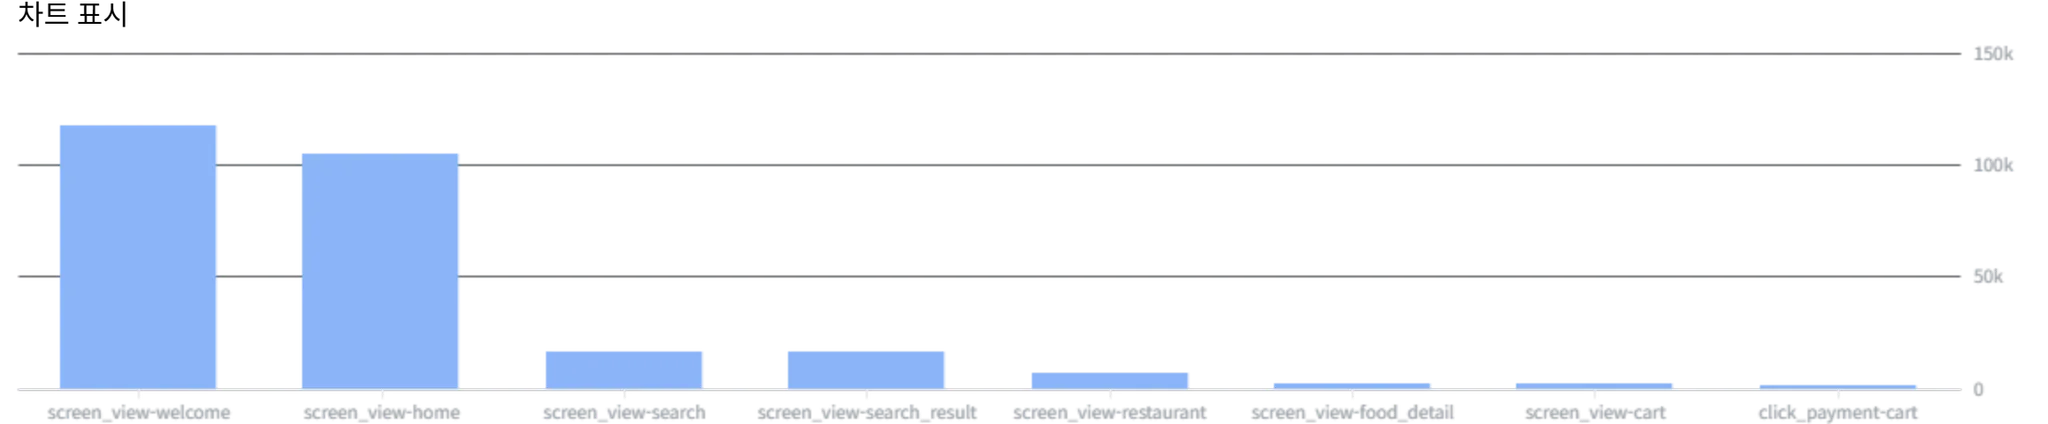

##### 근처 레스토랑 클릭을 통한 결제 퍼널
→ click_restaurant_nearby-home를 포함한 세션만 뽑아내서 퍼널 구하기

``` sql
WITH base AS (
  SELECT
    event_date,
    event_datetime,
    event_name,
    user_pseudo_id,
    session_id,
    platform,
    MAX(IF(event_param.key = "firebase_screen", event_param.value.string_value, NULL)) AS firebase_screen,
  FROM foodie.activate_user_logs, UNNEST(event_params) AS event_param
  GROUP BY ALL
), set_event_name_with_screen AS (
  SELECT
    user_pseudo_id,
    session_id,
    event_datetime,
    event_name,
    firebase_screen,
    platform,
    CONCAT(event_name, '-', firebase_screen)AS event_name_with_screen,
  FROM base
), select_nearby_restaurant_funnel AS (
  SELECT
    user_pseudo_id,
    session_id,
    event_datetime,
    event_name_with_screen,
    platform,
    MAX(check_num) OVER (PARTITION BY user_pseudo_id, session_id) AS `check_nearby_restaurant_funnel`
  FROM (SELECT
      *,
      IF(event_name_with_screen = 'click_restaurant_nearby-home', 1, null) AS `check_num`
    FROM set_event_name_with_screen)
  QUALIFY check_nearby_restaurant_funnel IS NOT NULL
), set_funnel_step AS (
  SELECT
    * EXCEPT(check_nearby_restaurant_funnel, platform),
    CASE
      WHEN event_name_with_screen = 'click_restaurant_nearby-home' THEN 3
      WHEN event_name_with_screen = 'screen_view-food_detail' THEN 4
      WHEN event_name_with_screen = 'screen_view-cart' THEN 5
      WHEN event_name_with_screen = 'click_payment-cart' THEN 6
      ELSE NULL
    END AS step
  FROM select_nearby_restaurant_funnel
), set_nearby_restaurant_funnel AS (
  SELECT
    event_name_with_screen,
    CASE 
      WHEN event_name_with_screen = 'screen_view-welcome' THEN 1
      WHEN event_name_with_screen = 'screen_view-home' THEN 2
    END AS step,
    COUNT(*) AS funnel_cnt
  FROM (
    SELECT
      # 다른 화면을 보다가 screen_view-home으로 돌아가는 경우 존재
      DISTINCT
        user_pseudo_id,
        session_id,
        event_name_with_screen
    FROM set_event_name_with_screen
    WHERE event_name_with_screen IN ('screen_view-welcome', 'screen_view-home')
  )
  GROUP BY event_name_with_screen
  UNION ALL
  SELECT
    event_name_with_screen,
    step,
    COUNT(*) AS `funnel_cnt`
  FROM set_funnel_step
  WHERE step IS NOT NULL
  GROUP BY event_name_with_screen, step
)

SELECT *
FROM set_nearby_restaurant_funnel
ORDER BY step;
```

| event\_name\_with\_screen      | step | funnel\_cnt |
| ------------------------------ | ---: | ----------: |
| screen\_view-welcome           |    1 |      105080 |
| screen\_view-home              |    2 |      105079 |
| click\_restaurant\_nearby-home |    3 |        4013 |
| screen\_view-food\_detail      |    4 |        1854 |
| screen\_view-cart              |    5 |        1572 |
| click\_payment-cart            |    6 |        1190 |

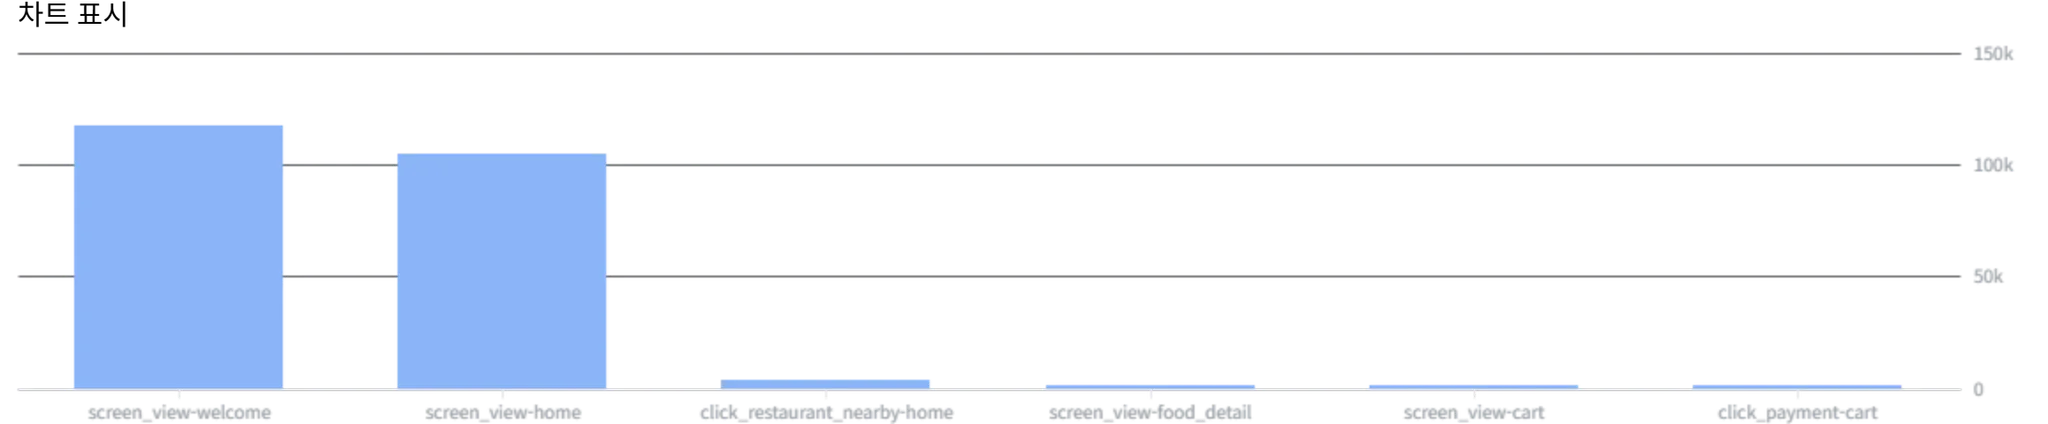

##### 음식 추천 클릭을 통한 결제 퍼널
→ click_recommend_food-home를 포함한 세션만 뽑아내서 퍼널 구하기

``` sql
WITH base AS (
  SELECT
    event_date,
    event_datetime,
    event_name,
    user_pseudo_id,
    session_id,
    platform,
    MAX(IF(event_param.key = "firebase_screen", event_param.value.string_value, NULL)) AS firebase_screen,
  FROM foodie.activate_user_logs, UNNEST(event_params) AS event_param
  GROUP BY ALL
), set_event_name_with_screen AS (
  SELECT
    user_pseudo_id,
    session_id,
    event_datetime,
    event_name,
    firebase_screen,
    platform,
    CONCAT(event_name, '-', firebase_screen)AS event_name_with_screen,
  FROM base
), select_recommend_food_funnel AS (
  SELECT
    user_pseudo_id,
    session_id,
    event_datetime,
    event_name_with_screen,
    platform,
    MAX(check_num) OVER (PARTITION BY user_pseudo_id, session_id) AS `check_recommend_food_funnel`
  FROM (SELECT
      *,
      IF(event_name_with_screen = 'click_recommend_food-home', 1, null) AS `check_num`
    FROM set_event_name_with_screen)
  QUALIFY check_recommend_food_funnel IS NOT NULL
), set_funnel_step AS (
  SELECT
    * EXCEPT(check_recommend_food_funnel, platform),
    CASE
      WHEN event_name_with_screen = 'click_recommend_food-home' THEN 3
      WHEN event_name_with_screen = 'screen_view-cart' THEN 4
      WHEN event_name_with_screen = 'click_payment-cart' THEN 5
      ELSE NULL
    END AS step
  FROM select_recommend_food_funnel
), set_recommend_food_funnel AS (
  SELECT
    event_name_with_screen,
    CASE 
      WHEN event_name_with_screen = 'screen_view-welcome' THEN 1
      WHEN event_name_with_screen = 'screen_view-home' THEN 2
    END AS step,
    COUNT(*) AS funnel_cnt
  FROM (
    SELECT
      # 다른 화면을 보다가 screen_view-home으로 돌아가는 경우 존재
      DISTINCT
        user_pseudo_id,
        session_id,
        event_name_with_screen
    FROM set_event_name_with_screen
    WHERE event_name_with_screen IN ('screen_view-welcome', 'screen_view-home')
  )
  GROUP BY event_name_with_screen
  UNION ALL
  SELECT
    event_name_with_screen,
    step,
    COUNT(*) AS `funnel_cnt`
  FROM set_funnel_step
  WHERE step IS NOT NULL
  GROUP BY event_name_with_screen, step
)

SELECT *
FROM set_recommend_food_funnel
ORDER BY step;
```

| event\_name\_with\_screen   | step | funnel\_cnt |
| --------------------------- | ---: | ----------: |
| screen\_view-welcome        |    1 |      105080 |
| screen\_view-home           |    2 |      105079 |
| click\_recommend\_food-home |    3 |        4399 |
| screen\_view-cart           |    4 |        3605 |
| click\_payment-cart         |    5 |        2191 |

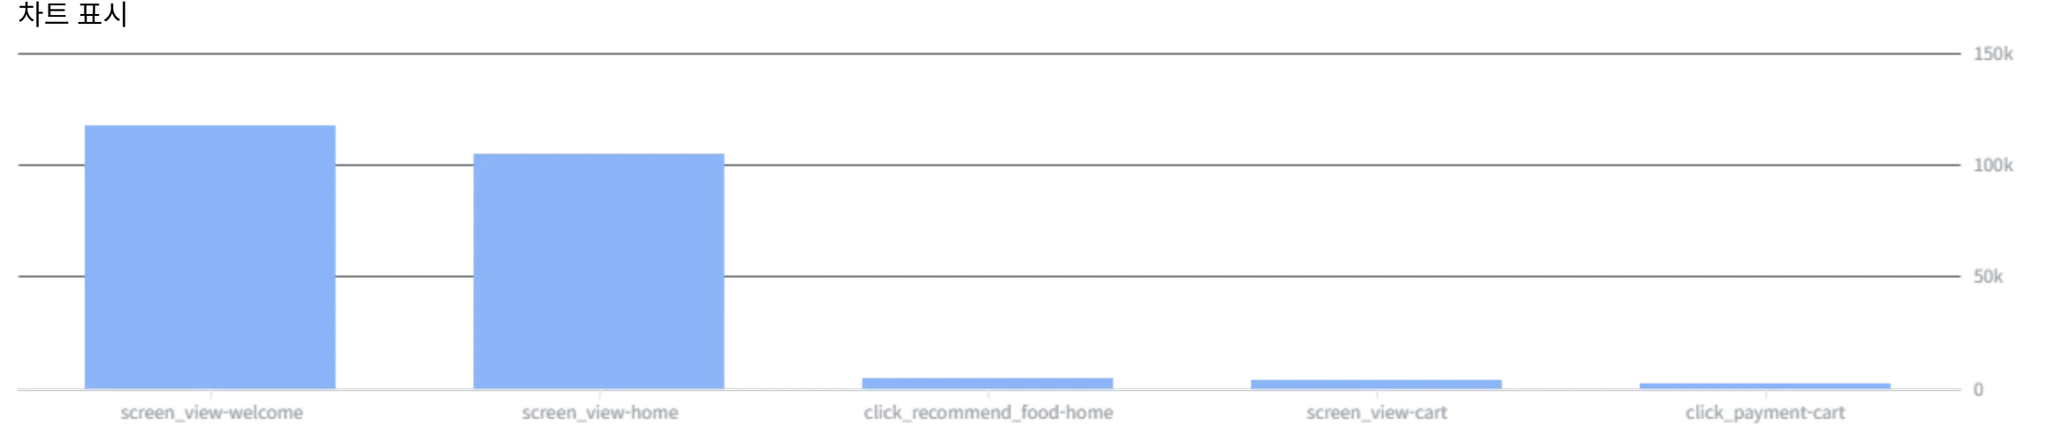

#### 단계별 이탈률

##### 카테고리

``` sql
SELECT
  *,
  CONCAT(ROUND((1 - SAFE_DIVIDE(funnel_cnt, pre_funnel_cnt)), 2) * 100, '%') AS `funnel_step_bounce_rate`
FROM (
  SELECT
  *,
  LAG(funnel_cnt) OVER (ORDER BY step) AS `pre_funnel_cnt`
FROM set_category_funnel)
ORDER BY step;
```

screen_view-welcome

—— 0% → screen_view-home

—— 55% → screen_view-food_category

—— 35% → screen_view-restaurant

—— 47% → screen_view-food_detail

—— 19% → screen_view-cart

—— 35% → click_payment-cart

##### 검색

``` sql
SELECT
  *,
  CONCAT(ROUND((1 - SAFE_DIVIDE(funnel_cnt, pre_funnel_cnt)), 2) * 100, '%') AS `funnel_step_bounce_rate`
FROM (
  SELECT
  *,
  LAG(funnel_cnt) OVER (ORDER BY step) AS `pre_funnel_cnt`
FROM set_search_funnel)
ORDER BY step;
```

screen_view-welcome

—— 0% → screen_view-home

—— 84% → screen_view-search

—— 0% → screen_view-search_result

—— 59% → screen_view-restaurant

—— 59% → screen_view-food_detail

—— 18% → screen_view-cart

—— 44% → click_payment-cart

##### 근처 음식점

``` sql
SELECT
  *,
  CONCAT(ROUND((1 - SAFE_DIVIDE(funnel_cnt, pre_funnel_cnt)), 2) * 100, '%') AS `funnel_step_bounce_rate`
FROM (
  SELECT
  *,
  LAG(funnel_cnt) OVER (ORDER BY step) AS `pre_funnel_cnt`
FROM set_nearby_restaurant_funnel)
ORDER BY step;
```

screen_view-welcome

—— 0% → screen_view-home

—— 96% → click_restaurant_nearby-home

—— 54% → screen_view-food_detail

—— 15% → screen_view-cart

—— 24% → click_payment-cart

##### 음식 추천

``` sql
SELECT
  *,
  CONCAT(ROUND((1 - SAFE_DIVIDE(funnel_cnt, pre_funnel_cnt)), 2) * 100, '%') AS `funnel_step_bounce_rate`
FROM (
  SELECT
  *,
  LAG(funnel_cnt) OVER (ORDER BY step) AS `pre_funnel_cnt`
FROM set_recommend_food_funnel)
ORDER BY step;
```

screen_view-welcome

—— 0% → screen_view-home

—— 96% → click_recommend_food-home

—— 18% → screen_view-cart

—— 39% → click_payment-cart

#### 누적 전환율

##### 카테고리

``` sql
SELECT
  *,
  CONCAT(ROUND(SAFE_DIVIDE(funnel_cnt, pre_funnel_cnt), 2) * 100, '%') AS `funnel_root_bounce_rate`
FROM (
  SELECT
  *,
  MAX(funnel_cnt) OVER (ORDER BY step) AS `pre_funnel_cnt`
FROM set_category_funnel)
ORDER BY step;
```

screen_view-welcome

—— 100% → screen_view-home

—— 45% → screen_view-food_category

—— 29% → screen_view-restaurant

—— 15% → screen_view-food_detail

—— 12% → screen_view-cart

—— 8% → click_payment-cart

##### 검색

``` sql
SELECT
  *,
  CONCAT(ROUND(SAFE_DIVIDE(funnel_cnt, pre_funnel_cnt), 2) * 100, '%') AS `funnel_root_bounce_rate`
FROM (
  SELECT
  *,
  MAX(funnel_cnt) OVER (ORDER BY step) AS `pre_funnel_cnt`
FROM set_search_funnel)
ORDER BY step;
```

screen_view-welcome

—— 100% → screen_view-home

—— 16% → screen_view-search

—— 16% → screen_view-search_result

—— 6% → screen_view-restaurant

—— 3% → screen_view-food_detail

—— 2% → screen_view-cart

—— 1% → click_payment-cart

##### 근처 음식점

``` sql
SELECT
  *,
  CONCAT(ROUND(SAFE_DIVIDE(funnel_cnt, pre_funnel_cnt), 2) * 100, '%') AS `funnel_root_bounce_rate`
FROM (
  SELECT
  *,
  MAX(funnel_cnt) OVER (ORDER BY step) AS `pre_funnel_cnt`
FROM set_nearby_restaurant_funnel)
ORDER BY step;
```

screen_view-welcome

—— 100% → screen_view-home

—— 4%   → click_restaurant_nearby-home

—— 2%   → screen_view-food_detail

—— 1%   → screen_view-cart

—— 1%   → click_payment-cart

##### 음식 추천

``` sql
SELECT
  *,
  CONCAT(ROUND(SAFE_DIVIDE(funnel_cnt, pre_funnel_cnt), 2) * 100, '%') AS `funnel_root_bounce_rate`
FROM (
  SELECT
  *,
  MAX(funnel_cnt) OVER (ORDER BY step) AS `pre_funnel_cnt`
FROM set_recommend_food_funnel)
ORDER BY step;
```

screen_view-welcome

—— 100% → screen_view-home

—— 4% → click_recommend_food-home

—— 3% → screen_view-cart

—— 2% → click_payment-cart

#### 리텐션

##### 방문 리텐션 (N-Day)

``` sql
WITH base AS (
  SELECT
    DISTINCT
      user_pseudo_id,
      event_date
  FROM foodie.activate_user_logs
), cal_diff_of_event_date AS (
  SELECT
    user_pseudo_id,
    event_date,
    DATE_DIFF(event_date ,first_event_date, DAY) AS `diff_of_event_date`
  FROM (
    SELECT
      *,
      MIN(event_date) OVER (PARTITION BY user_pseudo_id) AS `first_event_date`
    FROM base
  )
), retention_day_cnt AS (
  SELECT
    diff_of_event_date,
    COUNT(diff_of_event_date) AS `retention_cnt`,
    FIRST_VALUE(COUNT(diff_of_event_date)) OVER (ORDER BY diff_of_event_date) AS `first_retentio_cnt`
  FROM cal_diff_of_event_date
  GROUP BY diff_of_event_date
)

SELECT
  *,
  ROUND(SAFE_DIVIDE(retention_cnt, first_retentio_cnt), 3) AS `retention_ratio`
FROM retention_day_cnt
ORDER BY diff_of_event_date;
```

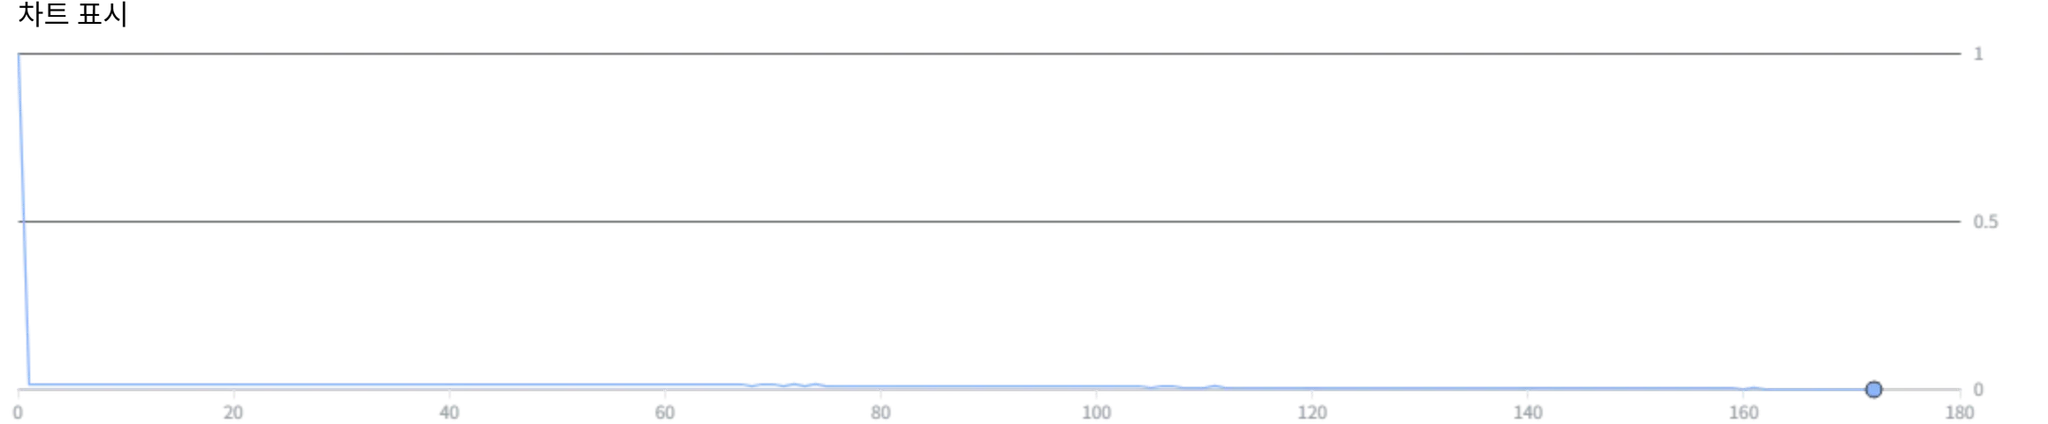

##### 방문 리텐션 (Weekly)

``` sql
WITH base AS (
  SELECT
    DISTINCT
      user_pseudo_id,
      DATE_TRUNC(event_date, WEEK(MONDAY)) AS `event_week`
  FROM foodie.activate_user_logs
), cal_diff_of_event_week AS (
  SELECT
    user_pseudo_id,
    event_week,
    DATE_DIFF(event_week ,first_event_week, WEEK) AS `diff_of_event_week`
  FROM (
    SELECT
      *,
      MIN(event_week) OVER (PARTITION BY user_pseudo_id) AS `first_event_week`
    FROM base
  )
), retention_week_cnt AS (
  SELECT
    diff_of_event_week,
    COUNT(diff_of_event_week) AS `retention_cnt`,
    FIRST_VALUE(COUNT(diff_of_event_week)) OVER (ORDER BY diff_of_event_week) AS `first_retentio_cnt`
  FROM cal_diff_of_event_week
  GROUP BY diff_of_event_week
)

SELECT
  *,
  ROUND(SAFE_DIVIDE(retention_cnt, first_retentio_cnt), 3) AS `retention_ratio`
FROM retention_week_cnt
ORDER BY diff_of_event_week;
```

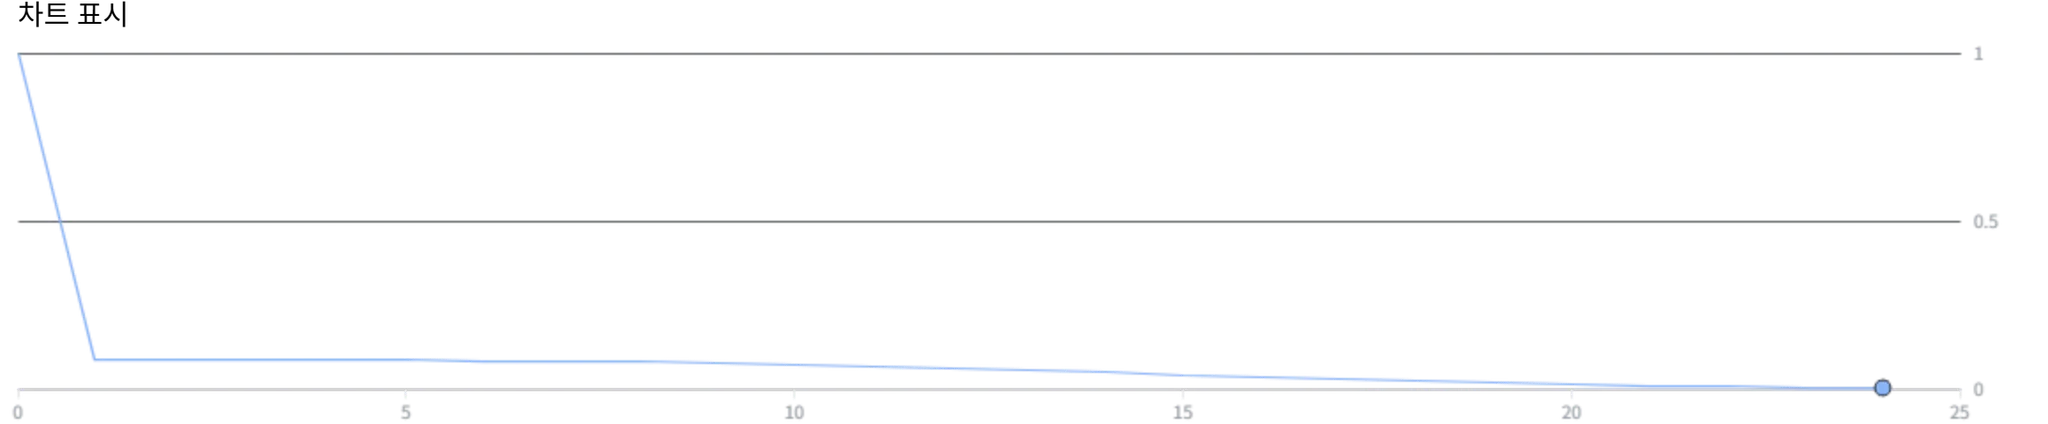

##### 전환 리텐션 (N-Day)

``` sql
WITH base AS (
  SELECT
    DISTINCT
      user_pseudo_id,
      event_date
  FROM (
    SELECT
      user_pseudo_id,
      session_id,
      DATE(event_datetime) AS `event_date`,
      platform,
      MAX(check_num) OVER (PARTITION BY user_pseudo_id, session_id) AS `check_payment_logs`
    FROM (
	    SELECT
	      *,
	      IF(event_name = 'click_payment', 1, null) AS `check_num`
	    FROM foodie.activate_user_logs
	    )
		 QUALIFY check_payment_logs IS NOT NULL
	 )
), cal_diff_of_event_date AS (
  SELECT
    user_pseudo_id,
    event_date,
    DATE_DIFF(event_date ,first_event_date, DAY) AS `diff_of_event_date`
  FROM (
    SELECT
      *,
      MIN(event_date) OVER (PARTITION BY user_pseudo_id) AS `first_event_date`
    FROM base
  )
), retention_week_cnt AS (
  SELECT
    diff_of_event_date,
    COUNT(diff_of_event_date) AS `retention_cnt`,
    FIRST_VALUE(COUNT(diff_of_event_date)) OVER (ORDER BY diff_of_event_date) AS `first_retentio_cnt`
  FROM cal_diff_of_event_date
  GROUP BY diff_of_event_date
)

SELECT
  *,
  ROUND(SAFE_DIVIDE(retention_cnt, first_retentio_cnt), 3) AS `retention_ratio`
FROM retention_week_cnt
ORDER BY diff_of_event_date;
```

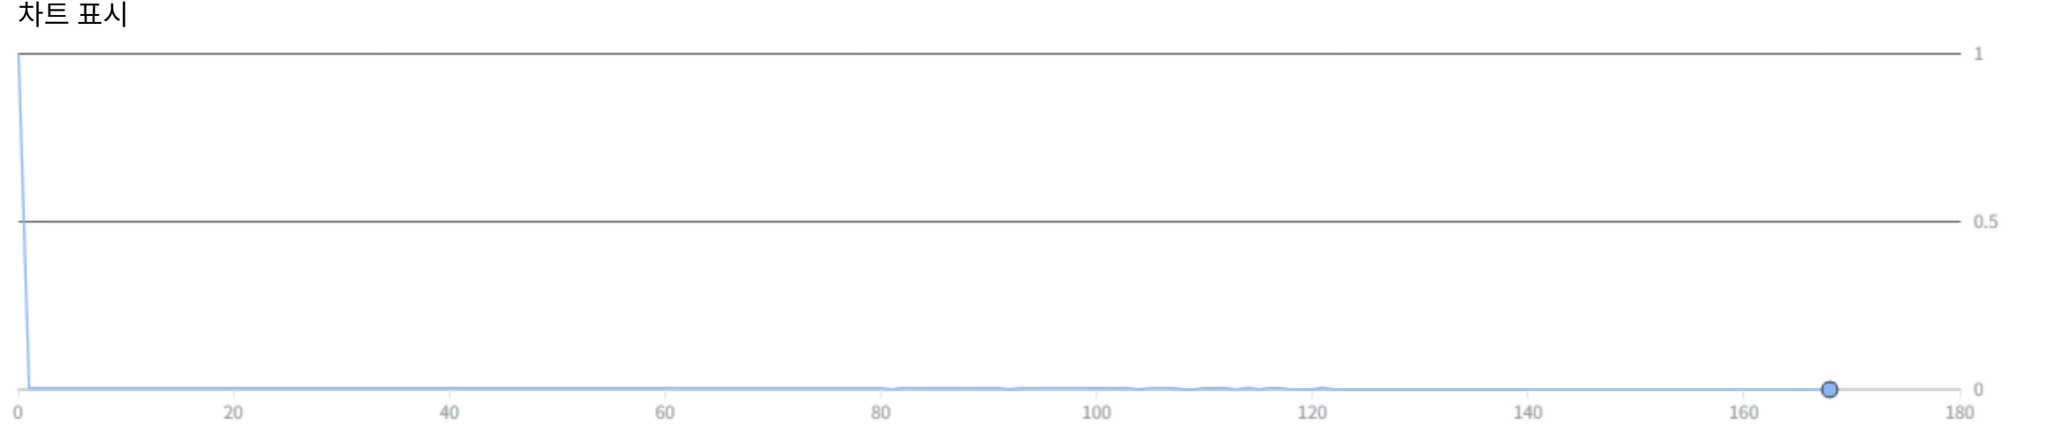

##### 전환 리텐션 (Weekly)

``` sql
WITH base AS (
  SELECT
    DISTINCT
      user_pseudo_id,
      DATE_TRUNC(event_date, WEEK(MONDAY)) AS `event_week`
  FROM (
    SELECT
      user_pseudo_id,
      session_id,
      DATE(event_datetime) AS `event_date`,
      platform,
      MAX(check_num) OVER (PARTITION BY user_pseudo_id, session_id) AS `check_payment_logs`
    FROM (SELECT
      *,
      IF(event_name = 'click_payment', 1, null) AS `check_num`
    FROM foodie.activate_user_logs)
  QUALIFY check_payment_logs IS NOT NULL
  )
), cal_diff_of_event_week AS (
  SELECT
    user_pseudo_id,
    event_week,
    DATE_DIFF(event_week ,first_event_week, WEEK) AS `diff_of_event_week`
  FROM (
    SELECT
      *,
      MIN(event_week) OVER (PARTITION BY user_pseudo_id) AS `first_event_week`
    FROM base
  )
), retention_week_cnt AS (
  SELECT
    diff_of_event_week,
    COUNT(diff_of_event_week) AS `retention_cnt`,
    FIRST_VALUE(COUNT(diff_of_event_week)) OVER (ORDER BY diff_of_event_week) AS `first_retentio_cnt`
  FROM cal_diff_of_event_week
  GROUP BY diff_of_event_week
)

SELECT
  *,
  ROUND(SAFE_DIVIDE(retention_cnt, first_retentio_cnt), 3) AS `retention_ratio`
FROM retention_week_cnt
ORDER BY diff_of_event_week;
```

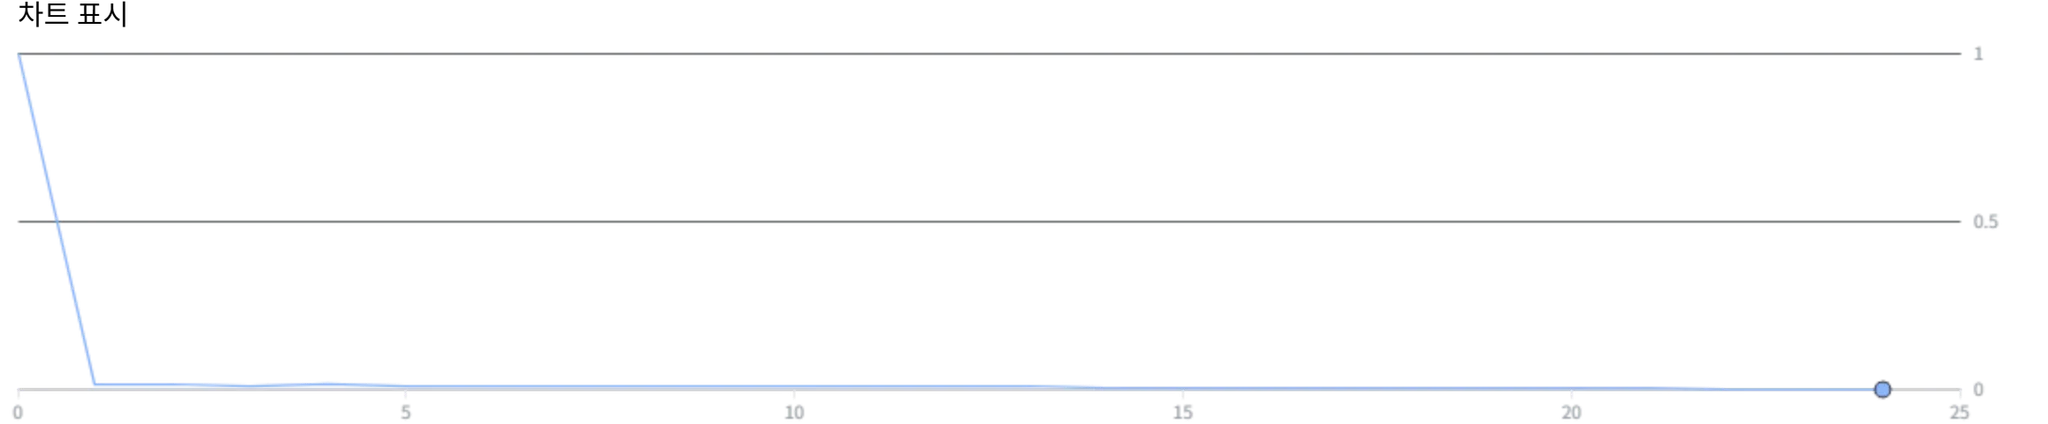

### 2-4. 각 이벤트 파악하며 든 궁금증들 해소

#### 로그인창 이탈 비율
→ 전체 세션 수: 105,080건

→ 로그인 시도: 105,079건

→ 로그인 시도 중 이탈한 경우: 1건

``` sql
WITH base AS (
  SELECT
    user_pseudo_id,
    session_id,
    event_datetime,
    event_name,
    param.value.string_value AS `firebase_screen`,
    platform
  FROM foodie.activate_user_logs, UNNEST(event_params) AS `param`
  WHERE param.key = 'firebase_screen' 
), total_activate_session_cnt AS ( # 전체 세션 수: 105,080건
  SELECT
    COUNT(*) AS `total_cnt`
  FROM (
    SELECT
      DISTINCT
        user_pseudo_id,
        session_id
    FROM base
  )
), click_login_session_cnt AS ( # 로그인 시도: 105,079건
  SELECT
    COUNT(*) AS `click_login_cnt`
  FROM (
    SELECT
      DISTINCT
        user_pseudo_id,
        session_id
    FROM base
    WHERE event_name = 'click_login'
  )
), select_click_login_session AS (
  SELECT
    * EXCEPT(check_num),
    MAX(check_num) OVER (PARTITION BY user_pseudo_id, session_id) AS `click_login_session`
  FROM (
    SELECT
      *,
      IF(event_name = 'click_login', 1, null) AS `check_num`
    FROM base
  )
  QUALIFY click_login_session IS NOT NULL
  ORDER BY user_pseudo_id, event_datetime
), set_next_event_name_with_screen AS (
  SELECT
    user_pseudo_id,
    session_id,
    event_name,
    CONCAT(next_event_name, '-',next_firebase_screen) AS `next_event_name_with_screen`
  FROM (
    SELECT
      *,
      LEAD(event_name) OVER (PARTITION BY user_pseudo_id, session_id ORDER BY event_datetime) AS `next_event_name`,
      LEAD(firebase_screen) OVER (PARTITION BY user_pseudo_id, session_id ORDER BY event_datetime) AS `next_firebase_screen`
    FROM select_click_login_session
    )
  WHERE event_name = 'click_login'
), login_session_cnt AS ( # 로그인 시도한 사람 중 이탈한 경우 : 0건
  SELECT
    COUNT(*)
  FROM (
    SELECT
      DISTINCT
        user_pseudo_id,
        session_id
    FROM set_next_event_name_with_screen
    WHERE NOT next_event_name_with_screen = 'screen_view-home'
  )
)
```

#### 로그인 후 바로 이탈한 세션 비율
→ 로그인: 105,079건

→ 바로 이탈: 27,126건

→ 27,126 / 105,079 **≈** <mark>0.26

``` sql
WITH base AS (
  SELECT
    user_pseudo_id,
    session_id,
    event_datetime,
    event_name,
    param.value.string_value AS `firebase_screen`,
    platform
  FROM foodie.activate_user_logs, UNNEST(event_params) AS `param`
  WHERE param.key = 'firebase_screen'
), total_activate_session_cnt AS (
  SELECT
    COUNT(*) AS `total_cnt`
  FROM (
    SELECT
      DISTINCT
        user_pseudo_id,
        session_id
    FROM base
  )
), click_login_session_cnt AS ( # 로그인 시도: 105,079건
  SELECT
    COUNT(*) AS `click_login_cnt`
  FROM (
    SELECT
      DISTINCT
        user_pseudo_id,
        session_id
    FROM base
    WHERE event_name = 'click_login'
  )
), select_click_login_session AS (
  SELECT
    * EXCEPT(check_num),
    MAX(check_num) OVER (PARTITION BY user_pseudo_id, session_id) AS `click_login_session`
  FROM (
    SELECT
      *,
      IF(event_name = 'click_login', 1, null) AS `check_num`
    FROM base
  )
  QUALIFY click_login_session IS NOT NULL
  ORDER BY user_pseudo_id, event_datetime
), set_event_name_with_screen AS (
  SELECT
    user_pseudo_id,
    session_id,
    event_datetime,
    CONCAT(event_name, '-', firebase_screen) AS `event_name_with_screen`,
    CONCAT(next_event_name, '-', next_firebase_screen) AS `next_event_name_with_screen`,
    CONCAT(pre_event_name, '-', pre_firebase_screen) AS `pre_event_name_with_screen`
  FROM (
    SELECT
      *,
      LEAD(event_name) OVER (PARTITION BY user_pseudo_id, session_id ORDER BY event_datetime) AS `next_event_name`,
      LEAD(firebase_screen) OVER (PARTITION BY user_pseudo_id, session_id ORDER BY event_datetime) AS `next_firebase_screen`,
      LAG(event_name) OVER (PARTITION BY user_pseudo_id, session_id ORDER BY event_datetime) AS `pre_event_name`,
      LAG(firebase_screen) OVER (PARTITION BY user_pseudo_id, session_id ORDER BY event_datetime) AS `pre_firebase_screen`
    FROM select_click_login_session
    )
)

SELECT
  COUNT(*) AS `cnt_of_leave_after_login`
FROM set_event_name_with_screen
WHERE event_name_with_screen = 'screen_view-home'
  AND pre_event_name_with_screen = 'click_login-welcome'
  AND next_event_name_with_screen IS NULL;
  ```

#### 홈화면에서 배너 광고 클릭 횟수

→ 한 번의 접속에서 두 번 이상 광고를 클릭한 경우는 없음

``` sql
SELECT
  COUNT(*)
FROM foodie.activate_user_logs
WHERE event_name = 'click_banner'
GROUP BY user_pseudo_id, session_id
HAVING COUNT(*) > 1;
```

---

→ 사용자가 늘어남에 따라 광고 클릭도 증가

→ 공휴일에 배너 클릭 증가

``` sql
SELECT
  event_date,
  COUNT(*) AS `banner_cnt`
FROM foodie.activate_user_logs
WHERE event_name = 'click_banner'
GROUP BY event_date
ORDER BY event_date;
```

---

→ 광고를 클릭하고 바로 이탈하는 세션 확인 (전체)

→ 총 광고 클릭 세션: 19,179건

→ 광고 클릭 후 바로 이탈 세션: 5,968건

→ 이탈률: 31%

``` sql
WITH base AS (
  SELECT
    user_pseudo_id,
    session_id,
    event_datetime,
    CONCAT(event_name, '-', value.string_value) AS `event_name_with_screen`
  FROM (
    SELECT
      * EXCEPT(event_date, platform, event_params)
    FROM foodie.activate_user_logs, UNNEST(event_params) AS param
    )
  WHERE `key` = 'firebase_screen'
), select_banner_session AS (
  SELECT
    * EXCEPT(check_num),
    MAX(check_num) OVER (PARTITION BY user_pseudo_id, session_id) AS `click_banner_session`,
    SUM(check_num) OVER() AS `total_click_banner_cnt`
  FROM (
    SELECT
      *,
      IF(event_name_with_screen = 'click_banner-home', 1, null) AS `check_num` 
    FROM base
    )
  QUALIFY click_banner_session IS NOT NULL
), count_click_banner_event AS (
  SELECT
    COUNT(*) AS leave_after_click_banner_cnt,
    MAX(total_click_banner_cnt) AS total_click_banner_cnt,
    ROUND(SAFE_DIVIDE(COUNT(*), MAX(total_click_banner_cnt)), 2) AS leave_ratio 
  FROM (
    SELECT
      * EXCEPT(click_banner_session),
      LEAD(event_name_with_screen) OVER (PARTITION BY user_pseudo_id, session_id ORDER BY event_datetime) AS `next_event_name_with_screen`
    FROM select_banner_session
    )
  WHERE event_name_with_screen = 'click_banner-home'
    AND next_event_name_with_screen IS NULL
```

---

→ 광고를 클릭하고 바로 이탈하는 세션 확인 (일별)

→ 공휴일에 광고를 클릭했을 때 이탈하는 비율이 현저하게 낮음

``` sql
WITH base AS (
  SELECT
    user_pseudo_id,
    session_id,
    event_date,
    event_datetime,
    CONCAT(event_name, '-', value.string_value) AS `event_name_with_screen`
  FROM (
    SELECT
      * EXCEPT(platform, event_params)
    FROM foodie.activate_user_logs, UNNEST(event_params) AS param
    )
  WHERE `key` = 'firebase_screen'
), select_banner_session AS (
  SELECT
    * EXCEPT(check_num),
    MAX(check_num) OVER (PARTITION BY user_pseudo_id, session_id) AS `click_banner_session`,
    SUM(check_num) OVER(PARTITION BY event_date) AS `daily_click_banner_cnt`
  FROM (
    SELECT
      *,
      IF(event_name_with_screen = 'click_banner-home', 1, null) AS `check_num` 
    FROM base
    )
  QUALIFY click_banner_session IS NOT NULL
), daily_count_click_banner_event AS (
  SELECT
    event_date,
    COUNT(*) AS leave_after_click_banner_cnt,
    daily_click_banner_cnt,
    ROUND(SAFE_DIVIDE(COUNT(*), MAX(daily_click_banner_cnt)), 2) AS leave_ratio 
  FROM (
    SELECT
      * EXCEPT(click_banner_session),
      LEAD(event_name_with_screen) OVER (PARTITION BY user_pseudo_id, session_id ORDER BY event_datetime) AS `next_event_name_with_screen`
    FROM select_banner_session
    )
  WHERE event_name_with_screen = 'click_banner-home'
    AND next_event_name_with_screen IS NULL
  GROUP BY event_date, daily_click_banner_cnt
)

SELECT *
FROM daily_count_click_banner_event
ORDER BY event_date;
```

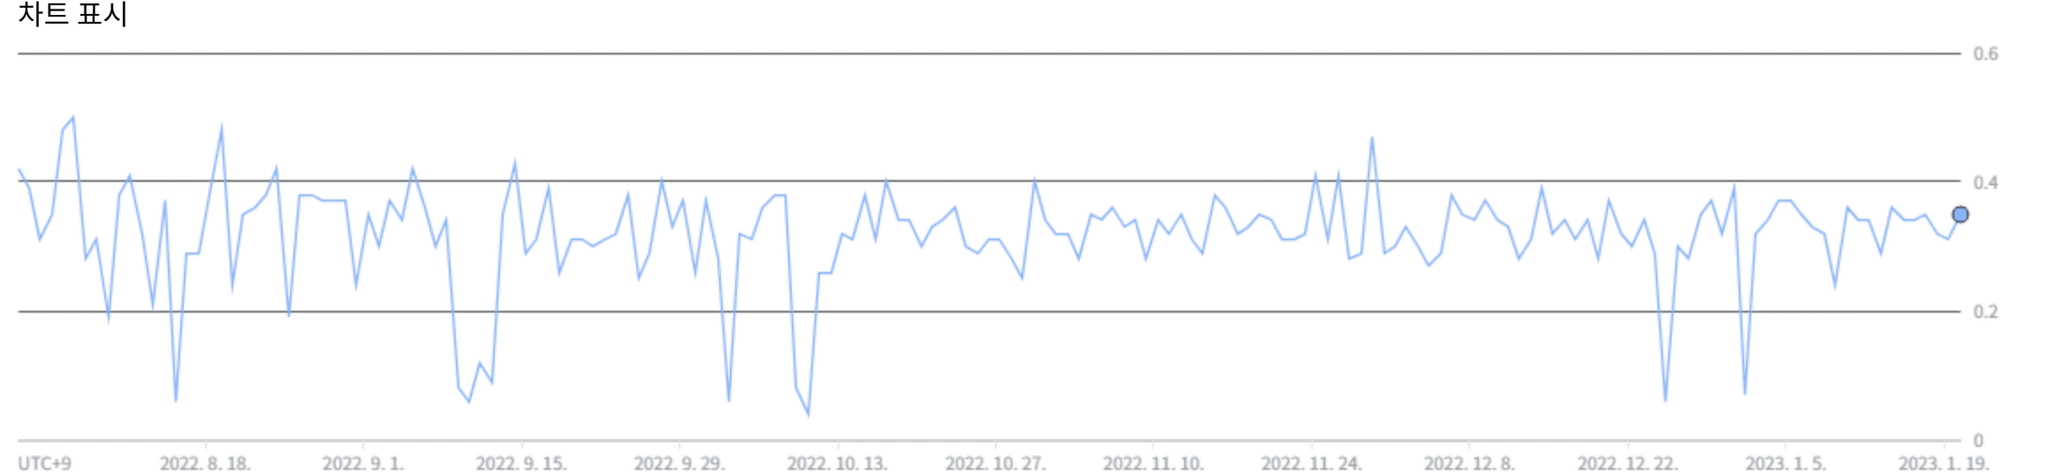

#### banner_id와 restaurant_id, food_id 중 겹치는게 있는지 확인

→ banner_id와 restaurant_id 겹치는 경우 없음

``` sql
WITH base AS (
  SELECT
    * EXCEPT(platform, event_params)
  FROM foodie.activate_user_logs, UNNEST(event_params) AS param
), select_banner_id AS(
  SELECT
    DISTINCT
      value.int_value AS `banner_id`
  FROM base
  WHERE key = 'banner_id'
)

SELECT *
FROM base
WHERE key = 'restaurant_id' AND value.int_value IN (SELECT * FROM select_banner_id);
```

---

→ banner_id와 food_id 겹치는 경우 없음

``` sql
WITH base AS (
  SELECT
    * EXCEPT(platform, event_params)
  FROM foodie.activate_user_logs, UNNEST(event_params) AS param
), select_banner_id AS(
  SELECT
    DISTINCT
      value.int_value AS `banner_id`
  FROM base
  WHERE key = 'banner_id'
)

SELECT *
FROM base
WHERE key = 'food_id' AND value.int_value IN (SELECT * FROM select_banner_id);
```

#### 가장 많이 검색해본 검색어 파악
→ 검색어 중 키워드가 깨진 경우가 있는데 전처리

→ ‘ㅊㅋ’, ‘ㅊ킨’을 ‘치킨’으로 통일

→ 검색 기능은 주로 치킨을 검색해보는데 사용

##### 전체 검색 키워드 순위 Top10

``` sql
WITH base AS (
  SELECT
    * EXCEPT(platform, event_params)
  FROM foodie.activate_user_logs, UNNEST(event_params) AS param
)

SELECT
  search_keyword,
  COUNT(*) AS `keyword_cnt`
FROM (
  SELECT
    event_datetime,
    IF(value.string_value IN ('ㅊㅋ', 'ㅊ킨'), '치킨', value.string_value) AS `search_keyword`
  FROM base
  WHERE event_name = 'request_search' AND key = 'search_keyword'
  )
GROUP BY search_keyword
ORDER BY keyword_cnt DESC
LIMIT 10;
```

| search\_keyword | keyword\_cnt |
| --------------- | -----------: |
| 치킨              |         4150 |
| 커피              |         1450 |
| 탄산              |         1417 |
| PM을 위한 데이터 리터러시 |         1415 |
| 피자              |         1411 |
| 햄버거             |         1411 |
| 카일              |         1375 |
| 국밥              |         1363 |
| 스시              |         1362 |
| BigQuery 입문     |         1339 |

##### 월별 검색 키워드 순위 Top3

→ 22년 8월 (치킨 > 탄산 > 커피)

→ 22년 9월 (치킨 > 커피 > 탄산)

→ 22년 10월 (치킨 > 햄버거 > 피자)

→ 22년 11월 (치킨 > 탄산 > 피자)

→ 22년 12월 (치킨 > PM을 위한 데이터 리터러시 > 커피)

→ 23년 1월 (치킨 > 커피 > 국밥)

``` sql
WITH base AS (
  SELECT
    * EXCEPT(platform, event_params)
  FROM foodie.activate_user_logs, UNNEST(event_params) AS param
), count_search_keyword AS (
  SELECT
    event_year,
    event_month,
    search_keyword,
    COUNT(*) AS `keyword_cnt`
  FROM (
    SELECT
      EXTRACT(YEAR FROM event_date) AS `event_year`,
      EXTRACT(MONTH FROM event_date) AS `event_month`,
      IF(value.string_value IN ('ㅊㅋ', 'ㅊ킨'), '치킨', value.string_value) AS `search_keyword`
    FROM base
    WHERE event_name = 'request_search' AND key = 'search_keyword'
    )
  GROUP BY event_year, event_month, search_keyword
)

SELECT
  CONCAT(event_year, '-',event_month) AS `event_year_month`,
  search_keyword,
  keyword_cnt,
  RANK() OVER (PARTITION BY event_month ORDER BY keyword_cnt DESC) AS month_keyword_rank
FROM count_search_keyword
QUALIFY month_keyword_rank <= 3
ORDER BY event_year, event_month;
```

##### 시간대별 검색 횟수 파악

→ 검색을 많이 하는 시간대 전환율을 높일 필요 있어보임

→ 이른 아침 (4시 ~ 6시) : 426건 (전환수: 37건) → 약 9%

→ 아침 (7시 ~ 9시) : 641건 (전환수: 46건) → 약 7%

→ 늦은 아침 (10시 ~ 11시) : 1,360건 (전환수: 120건) → 약 9%

→ 점심 (12시 ~ 14시) : 3,687건 (전환수: 268건) → 약 7%

→ 애프터눈 티 (15시 ~ 16시) : 2,066건 (전환수: 148건) → 약 7%

→ 저녁 (17시 ~ 20시) : 5,112건 (전환수: 383건) → 약 7%

→ 야식 (21시 ~ 23시) : 2,779건 (전환수: 207건) → 약 7%

→ 늦은 야식 (0시 ~ 3시) :  622건 (전환수: 51건) → 약 8%

---

 → 시간대별 총 검색 횟수

``` sql
WITH base AS (
  SELECT
    * EXCEPT(platform, event_params)
  FROM foodie.activate_user_logs, UNNEST(event_params) AS param
), set_meal_time_keyword AS (
  SELECT
    CASE
      WHEN event_hour IN (0, 1, 2, 3) THEN '늦은 야식'
      WHEN event_hour IN (4, 5, 6) THEN '이른 아침'
      WHEN event_hour IN (7, 8, 9) THEN '아침'
      WHEN event_hour IN (10, 11) THEN '늦은 아침'
      WHEN event_hour IN (12, 13, 14) THEN '점심'
      WHEN event_hour IN (15, 16) THEN '애프터눈 티'
      WHEN event_hour IN (17, 18, 19, 20) THEN '저녁'
      WHEN event_hour IN (21, 22, 23) THEN  '야식'
    END AS meal_time,
    search_keyword
  FROM (
    SELECT
      EXTRACT(HOUR FROM event_datetime) AS `event_hour`,
      IF(value.string_value IN ('ㅊㅋ', 'ㅊ킨'), '치킨', value.string_value) AS `search_keyword`
    FROM base
    WHERE event_name = 'request_search' AND key = 'search_keyword'
    )
), keyword_count_by_time_slot AS (
  SELECT
    meal_time,
    COUNT(*) AS `keyword_cnt`
  FROM set_meal_time_keyword
  GROUP BY meal_time
)

SELECT *
FROM keyword_count_by_time_slot;
```

---

→ 시간대별 전환까지 이어진 검색 횟수

``` sql
WITH base AS (
  SELECT
    * EXCEPT(platform, event_params),
    IF(event_name = 'request_search', 1, null) AS `check_num`
  FROM foodie.activate_user_logs, UNNEST(event_params) AS param
  # WHERE event_date BETWEEN '2022-08-01' AND '2022-08-12'
), check_search_session AS (
  SELECT
    * EXCEPT(check_num),
    IF(event_name = 'click_payment', 1, null) AS `check_of_payment`
  FROM (
    SELECT
      * EXCEPT(check_num),
      MAX(check_num) OVER (PARTITION BY user_pseudo_id, session_id) `check_num`
    FROM base
    )
  WHERE check_num = 1
), check_search_payment_session AS (
  SELECT
    * EXCEPT(check_num),
  FROM (
    SELECT
      * EXCEPT(check_of_payment),
      MAX(check_of_payment) OVER (PARTITION BY user_pseudo_id, session_id) `check_num`
    FROM check_search_session
    )
  WHERE check_num = 1
), set_meal_time_keyword AS (
  SELECT
    CASE
      WHEN event_hour IN (0, 1, 2, 3) THEN '늦은 야식'
      WHEN event_hour IN (4, 5, 6) THEN '이른 아침'
      WHEN event_hour IN (7, 8, 9) THEN '아침'
      WHEN event_hour IN (10, 11) THEN '늦은 아침'
      WHEN event_hour IN (12, 13, 14) THEN '점심'
      WHEN event_hour IN (15, 16) THEN '애프터눈 티'
      WHEN event_hour IN (17, 18, 19, 20) THEN '저녁'
      WHEN event_hour IN (21, 22, 23) THEN  '야식'
    END AS meal_time,
    search_keyword
  FROM (
    SELECT
      EXTRACT(HOUR FROM event_datetime) AS `event_hour`,
      IF(value.string_value IN ('ㅊㅋ', 'ㅊ킨'), '치킨', value.string_value) AS `search_keyword`
    FROM check_search_payment_session
    WHERE event_name = 'request_search' AND key = 'search_keyword'
    )
), keyword_count_by_time_slot AS (
  SELECT
    meal_time,
    COUNT(*) AS `keyword_cnt`
  FROM set_meal_time_keyword
  GROUP BY meal_time
)

SELECT *
FROM keyword_count_by_time_slot;
```

##### 시간대별 검색 키워드 순위 Top3
→ 어느 시간대에서 검색해보고 전환까지 가는지가 높은지(모든 시간대에서 치킨 검색량이 많은데 검색해보고 바로 시켜먹는지 확인

→ 검색해보고 바로 시켜먹는 비율이 높은 시간대에 할인 이벤트 진행 등등)

---

→ 이른 아침 (4시 ~ 6시) : 치킨(109건) > 커피(46건) > 스시(44건)

→ 아침 (7시 ~ 9시) : 치킨(175건) > 커피(65건) > BigQuery 입문(64건)

→ 늦은 아침 (10시 ~ 11시) : 치킨(310건) > 피자(130건) > 탄산, 스시(125건)

→ 점심 (12시 ~ 14시) : 치킨(926건) > 국밥(321건) > 커피(318건)

→ 애프터눈 티 (15시 ~ 16시) : 치킨(513건) > 피자(193건) > 탄산(182건)

→ 저녁 (17시 ~ 20시) : 치킨(1,273건) > 커피(459건) > 탄산(440건)

→ 야식 (21시 ~ 23시) : 치킨(700건) > PM을 위한 데이터 리터러시(249건) > 탄산(249건)

→ 늦은 야식 (0시 ~ 3시) : 치킨(144건) > PM을 위한 데이터 리터러시, 피자(60건)

``` sql
WITH base AS (
  SELECT
    * EXCEPT(platform, event_params)
  FROM foodie.activate_user_logs, UNNEST(event_params) AS param
), set_meal_time_keyword AS (
  SELECT
    CASE
      WHEN event_hour IN (0, 1, 2, 3) THEN '늦은 야식'
      WHEN event_hour IN (4, 5, 6) THEN '이른 아침'
      WHEN event_hour IN (7, 8, 9) THEN '아침'
      WHEN event_hour IN (10, 11) THEN '늦은 아침'
      WHEN event_hour IN (12, 13, 14) THEN '점심'
      WHEN event_hour IN (15, 16) THEN '애프터눈 티'
      WHEN event_hour IN (17, 18, 19, 20) THEN '저녁'
      WHEN event_hour IN (21, 22, 23) THEN  '야식'
    END AS meal_time,
    search_keyword
  FROM (
    SELECT
      EXTRACT(HOUR FROM event_datetime) AS `event_hour`,
      IF(value.string_value IN ('ㅊㅋ', 'ㅊ킨'), '치킨', value.string_value) AS `search_keyword`
    FROM base
    WHERE event_name = 'request_search' AND key = 'search_keyword'
    )
)

SELECT
  *,
  RANK() OVER (PARTITION BY meal_time ORDER BY keyword_cnt DESC) AS month_keyword_rank
FROM (
  SELECT
    meal_time,
    search_keyword,
    COUNT(*) AS `keyword_cnt`
  FROM set_meal_time_keyword
  GROUP BY meal_time, search_keyword
  )
QUALIFY month_keyword_rank <= 3
ORDER BY meal_time, keyword_cnt DESC;
```

#### 사용자들이 가장 관심있는 Food_category 파악

→ 카테고리 종류(제공된 데이터상): 한식, 고기, 햄버거, 피자, 커피, 일식

``` sql
WITH base AS (
  SELECT
    user_pseudo_id,
    session_id,
    event_date,
    event_datetime,
    param.value.string_value AS `food_category`
  FROM foodie.activate_user_logs, UNNEST(event_params) AS `param`
  WHERE event_name = 'click_food_category' AND param.key = 'food_category'
)

SELECT
  food_category,
  COUNT(*) AS `food_category_cnt`
FROM base
GROUP BY food_category
ORDER BY food_category_cnt DESC;
```

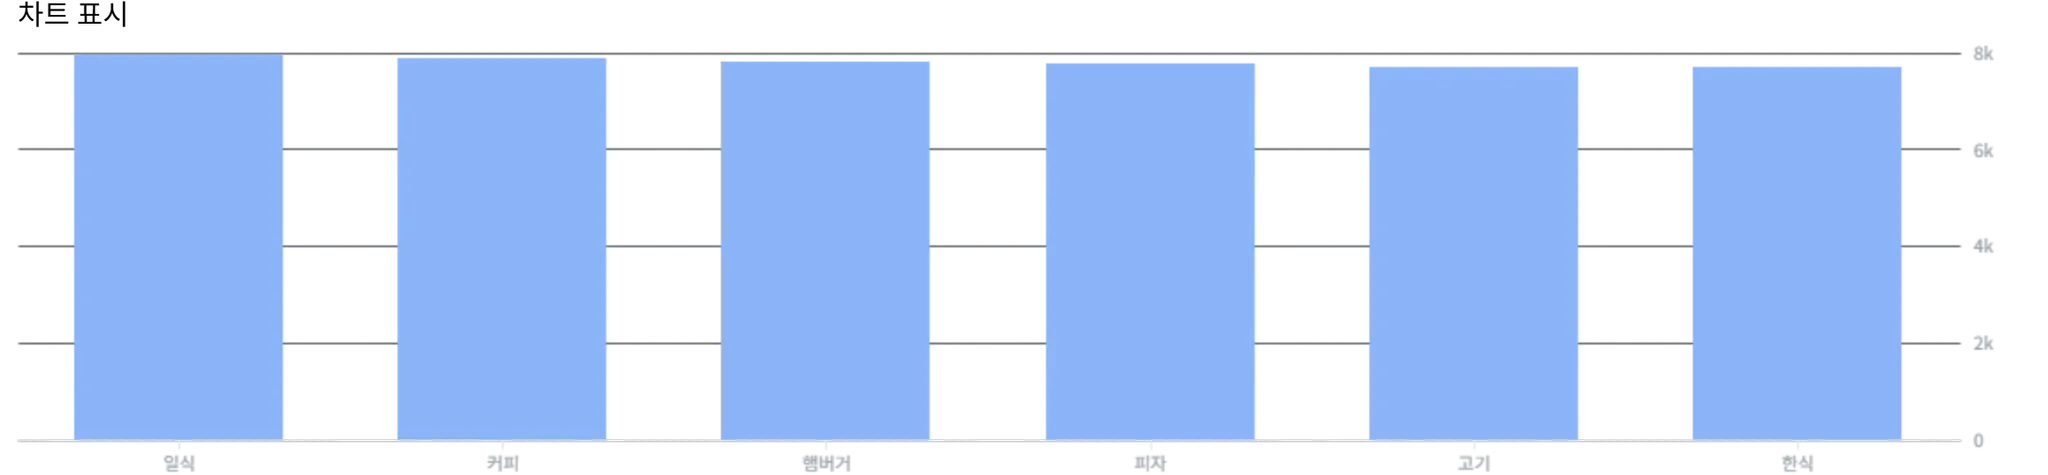

#### screen_view-cart에 진입할 때 취소 주문 금액 충족 여부
→ 충족: 4,427건

→ 불충족: 16,138건

``` sql
WITH base AS (
  SELECT
    * EXCEPT(platform, event_params),
  FROM foodie.activate_user_logs, UNNEST(event_params) AS param
), check_cart_session AS (
  SELECT
    * EXCEPT (check_num),
    MAX(check_num) OVER (PARTITION BY user_pseudo_id, session_id) AS `check_num`
  FROM (
    SELECT
      *,
      IF(event_name = 'view_recommend_extra_food', 1, null) AS `check_num`
    FROM base
    )
), select_cart_session AS (
  SELECT
    user_pseudo_id,
    session_id,
    event_datetime,
    value.int_value AS `is_meet_min_order_price`
  FROM check_cart_session
  WHERE event_name = 'view_recommend_extra_food' AND key = 'is_meet_min_order_price'
)

SELECT 
  is_meet_min_order_price,
  COUNT(*) AS `cnt`
FROM (
  SELECT
    user_pseudo_id,
    session_id,
    event_datetime,
    IF(is_meet_min_order_price = 1, '충족', '불충족') AS `is_meet_min_order_price`
  FROM select_cart_session)
GROUP BY is_meet_min_order_price;
```

#### 추천 음식을 얼마나 추가하는지 파악
→ 충족: 1,387건

→ 불충족: 5,118건

``` sql
WITH base AS (
  SELECT
    * EXCEPT(platform, event_params),
  FROM foodie.activate_user_logs, UNNEST(event_params) AS param
  WHERE event_name = 'click_recommend_extra_food'
)

SELECT
  is_meet_min_order_price,
  COUNT(*) AS `cnt`
FROM (
  SELECT
    user_pseudo_id,
    session_id,
    event_datetime,
    IF(is_meet_min_order_price = 1, '충족', '불충족') AS `is_meet_min_order_price`
  FROM base
  WHERE key='is_meet_min_order_price'
  )
GROUP BY is_meet_min_order_price;
```

#### 추천 음식을 추가하고 결제까지 이어지는 비율
→ 충족: 900건

→ 불충족: 3,307건

---

→ 최소 주문 금액 채운 경우:

    → 4,427(screen_view-cart 진입) — 31% → 1,387(extra_food 클릭) — 65% → 900(결제)

→ 최소 주문 금액 채우지 못한 경우:

    → 16,138(screen_view-cart 진입) — 32% → 5,118(extra_food 클릭) — 65% → 3,307(결제)

``` sql
WITH base AS (
  SELECT
    * EXCEPT(platform, event_params),
  FROM foodie.activate_user_logs, UNNEST(event_params) AS param
), check_extra_food_session AS (
  SELECT
    *,
    IF(event_name = 'click_recommend_extra_food', 1, null) AS `extra_check_num`
  FROM base
), select_extra_food_session AS (
  SELECT
    * EXCEPT(check)
  FROM (
    SELECT
      * EXCEPT(extra_check_num),
      MAX(extra_check_num) OVER (PARTITION BY user_pseudo_id, session_id) AS `check`
    FROM check_extra_food_session
  )
  WHERE check = 1
), select_extra_payment_session AS (
  SELECT
    * EXCEPT(check),
    MAX(check) OVER (PARTITION BY user_pseudo_id, session_id) AS `payment_check_num`
  FROM (
    SELECT
      *,
      IF(event_name = 'click_payment', 1, null) AS `check`
    FROM select_extra_food_session
    )
  QUALIFY payment_check_num = 1
), is_meet_min_order_user_recommend_food AS (
SELECT
    DISTINCT
      user_pseudo_id,
      session_id,
      event_date,
      MAX(use_recommend_food) OVER (PARTITION BY user_pseudo_id, session_id) AS `use_recommend_food`,
      MAX(is_meet_min_order_price) OVER (PARTITION BY user_pseudo_id, session_id) AS `is_meet_min_order_price`
  FROM (
    SELECT
      user_pseudo_id,
      session_id,
      event_date,
      value.string_value AS `use_recommend_food`,
      value.int_value AS `is_meet_min_order_price`
    FROM select_extra_payment_session
      WHERE (event_name = 'click_payment' AND key = 'use_recommend_food') OR (event_name = 'click_recommend_extra_food' AND key='is_meet_min_order_price')
  )
)

SELECT
  is_meet_min_order_price,
  COUNT(*) AS `cnt`
FROM is_meet_min_order_user_recommend_food
GROUP BY is_meet_min_order_price;
```

#### 앱에서 제공하는 결제 수단 사용 비율 파악
→ 자체 결제 수단 사용률 저조

→ card: 11,167건

→ foodiepay: 1,992건

``` sql
WITH base AS (
  SELECT
    * EXCEPT(platform, event_params),
  FROM foodie.activate_user_logs, UNNEST(event_params) AS param
  WHERE event_name = 'click_payment' AND key = 'payment_type'
)

SELECT
  value.string_value AS `payment_type`,
  COUNT(*) AS `cnt`
FROM base
GROUP BY value.string_value;
```

## 3. 가설 설정 및 검정
활성 사용자는 증가하다가 어느 정도의 변동폭이 있지만 유지되는 현상을 보이고, 전환까지 이어지는 수는 데이터 수집기간 동안 큰 폭의 상승은 없고 현상 유지 중이다. 또한, 활성 사용자 수가 증가하긴 했으나 리텐션은 매우 떨어져서 지속적으로 이용하는 사용자가 거의 없었다. 그러던 일별 전환수를 확인하던 중 눈에 띄게 전환이 많이 이뤄지는 피크를 파악하였다. 바로 공휴일에 접속하는 사용자들의 전화율이다. 공휴일에 접속 사용자들 중 결제까지 이어지는 비율이 다른 날에 비해 월등히 높았다. 또한, 광고 클릭 직후 이탈하는 수치 역시 다른 날에 비해 현저히 떨어졌다. 따라서 이번 파트에서 공휴일 사용자 대상으로 여러 가설을 세워보고 세운 가설들을 검정해보면서 구체적인 목표를 설정하고자 한다. 공휴일 접속 사용자들을 대상으로 가설을 확인하기 위해 활성 사용자를 공휴일/평일/주말 접속 사용자로 구분하여 비교/분석을 진행하였다.

---

> 공휴일
>
> → 광복절 (22년 8월 15일)
> 
>→ 추석 연휴 (22년 9월 9일 ~ 22년 9월 12일)
>
>→ 개천절 (22년 10월 3일)
>
>→ 한글날 연휴 (22년 10월 9일 ~ 22년 10월 10일)
>
>→ 크리스마스 (22년 12월 25일)
>
>→ 신정 ( 23년 1월 1일)

### 3-1. 공휴일/비공휴일(주말)/비공휴일(평일) 접속 사용자 구분

``` sql
DECLARE
  holiday_date ARRAY<DATE>;
SET
  holiday_date = [DATE '2022-08-15', DATE '2022-09-09',
  DATE '2022-09-10', DATE '2022-09-11', DATE '2022-09-12',
  DATE '2022-10-03', DATE '2022-10-09', DATE '2022-10-10', 
  DATE '2022-12-25', DATE '2023-01-01'];

-- 공휴일 --
# 단순 날짜로 하면 세션 중 날이 바뀌는 경우 발생 가능
CREATE OR REPLACE TABLE `foodie.holiday_user_log` AS (
WITH base AS (
  SELECT
    * EXCEPT(check_num),
    MAX(check_num) OVER (PARTITION BY user_pseudo_id, session_id) AS `is_holiday_session`
  FROM (
    SELECT
      *,
      IF(event_date IN UNNEST(holiday_date), 1, null) AS `check_num`
    FROM foodie.activate_user_logs
  )
  QUALIFY is_holiday_session = 1
)

SELECT * EXCEPT(is_holiday_session)
FROM base
);

-- 주말 --
CREATE OR REPLACE TABLE `foodie.weekend_user_log` AS (
WITH base AS (
  SELECT
    * EXCEPT(check_num, day_of_week),
    MAX(check_num) OVER (PARTITION BY user_pseudo_id, session_id) AS `is_weekend_session`
  FROM (
    SELECT
      *,
      FORMAT_DATE('%A', event_date) AS `day_of_week`,
      IF(event_date NOT IN UNNEST(holiday_date), 1, null) AS `check_num`
    FROM foodie.activate_user_logs
  )
  WHERE day_of_week IN ('Saturday', 'Sunday')
  QUALIFY is_weekend_session = 1
)

SELECT * EXCEPT(is_weekend_session)
FROM base
);

-- 평일 --
CREATE OR REPLACE TABLE `foodie.weekdays_user_log` AS (
WITH base AS (
  SELECT
    * EXCEPT(check_num, day_of_week),
    MAX(check_num) OVER (PARTITION BY user_pseudo_id, session_id) AS `is_weekdays_session`
  FROM (
    SELECT
      *,
      FORMAT_DATE('%A', event_date) AS `day_of_week`,
      IF(event_date NOT IN UNNEST(holiday_date), 1, null) AS `check_num`
    FROM foodie.activate_user_logs
  )
  WHERE day_of_week NOT IN ('Saturday', 'Sunday')
  QUALIFY is_weekdays_session = 1
)

SELECT * EXCEPT(is_weekdays_session)
FROM base
);
```

### 3-2. 공휴일에 접속하는 사용자들은 충동적으로 들어오는 첫 방문 유저가 많을 것이다.
→ 이전에 접속하고 공휴일에 재접속하는 비율이 갈수록 증가하고 있다. 첫 방문 유저가 많을 것이란 가정은 기각한다. 그리고 이전 방문에 결제까지한 유저의 재방문률이 높을 것으로 생각했으나 재방문률이 높은 크리스마스나 신정에 이전 접속 기록 중 결제한 비율이 낮아 이 가설 역시 기각

#### 광복절

유저 1. 

    (22년 8월 13일 접속): 카테고리(피자) 퍼널 → 음식점 페이지에서 이탈

    (22년 8월 15일 접속): 카테고리(햄버거) 퍼널 → 결제 완료

---

유저 2. 3498785753.1319250196

    (22년 8월 13일 접속): 음식 추천 퍼널 → 결제 완료

    (22년 8월 15일 접속): 카테고리(피자) 퍼널 → 음식점 페이지에서 이탈

---

유저 3. 4229996642.1739377453

    (22년 8월 13일 접속): 음식 추천 퍼널 → 장바구니 페이지에서 이탈

    (22년 8월 15일 접속): 카테고리(고기) 퍼널 → 음식 상세 페이지에서 이탈

---

##### 공통 쿼리

```sql
WITH holiday_user AS (
  SELECT
    DISTINCT
      user_pseudo_id,
      event_date
  FROM foodie.holiday_user_logs
  WHERE event_date = '2022-08-15'
), past_logs AS (
  SELECT *
  FROM foodie.activate_user_logs
  WHERE event_date < '2022-08-15'
), past_user AS (
  SELECT
     DISTINCT
      user_pseudo_id,
      event_date
  FROM past_logs
  WHERE user_pseudo_id IN (SELECT user_pseudo_id FROM holiday_user)
)
```

##### 광복절에 접속한 사용자 파악
→ 광복절 접속 사용자: 218명

``` sql
SELECT
  DISTINCT user_pseudo_id
FROM holiday_user;
```

##### 광복절 이전 접속 사용자 파악
→ 광복절 접속 사용자 중 광복절 접속 이전 접속 사용자: 3명

→ 이전 접속 사용자 비율: 1%

``` sql
SELECT
  DISTINCT user_pseudo_id
FROM past_user;
```

#### 추석 연휴

##### 공통쿼리

```sql
WITH holiday_user AS (
  SELECT
    DISTINCT
      user_pseudo_id,
      event_date
  FROM foodie.holiday_user_logs
  WHERE event_date IN ('2022-09-09', '2022-09-10', '2022-09-11', '2022-09-12')
), past_logs AS (
  SELECT *
  FROM foodie.activate_user_logs
  WHERE event_date < '2022-09-09'
), past_user AS (
  SELECT
     DISTINCT
      user_pseudo_id,
      event_date
  FROM past_logs
  WHERE user_pseudo_id IN (SELECT user_pseudo_id FROM holiday_user)
)
```

##### 추석 연휴에 접속한 사용자 파악
→ 추석 연휴 접속 사용자: 1,643명

``` sql
SELECT
  DISTINCT user_pseudo_id
FROM holiday_user;
```

##### 추석 연휴 이전 접속 사용자 파악
→ 추석 연휴 접속 사용자 중 추석 연휴 이전 접속 사용자: 248명

→ 이전 접속 사용자 비율: 15%

```sql
SELECT
  DISTINCT user_pseudo_id
FROM past_user;
```

##### 이전 접속한 기록이 있는 사용자들 중 추석 연휴에 결제한 사용자 파악
→ 32명

→ 이전 접속 기록이 있는 사용자 중 결제한 사용자 비율: 13%

```sql
SELECT
  DISTINCT user_pseudo_id
FROM past_logs
WHERE event_name = 'click_payment'
```

##### 이전 접속 중 결제까지 한 사용자 파악
→ 104명

→ 이전 접속 중 결제한 사용자 비율: 42%

``` sql
SELECT
  DISTINCT user_pseudo_id
FROM foodie.holiday_user_logs
WHERE user_pseudo_id IN (SELECT DISTINCT user_pseudo_id FROM past_user)
  AND event_name = 'click_payment';
```

##### 이전 접속이 다른 공휴일이었던 사용자 파악
→ 7명

``` sql
SELECT
  DISTINCT user_pseudo_id
FROM past_user
WHERE event_date = '2022-08-15';
```

##### 이전 접속이 다른 공휴일이었던 사용자 중 결제까지 한 사용자 파악
→ 2명

``` sql
SELECT
  DISTINCT user_pseudo_id
FROM past_logs
WHERE user_pseudo_id IN (SELECT user_pseudo_id FROM holiday_user)
  AND event_date = '2022-08-15'
  AND event_name = 'click_payment';
  ```

##### 추석 연휴 이전 접속 이후 연휴에 몇일만에 재접속했는지 파악

``` sql
SELECT
  diff_of_date,
  COUNT(*) AS `cnt`
FROM (
  SELECT
    n.user_pseudo_id,
    n.event_date AS `not_holiday_date`,
    h.event_date AS `holiday_date`,
    DATE_DIFF(h.event_date, n.event_date, DAY) AS `diff_of_date`
  FROM past_user AS n INNER JOIN holiday_user AS h ON n.user_pseudo_id = h.user_pseudo_id
  )
GROUP BY diff_of_date
ORDER BY diff_of_date;
```

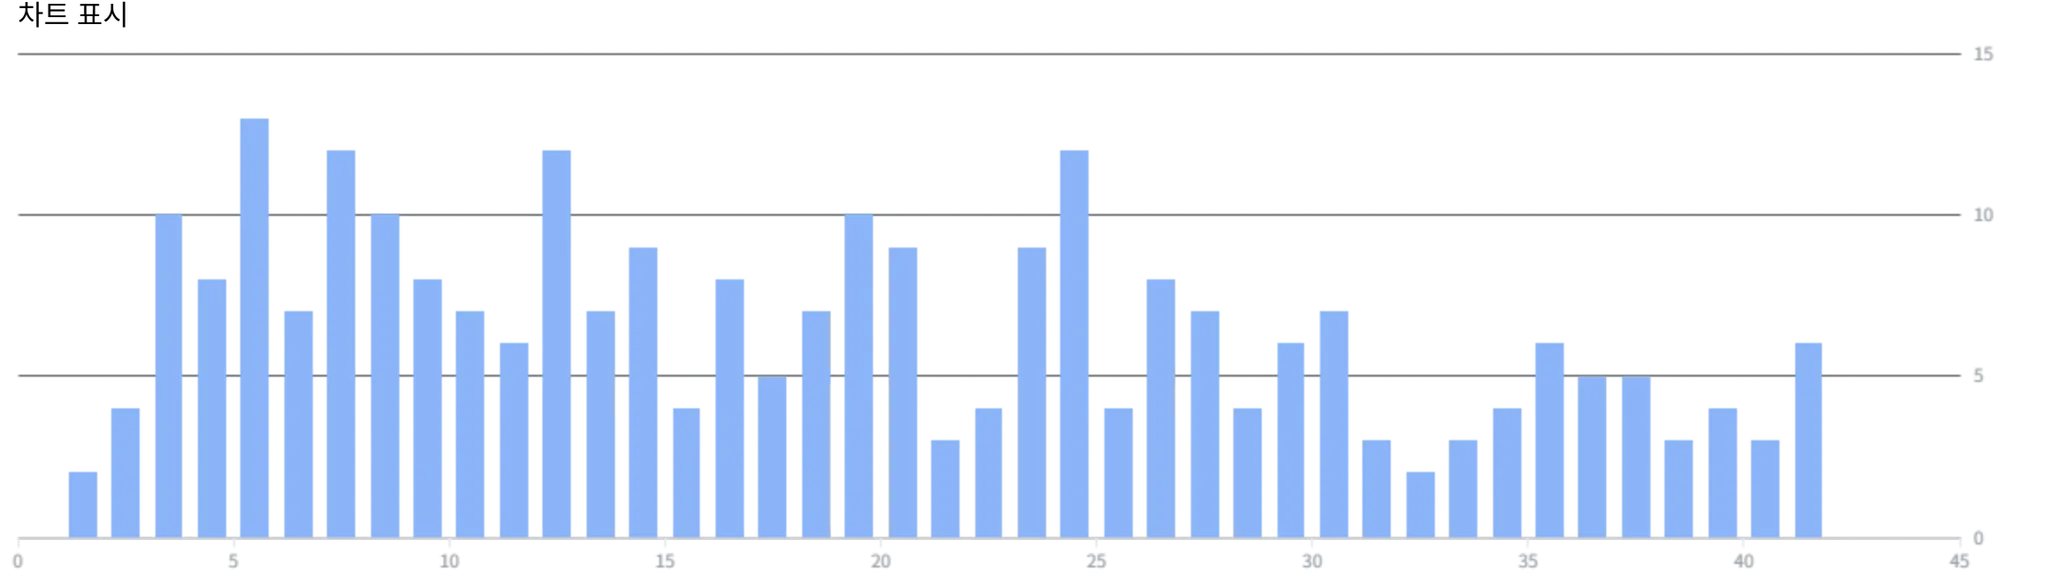

#### 개천절

##### 공통쿼리

``` sql
WITH holiday_user AS (
  SELECT
    DISTINCT
      user_pseudo_id,
      event_date
  FROM foodie.holiday_user_logs
  WHERE event_date = '2022-10-03'
), past_logs AS (
  SELECT *
  FROM foodie.activate_user_logs
  WHERE event_date < '2022-10-03'
), past_user AS (
  SELECT
     DISTINCT
      user_pseudo_id,
      event_date
  FROM past_logs
  WHERE user_pseudo_id IN (SELECT user_pseudo_id FROM holiday_user)
)
```

##### 개천절에 접속한 사용자 파악
→ 개천절 접속 사용자: 631명

``` sql
SELECT
  DISTINCT user_pseudo_id
FROM holiday_user;
```

##### 개천절 이전 접속 사용자 파악
→ 개전전 접속 사용자 중 개천절 이전 접속 사용자: 179명

→ 이전 접속 사용자 비율: 28%

``` sql
SELECT
  DISTINCT user_pseudo_id
FROM past_user;
```

##### 이전 접속한 기록이 있는 사용자들 중 개천절에 결제한 사용자 파악
→ 79명

→ 이전 접속 기록이 있는 사용자 중 결제한 사용자 비율: 44%

``` sql
SELECT
  DISTINCT user_pseudo_id
FROM foodie.holiday_user_logs
WHERE user_pseudo_id IN (SELECT DISTINCT user_pseudo_id FROM past_user)
  AND event_name = 'click_payment';
  ```

##### 이전 접속 중 결제까지 한 사용자 파악
→ 25명

→ 이전 접속 사용자 중 결제한 사용자 비율: 14%

``` sql
SELECT
  DISTINCT user_pseudo_id
FROM past_logs
WHERE event_name = 'click_payment'
  AND user_pseudo_id IN (SELECT DISTINCT user_pseudo_id FROM holiday_user);
  ```

##### 이전 접속이 다른 공휴일이었던 사용자 파악
→ 18명

``` sql
SELECT
  DISTINCT user_pseudo_id
FROM past_user
WHERE event_date IN ('2022-08-15', '2022-09-09', '2022-09-10', '2022-09-11', '2022-09-12');
```

##### 이전 접속이 다른 공휴일이었던 사용자 중 결제까지 한 사용자 파악
→ 8명

``` sql
SELECT
  DISTINCT user_pseudo_id
FROM past_logs
WHERE user_pseudo_id IN (SELECT user_pseudo_id FROM holiday_user)
  AND event_date IN ('2022-08-15', '2022-09-09', '2022-09-10', '2022-09-11', '2022-09-12')
  AND event_name = 'click_payment';
  ```

##### 개천절 이전 접속 이후 개천절에 몇일만에 재접속했는지 파악

``` sql
SELECT
  diff_of_date,
  COUNT(*) AS `cnt`
FROM (
  SELECT
    n.user_pseudo_id,
    n.event_date AS `not_holiday_date`,
    h.event_date AS `holiday_date`,
    DATE_DIFF(h.event_date, n.event_date, DAY) AS `diff_of_date`
  FROM past_user AS n INNER JOIN holiday_user AS h ON n.user_pseudo_id = h.user_pseudo_id
  )
GROUP BY diff_of_date
ORDER BY diff_of_date;
```

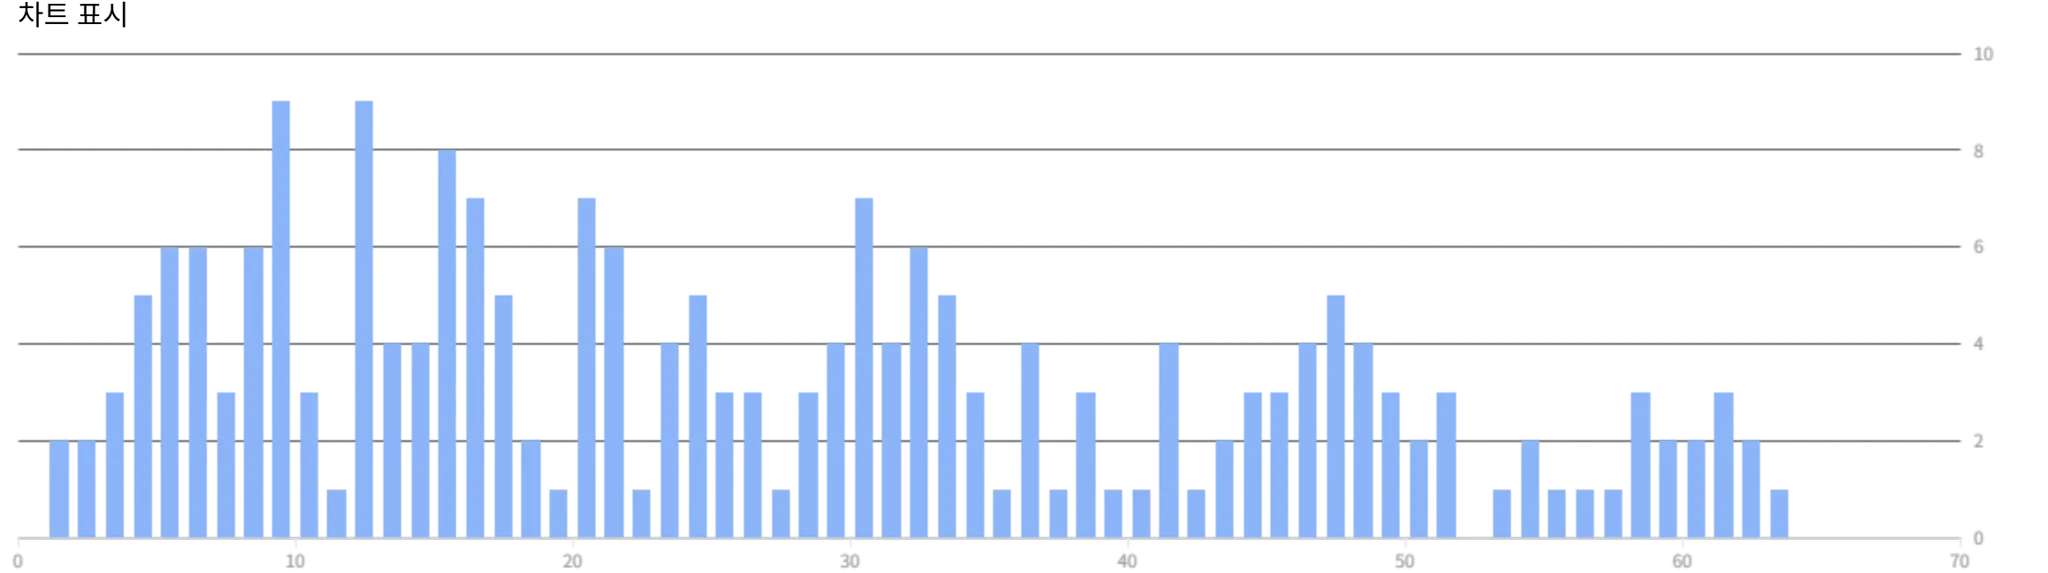

#### 한글날 연휴

##### 공통 쿼리

``` sql
WITH holiday_user AS (
  SELECT
    DISTINCT
      user_pseudo_id,
      event_date
  FROM foodie.holiday_user_logs
  WHERE event_date IN ('2022-10-09', '2022-10-10')
), past_logs AS (
  SELECT *
  FROM foodie.activate_user_logs
  WHERE event_date < '2022-10-09'
), past_user AS (
  SELECT
     DISTINCT
      user_pseudo_id,
      event_date
  FROM past_logs
  WHERE user_pseudo_id IN (SELECT user_pseudo_id FROM holiday_user)
)
```

##### 한글날 연휴에 접속한 사용자 파악
→ 한글날 연휴 접속 사용자: 1,546명

``` sql
SELECT
  DISTINCT user_pseudo_id
FROM holiday_user;
```

##### 한글날 연휴 이전 접속 사용자 파악
→ 한글날 연휴 접속 사용자 중 연휴 이전 접속 사용자: 498명

→ 이전 접속 사용자 비율: 32%

``` sql
SELECT
  DISTINCT user_pseudo_id
FROM past_user;
  ```

##### 이전 접속한 기록이 있는 사용자들 중 한글날 연휴에 결제한 사용자 파악
→ 42명

→ 이전 접속 사용자 중 결제한 사용자 비율: 8%

``` sql
SELECT
  DISTINCT user_pseudo_id
FROM foodie.holiday_user_logs
WHERE user_pseudo_id IN (SELECT DISTINCT user_pseudo_id FROM past_user)
  AND event_name = 'click_payment';
  ```

##### 이전 접속 중 결제까지 한 사용자 파악
→ 82명

→ 이전 접속 사용자 중 결제한 사용자 비율: 16%

``` sql
SELECT
  DISTINCT user_pseudo_id
FROM past_logs
WHERE event_name = 'click_payment'
  AND user_pseudo_id IN (SELECT DISTINCT user_pseudo_id FROM holiday_user);
```

##### 이전 접속이 다른 공휴일이었던 사용자 파악
→ 50명

``` sql
SELECT
  DISTINCT user_pseudo_id
FROM past_user
WHERE event_date IN ('2022-08-15', '2022-09-09', '2022-09-10', '2022-09-11', '2022-09-12', '2022-10-03');
  ```

##### 이전 접속이 다른 공휴일이었던 사용자 중 결제까지 한 사용자 파악
→ 10명

``` sql
SELECT
  DISTINCT user_pseudo_id
FROM past_logs
WHERE user_pseudo_id IN (SELECT user_pseudo_id FROM holiday_user)
  AND event_date IN ('2022-08-15', '2022-09-09', '2022-09-10', '2022-09-11', '2022-09-12', '2022-10-03')
  AND event_name = 'click_payment';
  ```

##### 한글날 연휴 이전 접속 이후 연휴에 몇일만에 재접속했는지 파악

``` sql
SELECT
  diff_of_date,
  COUNT(*) AS `cnt`
FROM (
  SELECT
    n.user_pseudo_id,
    n.event_date AS `not_holiday_date`,
    h.event_date AS `holiday_date`,
    DATE_DIFF(h.event_date, n.event_date, DAY) AS `diff_of_date`
  FROM past_user AS n INNER JOIN holiday_user AS h ON n.user_pseudo_id = h.user_pseudo_id
  )
GROUP BY diff_of_date
ORDER BY diff_of_date;
```

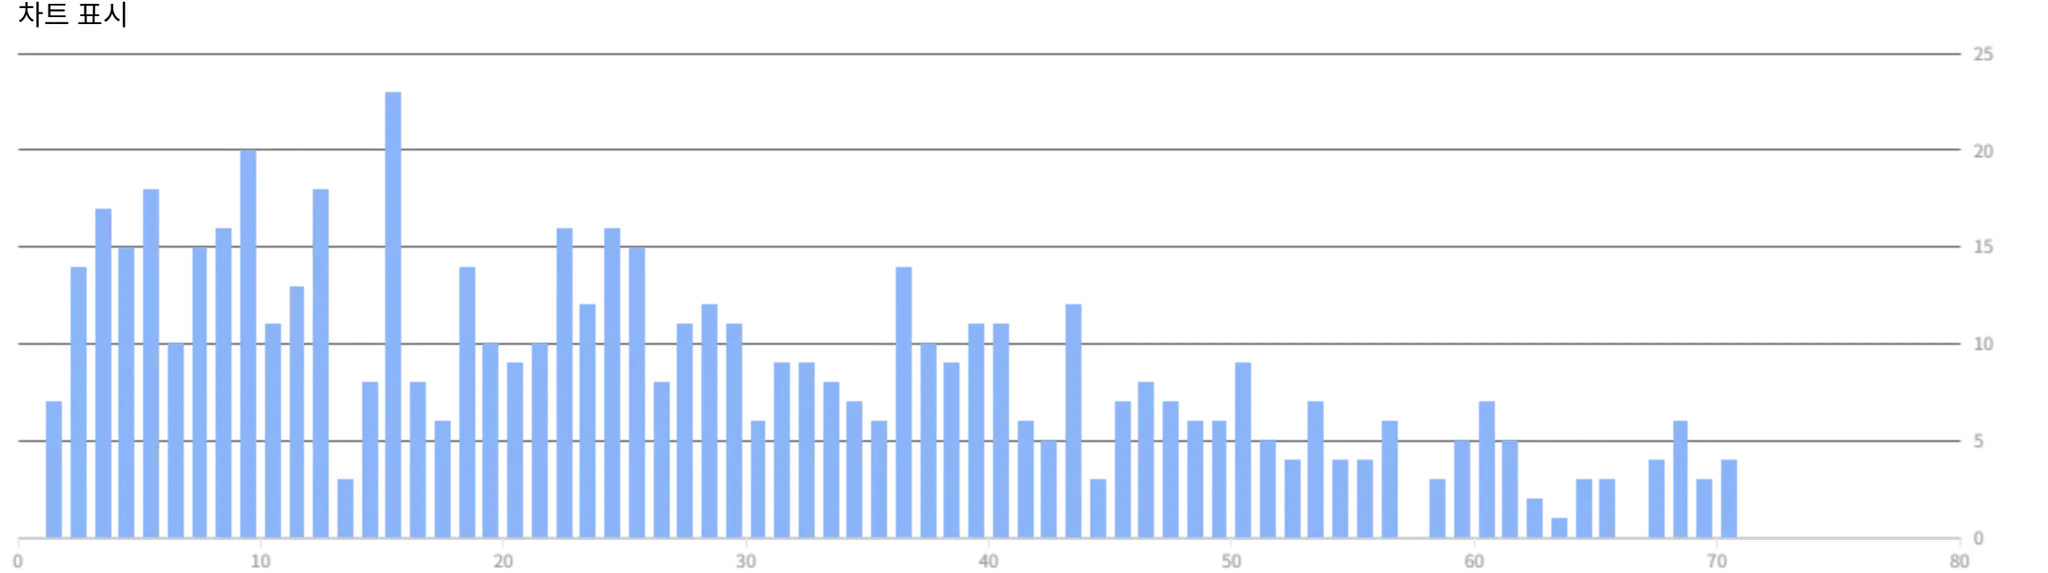

#### 크리스마스

##### 공통 쿼리

``` sql
WITH holiday_user AS (
  SELECT
    DISTINCT
      user_pseudo_id,
      event_date
  FROM foodie.holiday_user_logs
  WHERE event_date = '2022-12-25'
), past_logs AS (
  SELECT *
  FROM foodie.activate_user_logs
  WHERE event_date < '2022-12-25'
), past_user AS (
  SELECT
     DISTINCT
      user_pseudo_id,
      event_date
  FROM past_logs
  WHERE user_pseudo_id IN (SELECT user_pseudo_id FROM holiday_user)
)
```

##### 크리스마스에 접속한 사용자 파악
→ 크리스마스 접속 사용자: 858명

``` sql
SELECT
  DISTINCT user_pseudo_id
FROM holiday_user;
```

##### 크리스마스 이전 접속 사용자 파악
→ 크리스마스 접속 사용자 중 크리스마스 이전 접속 사용자: 660명

→ 이전 접속 사용자 비율: 77%

``` sql
SELECT
  DISTINCT user_pseudo_id
FROM past_user;
```

##### 이전 접속한 기록이 있는 사용자들 중 크리스마스에 결제한 사용자 파악
→ 269명

→ 이전 접속 사용자 중 결제한 사용자 비율: 41%

``` sql
SELECT
  DISTINCT user_pseudo_id
FROM foodie.holiday_user_logs
WHERE user_pseudo_id IN (SELECT DISTINCT user_pseudo_id FROM past_user)
  AND event_name = 'click_payment';
  ```

##### 이전 접속 중 결제까지 한 사용자 파악
→ 128명

→ 이전 접속 사용자 중 결제한 사용자 비율: 19%

``` sql
SELECT
  DISTINCT user_pseudo_id
FROM past_logs
WHERE event_name = 'click_payment'
  AND user_pseudo_id IN (SELECT DISTINCT user_pseudo_id FROM holiday_user);
  ```

##### 이전 접속이 다른 공휴일이었던 사용자 파악
→ 56명

``` sql
SELECT
  DISTINCT user_pseudo_id
FROM past_user
WHERE event_date IN ('2022-08-15', '2022-09-09', '2022-09-10', '2022-09-11', '2022-09-12', '2022-10-03', '2022-10-09', '2022-10-10');
```

##### 이전 접속이 다른 공휴일이었던 사용자 중 결제까지 한 사용자 파악
→ 28명

``` sql
SELECT
  DISTINCT user_pseudo_id
FROM past_logs
WHERE user_pseudo_id IN (SELECT user_pseudo_id FROM holiday_user)
  AND event_date IN ('2022-08-15', '2022-09-09', '2022-09-10', '2022-09-11', '2022-09-12', '2022-10-03', '2022-10-09', '2022-10-10')
  AND event_name = 'click_payment';
  ```

##### 크리스마스 이전 접속 이후 연휴에 몇일만에 재접속했는지 파악

``` sql
SELECT
  diff_of_date,
  COUNT(*) AS `cnt`
FROM (
  SELECT
    n.user_pseudo_id,
    n.event_date AS `not_holiday_date`,
    h.event_date AS `holiday_date`,
    DATE_DIFF(h.event_date, n.event_date, DAY) AS `diff_of_date`
  FROM past_user AS n INNER JOIN holiday_user AS h ON n.user_pseudo_id = h.user_pseudo_id
  )
GROUP BY diff_of_date
ORDER BY diff_of_date;
```

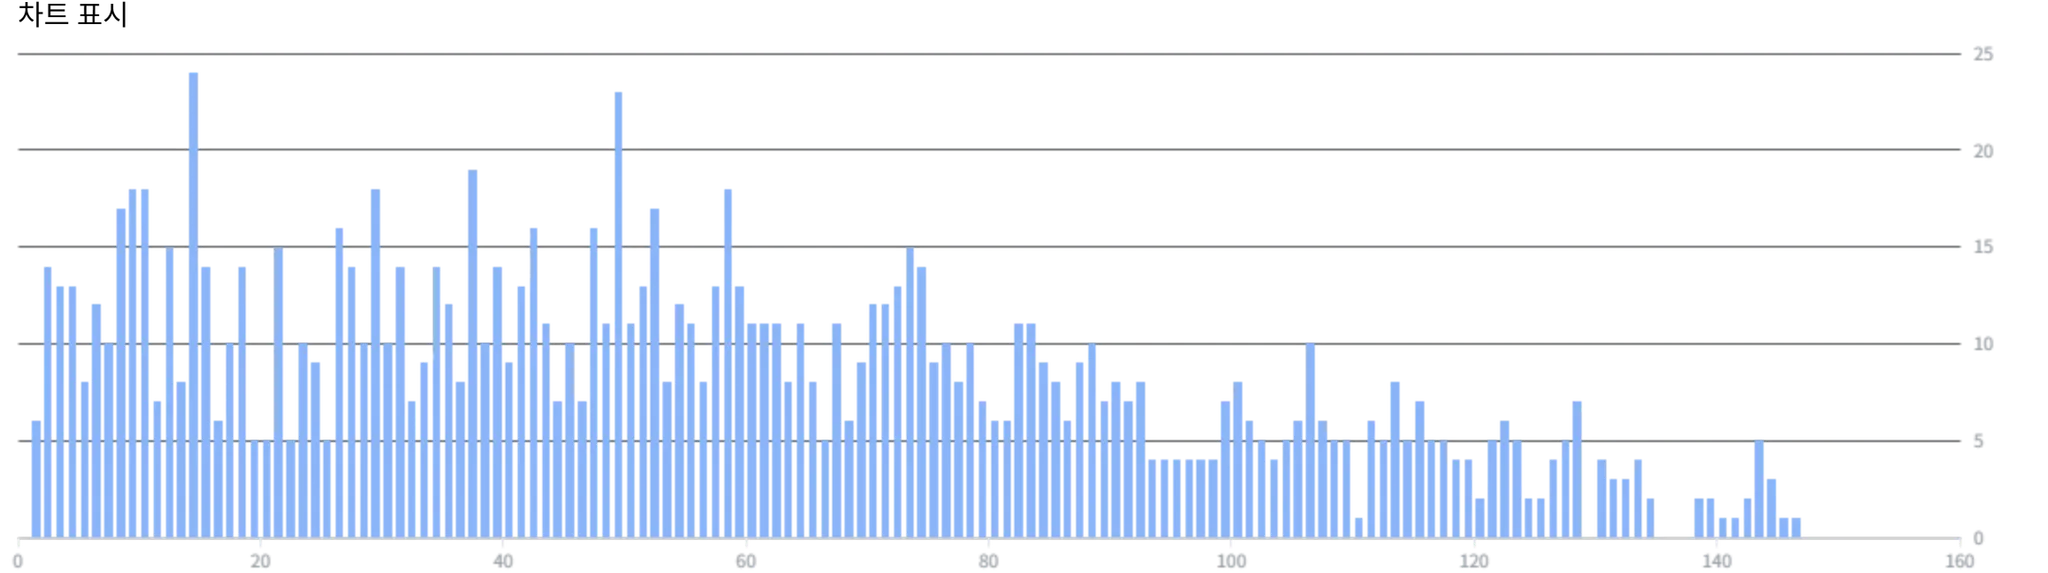

#### 신정

##### 공통 쿼리

``` sql
WITH holiday_user AS (
  SELECT
    DISTINCT
      user_pseudo_id,
      event_date
  FROM foodie.holiday_user_logs
  WHERE event_date = '2023-01-01'
), past_logs AS (
  SELECT *
  FROM foodie.activate_user_logs
  WHERE event_date < '2023-01-01'
), past_user AS (
  SELECT
     DISTINCT
      user_pseudo_id,
      event_date
  FROM past_logs
  WHERE user_pseudo_id IN (SELECT user_pseudo_id FROM holiday_user)
)
```

##### 신정에 접속한 사용자 파악
→ 신정 접속 사용자: 831명

``` sql
SELECT
  DISTINCT user_pseudo_id
FROM holiday_user;
```

##### 신정 이전 접속 사용자 파악
→ 신정 접속 사용자 중 신정 이전 접속 사용자: 634명

→ 이전 접속 사용자 비율: 76%

``` sql
SELECT
  DISTINCT user_pseudo_id
FROM past_user;
```

##### 이전 접속한 기록이 있는 사용자들 중 신정에 결제한 사용자 파악
→ 258명

→ 이전 접속 사용자 중 결제한 사용자 비율: 41%

``` sql
SELECT
  DISTINCT user_pseudo_id
FROM foodie.holiday_user_logs
WHERE user_pseudo_id IN (SELECT DISTINCT user_pseudo_id FROM past_user)
  AND event_name = 'click_payment';
  ```

##### 이전 접속 중 결제까지 한 사용자 파악
→ 140명

→ 이전 접속 사용자 중 결제한 사용자 비율: 22%

``` sql
SELECT
  DISTINCT user_pseudo_id
FROM past_logs
WHERE event_name = 'click_payment'
  AND user_pseudo_id IN (SELECT DISTINCT user_pseudo_id FROM holiday_user);
  ```

##### 이전 접속이 다른 공휴일이었던 사용자 파악
→ 61명

``` sql
SELECT
  DISTINCT user_pseudo_id
FROM past_user
WHERE event_date IN ('2022-08-15', '2022-09-09', '2022-09-10', '2022-09-11', '2022-09-12', '2022-10-03', '2022-10-09', '2022-10-10', '2022-12-25');
```

##### 이전 접속이 다른 공휴일이었던 사용자 중 결제까지 한 사용자 파악
→ 29명

``` sql
SELECT
  DISTINCT user_pseudo_id
FROM past_logs
WHERE user_pseudo_id IN (SELECT user_pseudo_id FROM holiday_user)
  AND event_date IN ('2022-08-15', '2022-09-09', '2022-09-10', '2022-09-11', '2022-09-12', '2022-10-03', '2022-10-09', '2022-10-10', '2022-12-25')
  AND event_name = 'click_payment';
  ```

##### 신정 이전 접속 이후 연휴에 몇일만에 재접속했는지 파악

``` sql
SELECT
  diff_of_date,
  COUNT(*) AS `cnt`
FROM (
  SELECT
    n.user_pseudo_id,
    n.event_date AS `not_holiday_date`,
    h.event_date AS `holiday_date`,
    DATE_DIFF(h.event_date, n.event_date, DAY) AS `diff_of_date`
  FROM past_user AS n INNER JOIN holiday_user AS h ON n.user_pseudo_id = h.user_pseudo_id
  )
GROUP BY diff_of_date
ORDER BY diff_of_date;
```

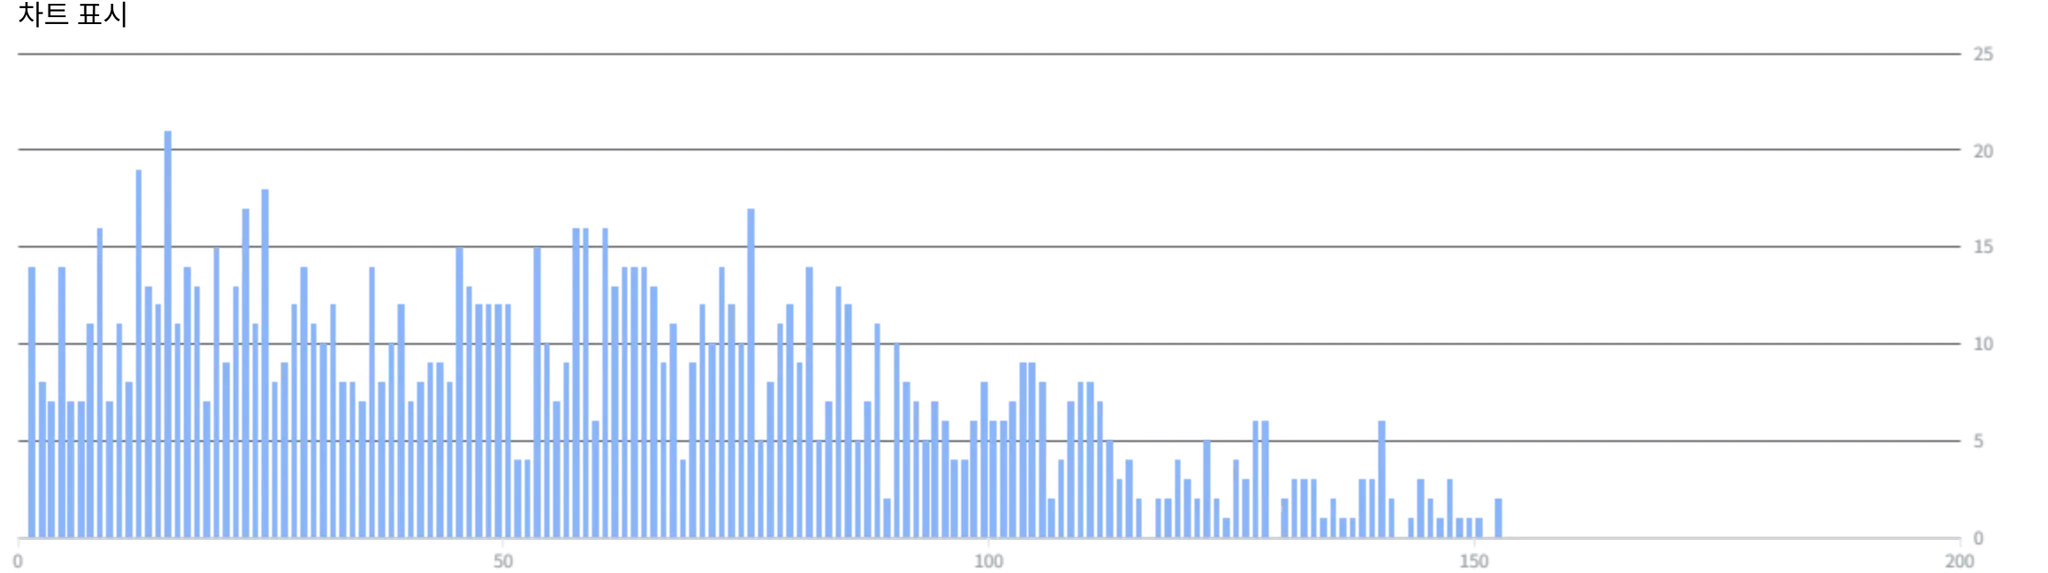

### 3.3 공휴일에 접속하는 사용자들은 앱 사용에 더 강한 의지를 가지고 들어와 체류 시간이 더 길 것이다.
→ 시간대별 큰 차이는 없고 공휴일에 접속한 사용자들이 월등히 오래 머물렀다.

#### 공휴일

→ 전체 시간대 체류 시간 평균: 70초

→ 이른 아침: 약 71초

→ 아침: 약 72초

→ 늦은 아침: 약 71초

→ 점심: 약 69초

→ 애프터눈 티: 약 70초

→ 저녁: 약 70초

→ 야식: 약 69초

→ 늦은 야식: 약 70초

``` sql
WITH base AS (
SELECT
  *,
  EXTRACT(HOUR FROM session_start) AS `session_start_hour`,
  DATETIME_DIFF(session_end, session_start, SECOND) AS `stay_time_second`
FROM (  
  SELECT
    DISTINCT
      user_pseudo_id,
      session_id,
      MIN(event_datetime) OVER (PARTITION BY user_pseudo_id, session_id) AS `session_start`,
      MAX(event_datetime) OVER (PARTITION BY user_pseudo_id, session_id) AS `session_end`
  FROM foodie.holiday_user_logs
  )
), set_session_start_meal_time AS (
  SELECT
    user_pseudo_id,
    session_id,
    session_start,
    session_end,
    CASE
      WHEN session_start_hour IN (0, 1, 2, 3) THEN '늦은 야식'
      WHEN session_start_hour IN (4, 5, 6) THEN '이른 아침'
      WHEN session_start_hour IN (7, 8, 9) THEN '아침'
      WHEN session_start_hour IN (10, 11) THEN '늦은 아침'
      WHEN session_start_hour IN (12, 13, 14) THEN '점심'
      WHEN session_start_hour IN (15, 16) THEN '애프터눈 티'
      WHEN session_start_hour IN (17, 18, 19, 20) THEN '저녁'
      WHEN session_start_hour IN (21, 22, 23) THEN  '야식'
    END AS session_start_meal_time,
    stay_time_second
  FROM base
)

-- 전체 시간대 체류 시간 평균 구하기
-- SELECT
--   AVG(stay_time_second) AS `avg_stay_time_second`
-- FROM base;

-- 특정 시간대 체류 시간 평균 구하기
SELECT
  session_start_meal_time,
  AVG(stay_time_second) AS `avg_stay_time_second`
FROM set_session_start_meal_time
GROUP BY session_start_meal_time;
```

#### 평일

→ 전체 시간대 체류 시간 평균: 40초

→ 이른 아침: 약 42초

→ 아침: 약 41초

→ 늦은 아침: 약 40초

→ 점심: 약 41초

→ 애프터눈 티: 약 40초

→ 저녁: 약 40초

→ 야식: 약 40초

→ 늦은 야식: 약 40초

``` sql
WITH base AS (
SELECT
  *,
  EXTRACT(HOUR FROM session_start) AS `session_start_hour`,
  DATETIME_DIFF(session_end, session_start, SECOND) AS `stay_time_second`
FROM (  
  SELECT
    DISTINCT
      user_pseudo_id,
      session_id,
      MIN(event_datetime) OVER (PARTITION BY user_pseudo_id, session_id) AS `session_start`,
      MAX(event_datetime) OVER (PARTITION BY user_pseudo_id, session_id) AS `session_end`
  FROM foodie.weekdays_user_logs
  )
), set_session_start_meal_time AS (
  SELECT
    user_pseudo_id,
    session_id,
    session_start,
    session_end,
    CASE
      WHEN session_start_hour IN (0, 1, 2, 3) THEN '늦은 야식'
      WHEN session_start_hour IN (4, 5, 6) THEN '이른 아침'
      WHEN session_start_hour IN (7, 8, 9) THEN '아침'
      WHEN session_start_hour IN (10, 11) THEN '늦은 아침'
      WHEN session_start_hour IN (12, 13, 14) THEN '점심'
      WHEN session_start_hour IN (15, 16) THEN '애프터눈 티'
      WHEN session_start_hour IN (17, 18, 19, 20) THEN '저녁'
      WHEN session_start_hour IN (21, 22, 23) THEN  '야식'
    END AS session_start_meal_time,
    stay_time_second
  FROM base
)

-- 전체 시간대 체류 시간 평균 구하기
SELECT
  AVG(stay_time_second) AS `avg_stay_time_second`
FROM base;

-- 특정 시간대 체류 시간 평균 구하기
-- SELECT
--   session_start_meal_time,
--   AVG(stay_time_second) AS `avg_stay_time_second`
-- FROM set_session_start_meal_time
-- GROUP BY session_start_meal_time;
```

#### 주말

→ 전체 시간대 체류 시간 평균: 41초

→ 이른 아침: 약 40초

→ 아침: 약 40초

→ 늦은 아침: 약 42초

→ 점심: 약 40초

→ 애프터눈 티: 약 40초

→ 저녁: 약 41초

→ 야식: 약 41초

→ 늦은 야식: 약 40초

``` sql
WITH base AS (
SELECT
  *,
  EXTRACT(HOUR FROM session_start) AS `session_start_hour`,
  DATETIME_DIFF(session_end, session_start, SECOND) AS `stay_time_second`
FROM (  
  SELECT
    DISTINCT
      user_pseudo_id,
      session_id,
      MIN(event_datetime) OVER (PARTITION BY user_pseudo_id, session_id) AS `session_start`,
      MAX(event_datetime) OVER (PARTITION BY user_pseudo_id, session_id) AS `session_end`
  FROM foodie.weekend_user_logs
  )
), set_session_start_meal_time AS (
  SELECT
    user_pseudo_id,
    session_id,
    session_start,
    session_end,
    CASE
      WHEN session_start_hour IN (0, 1, 2, 3) THEN '늦은 야식'
      WHEN session_start_hour IN (4, 5, 6) THEN '이른 아침'
      WHEN session_start_hour IN (7, 8, 9) THEN '아침'
      WHEN session_start_hour IN (10, 11) THEN '늦은 아침'
      WHEN session_start_hour IN (12, 13, 14) THEN '점심'
      WHEN session_start_hour IN (15, 16) THEN '애프터눈 티'
      WHEN session_start_hour IN (17, 18, 19, 20) THEN '저녁'
      WHEN session_start_hour IN (21, 22, 23) THEN  '야식'
    END AS session_start_meal_time,
    stay_time_second
  FROM base
)

-- 전체 시간대 체류 시간 평균 구하기
-- SELECT
--   AVG(stay_time_second) AS `avg_stay_time_second`
-- FROM base;

-- 특정 시간대 체류 시간 평균 구하기
SELECT
  session_start_meal_time,
  AVG(stay_time_second) AS `avg_stay_time_second`
FROM set_session_start_meal_time
GROUP BY session_start_meal_time;
```

### 3.4 공휴일에 접속하는 사용자들은 앱 사용에 더 강한 의지를 가지고 들어와 결제율이 더 높을 것이다.

#### 공휴일

→ 총 세션 수: 5,785건

→ 결제까지 한 세션: 2,230건

→ 결제율: 약 39%

``` sql
SELECT
  DISTINCT
    user_pseudo_id,
    session_id
FROM foodie.holiday_user_logs
WHERE event_name = 'click_payment';
```

#### 평일

→ 총 세션 수: 71,006건

→ 결제까지 한 세션: 7,761건

→ 결제율: 약 11%

``` sql
SELECT
  DISTINCT
    user_pseudo_id,
    session_id
FROM foodie.weekdays_user_logs
WHERE event_name = 'click_payment';
```

---

→ 공휴일에 결제 이력이 있는 세션 수: 2,592건

→ 결제까지 한 세션: 305건

→ 결제율: 약 18%

``` sql
WITH holiday_payment_user AS (
  SELECT
    DISTINCT
      user_pseudo_id
  FROM foodie.holiday_user_logs
  WHERE event_name = 'click_payment'
)

SELECT
  DISTINCT
    user_pseudo_id,
    session_id
FROM foodie.weekdays_user_logs
WHERE user_pseudo_id IN (SELECT * FROM holiday_payment_user)
  AND event_name = 'click_payment';
  ```

---

→ 공휴일에 결제 이력이 없는 세션 수: 68,414건

→ 결제까지 한 세션: 7,456건

→ 결제율: 약 11%

``` sql
WITH holiday_payment_user AS (
  SELECT
    DISTINCT
      user_pseudo_id
  FROM foodie.holiday_user_logs
  WHERE event_name = 'click_payment'
)

SELECT
  DISTINCT
    user_pseudo_id,
    session_id
FROM foodie.weekdays_user_logs
WHERE user_pseudo_id NOT IN (SELECT * FROM holiday_payment_user)
  AND event_name = 'click_payment';
  ```

#### 주말

→ 총 세션 수: 28,289건

→ 결제까지 한 세션: 3,168건

→ 결제율: 약 11%

``` sql
SELECT
  DISTINCT
    user_pseudo_id,
    session_id
FROM foodie.weekend_user_logs
WHERE event_name = 'click_payment';
```

---

→ 공휴일에 결제 이력이 있는 세션 수: 1,097건

→ 결제까지 한 세션: 121건

→ 결제율: 약 11%

``` sql
WITH holiday_payment_user AS (
  SELECT
    DISTINCT
      user_pseudo_id
  FROM foodie.holiday_user_logs
  WHERE event_name = 'click_payment'
)

SELECT
  DISTINCT
    user_pseudo_id,
    session_id
FROM foodie.weekend_user_logs
WHERE user_pseudo_id IN (SELECT * FROM holiday_payment_user)
  AND event_name = 'click_payment';
  ```

---

→ 공휴일에 결제 이력이 없는 세션 수: 27,192건

→ 결제까지 한 세션: 3,047건

→ 결제율: 약 11%

``` sql
WITH holiday_payment_user AS (
  SELECT
    DISTINCT
      user_pseudo_id
  FROM foodie.holiday_user_logs
  WHERE event_name = 'click_payment'
)

SELECT
  DISTINCT
    user_pseudo_id,
    session_id
FROM foodie.weekend_user_logs
WHERE user_pseudo_id NOT IN (SELECT * FROM holiday_payment_user)
  AND event_name = 'click_payment';
  ```

### 3.5 공휴일에 접속했던 사용자들의 재방문률(리텐션)이 더 높을 것이다.
→ 공휴일이라고 리텐션이 높지는 않다 전체적으로 리텐션이 매우 낮음

#### 공휴일

→ N-Day

``` sql
WITH base AS (
  SELECT
    DISTINCT
      user_pseudo_id,
      event_date
  FROM foodie.holiday_user_logs
), cal_diff_of_event_date AS (
  SELECT
    user_pseudo_id,
    event_date,
    DATE_DIFF(event_date ,first_event_date, DAY) AS `diff_of_event_date`
  FROM (
    SELECT
      *,
      MIN(event_date) OVER (PARTITION BY user_pseudo_id) AS `first_event_date`
    FROM base
  )
), retention_day_cnt AS (
  SELECT
    diff_of_event_date,
    COUNT(diff_of_event_date) AS `retention_cnt`,
    FIRST_VALUE(COUNT(diff_of_event_date)) OVER (ORDER BY diff_of_event_date) AS `first_retentio_cnt`
  FROM cal_diff_of_event_date
  GROUP BY diff_of_event_date
)

SELECT
  *,
  ROUND(SAFE_DIVIDE(retention_cnt, first_retentio_cnt), 3) AS `retention_ratio`
FROM retention_day_cnt
ORDER BY diff_of_event_date;
```

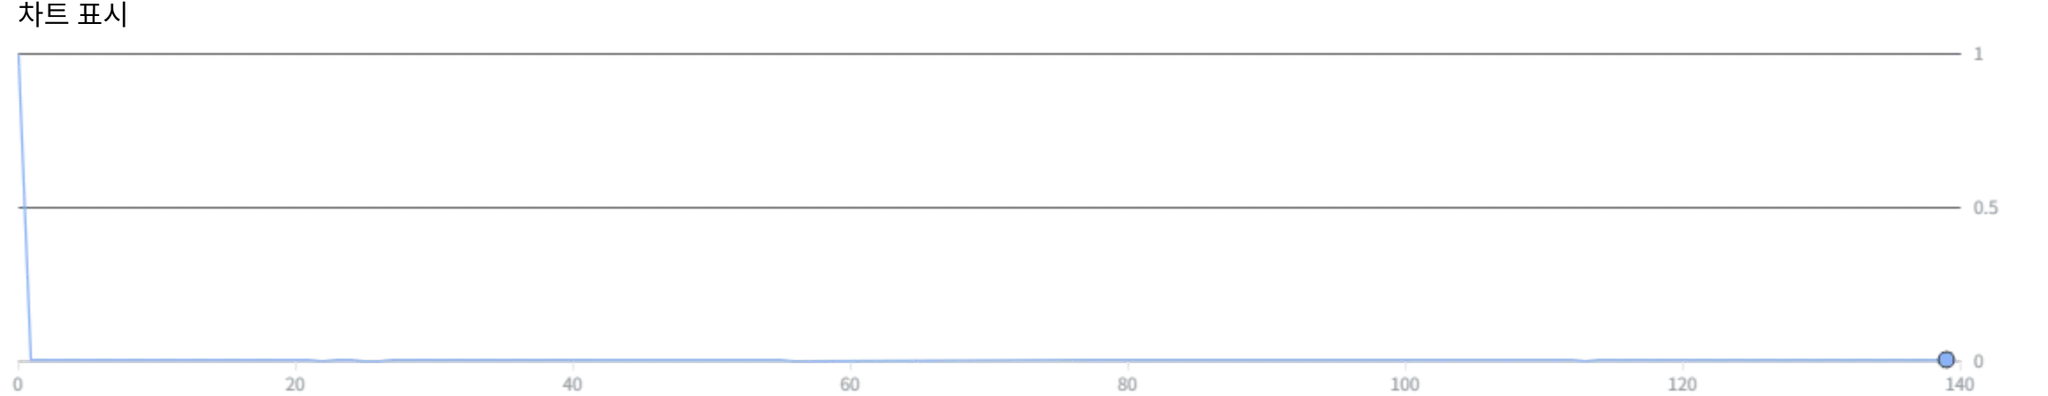

---

→ Weekly

``` sql
WITH base AS (
  SELECT
    DISTINCT
      user_pseudo_id,
      DATE_TRUNC(event_date, WEEK(MONDAY)) AS `event_week`
  FROM foodie.holiday_user_logs
), cal_diff_of_event_week AS (
  SELECT
    user_pseudo_id,
    event_week,
    DATE_DIFF(event_week ,first_event_week, WEEK) AS `diff_of_event_week`
  FROM (
    SELECT
      *,
      MIN(event_week) OVER (PARTITION BY user_pseudo_id) AS `first_event_week`
    FROM base
  )
), retention_week_cnt AS (
  SELECT
    diff_of_event_week,
    COUNT(diff_of_event_week) AS `retention_cnt`,
    FIRST_VALUE(COUNT(diff_of_event_week)) OVER (ORDER BY diff_of_event_week) AS `first_retentio_cnt`
  FROM cal_diff_of_event_week
  GROUP BY diff_of_event_week
)

SELECT
  *,
  ROUND(SAFE_DIVIDE(retention_cnt, first_retentio_cnt), 3) AS `retention_ratio`
FROM retention_week_cnt
ORDER BY diff_of_event_week;
```

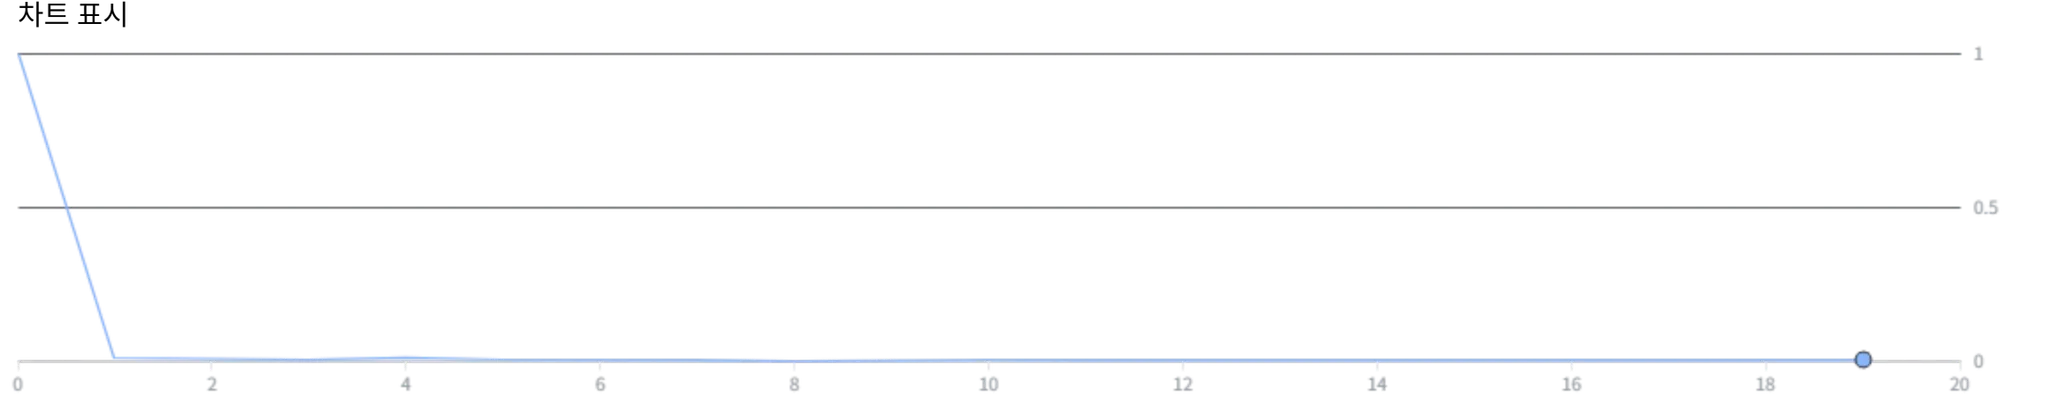

#### 평일

→ N-Day

``` sql
WITH base AS (
  SELECT
    DISTINCT
      user_pseudo_id,
      event_date
  FROM foodie.weekdays_user_logs
), cal_diff_of_event_date AS (
  SELECT
    user_pseudo_id,
    event_date,
    DATE_DIFF(event_date ,first_event_date, DAY) AS `diff_of_event_date`
  FROM (
    SELECT
      *,
      MIN(event_date) OVER (PARTITION BY user_pseudo_id) AS `first_event_date`
    FROM base
  )
), retention_day_cnt AS (
  SELECT
    diff_of_event_date,
    COUNT(diff_of_event_date) AS `retention_cnt`,
    FIRST_VALUE(COUNT(diff_of_event_date)) OVER (ORDER BY diff_of_event_date) AS `first_retentio_cnt`
  FROM cal_diff_of_event_date
  GROUP BY diff_of_event_date
)

SELECT
  *,
  ROUND(SAFE_DIVIDE(retention_cnt, first_retentio_cnt), 3) AS `retention_ratio`
FROM retention_day_cnt
ORDER BY diff_of_event_date;
```

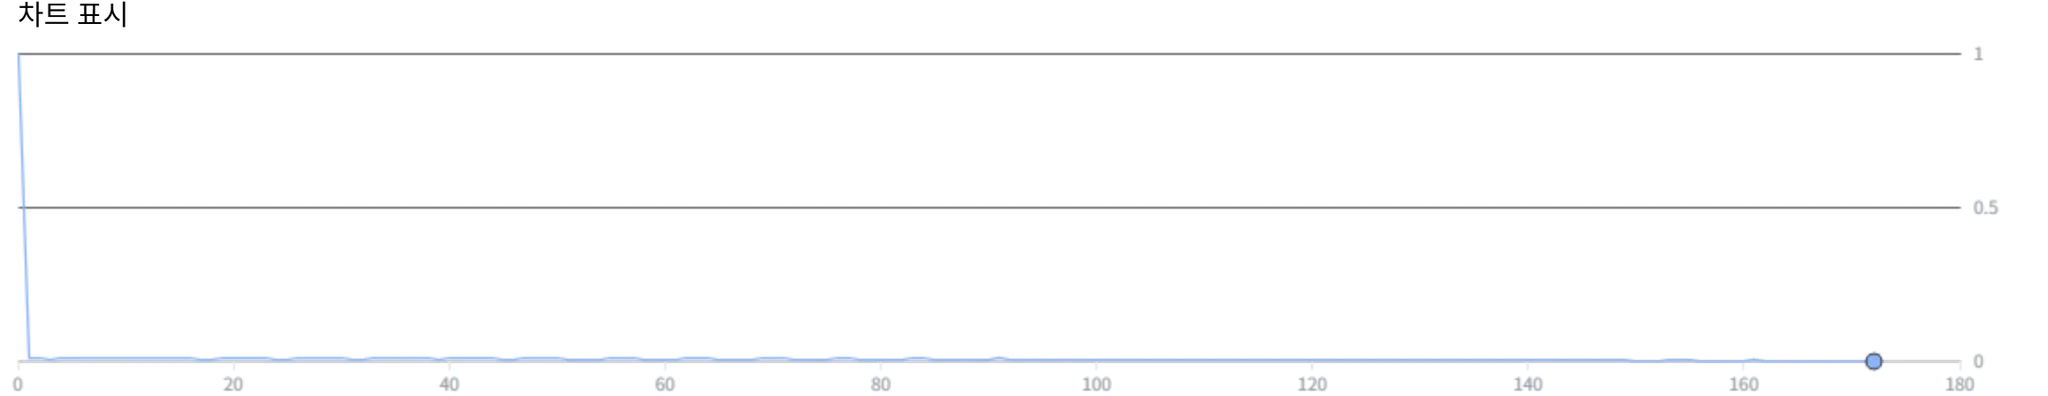

---

→ Weekly

``` sql
WITH base AS (
  SELECT
    DISTINCT
      user_pseudo_id,
      DATE_TRUNC(event_date, WEEK(MONDAY)) AS `event_week`
  FROM foodie.weekdays_user_logs
), cal_diff_of_event_week AS (
  SELECT
    user_pseudo_id,
    event_week,
    DATE_DIFF(event_week ,first_event_week, WEEK) AS `diff_of_event_week`
  FROM (
    SELECT
      *,
      MIN(event_week) OVER (PARTITION BY user_pseudo_id) AS `first_event_week`
    FROM base
  )
), retention_week_cnt AS (
  SELECT
    diff_of_event_week,
    COUNT(diff_of_event_week) AS `retention_cnt`,
    FIRST_VALUE(COUNT(diff_of_event_week)) OVER (ORDER BY diff_of_event_week) AS `first_retentio_cnt`
  FROM cal_diff_of_event_week
  GROUP BY diff_of_event_week
)

SELECT
  *,
  ROUND(SAFE_DIVIDE(retention_cnt, first_retentio_cnt), 3) AS `retention_ratio`
FROM retention_week_cnt
ORDER BY diff_of_event_week;
```

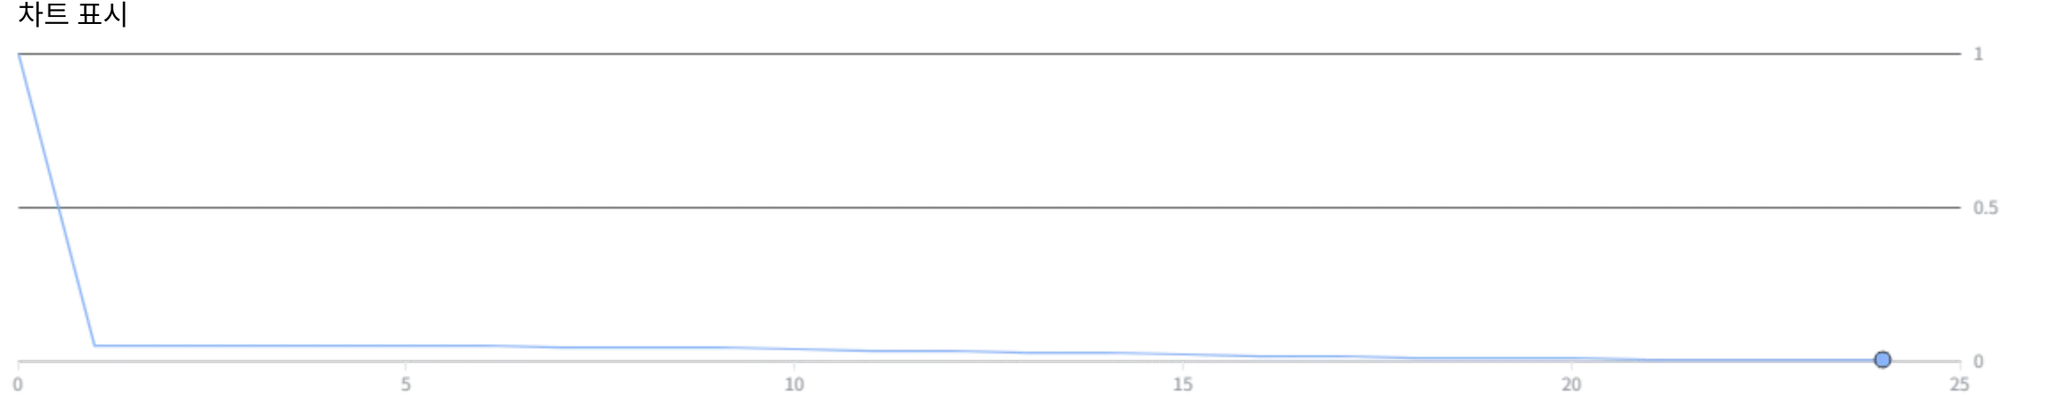

#### 주말

→ N-Day

``` sql
WITH base AS (
  SELECT
    DISTINCT
      user_pseudo_id,
      event_date
  FROM foodie.weekend_user_logs
), cal_diff_of_event_date AS (
  SELECT
    user_pseudo_id,
    event_date,
    DATE_DIFF(event_date ,first_event_date, DAY) AS `diff_of_event_date`
  FROM (
    SELECT
      *,
      MIN(event_date) OVER (PARTITION BY user_pseudo_id) AS `first_event_date`
    FROM base
  )
), retention_day_cnt AS (
  SELECT
    diff_of_event_date,
    COUNT(diff_of_event_date) AS `retention_cnt`,
    FIRST_VALUE(COUNT(diff_of_event_date)) OVER (ORDER BY diff_of_event_date) AS `first_retentio_cnt`
  FROM cal_diff_of_event_date
  GROUP BY diff_of_event_date
)

SELECT
  *,
  ROUND(SAFE_DIVIDE(retention_cnt, first_retentio_cnt), 3) AS `retention_ratio`
FROM retention_day_cnt
ORDER BY diff_of_event_date;
```

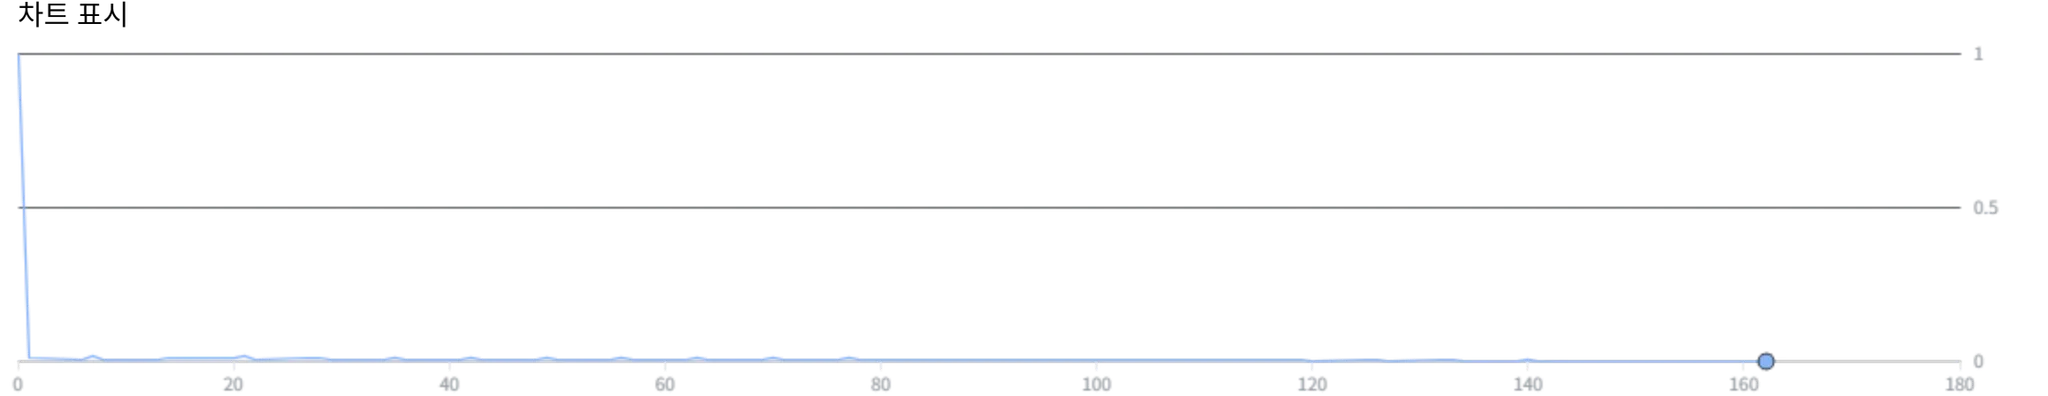

---

→ Weekly

``` sql
WITH base AS (
  SELECT
    DISTINCT
      user_pseudo_id,
      DATE_TRUNC(event_date, WEEK(MONDAY)) AS `event_week`
  FROM foodie.weekend_user_logs
), cal_diff_of_event_week AS (
  SELECT
    user_pseudo_id,
    event_week,
    DATE_DIFF(event_week ,first_event_week, WEEK) AS `diff_of_event_week`
  FROM (
    SELECT
      *,
      MIN(event_week) OVER (PARTITION BY user_pseudo_id) AS `first_event_week`
    FROM base
  )
), retention_week_cnt AS (
  SELECT
    diff_of_event_week,
    COUNT(diff_of_event_week) AS `retention_cnt`,
    FIRST_VALUE(COUNT(diff_of_event_week)) OVER (ORDER BY diff_of_event_week) AS `first_retentio_cnt`
  FROM cal_diff_of_event_week
  GROUP BY diff_of_event_week
)

SELECT
  *,
  ROUND(SAFE_DIVIDE(retention_cnt, first_retentio_cnt), 3) AS `retention_ratio`
FROM retention_week_cnt
ORDER BY diff_of_event_week;
```

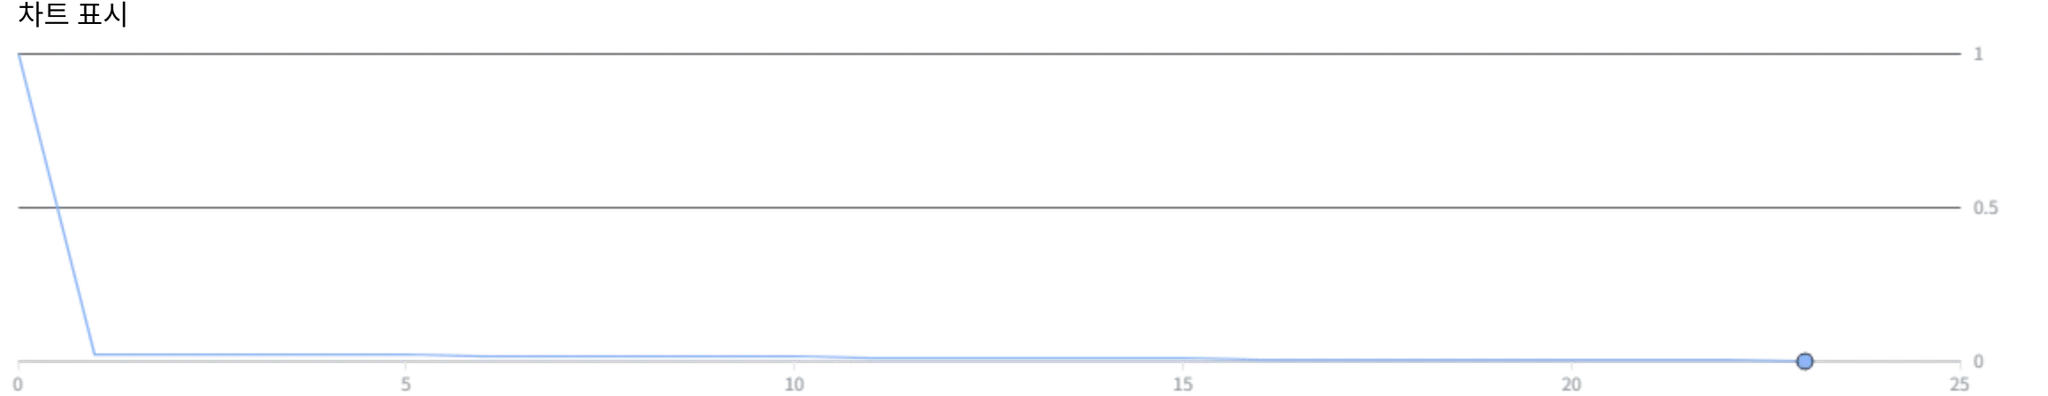

## 4. 목표 설정
> 공휴일 트래픽을 활용한 리텐션 제고 전략
>
>>가설 검정 결과 공휴일 접속 사용자들은 갈수록 재방문하는 비율이 증가하는 추세다. 이들은 평일이나 주말에 비해 평균 체류 시간이 더 길게 나타나며 관심 있게 앱을 탐색한다. 또한 결제 전환율 역시 평일이나 주말에 비해 높은 비율을 보인다. 그러나 전환율이 높음에도 불구, 정작 공휴일 접속 사용자들의 재방문율은 매우 낮은 편이다. 만약 공휴일에 접속 사용자들이 앱 사용 중 만족감을 느끼고 주기적으로 접속하며 다른 사용자에게 추천까지 한다면, 이는 신규 사용자 유입에도 긍정적 영향을 미칠 것이다. 그래서 최우선 목표를 공휴일 접속 사용자들의 만족감을 높이고 지속적인 방문으로 두었으며, 모든 영역을 손보는 대신 공휴일에 급증하는 방문자를 파일럿으로 삼아 이들의 특징을 파악, 이를 바탕으로 만족도를 높이며 재방문율을 끌어올릴 수 있는 방안을 제안하고자 한다.

## 5. 집중 분석
→ 공휴일 접속 활성 사용자들의 전환 퍼널을 파악해보고 전환률이 높은 퍼널 바탕으로 이를 강화하는 인사이트 제공 혹은, 전환률이 낮은 퍼널 바탕으로 보완하는 인사이트 제공

### 5-1. 공휴일 접속 사용자들의 퍼널 분석

→ 공휴일에 접속한 사용자들은 80%가 홈 화면에 위치한 음식 카테고리 기능을 주로 사용한다. 이 중 40%(카테고리 결제 퍼널 진입: 4611건 → 결제완료: 1860건)가 결제까지 이어졌다. 다른 기능을 사용하는 비중이 매우 적은 것을 미루어보아 다른 기능에서 조금씩 사용자들의 선호도를 분석하여 카테고리 기능 보완하는 방향으로 인사이트를 내고자 한다.

→ 각 단계에서 전환율이 크게 떨어지는 부분이 발견되지 않아 모든 단계의 전환율을 올리기 위한 각각의 단계별 맞춤 전략을 제시해보고자 한다.

---

#### 카테고리를 통한 결제 퍼널

``` sql
WITH base AS (
  SELECT
    event_date,
    event_datetime,
    event_name,
    user_pseudo_id,
    session_id,
    platform,
    MAX(IF(event_param.key = "firebase_screen", event_param.value.string_value, NULL)) AS firebase_screen,
  FROM foodie.holiday_user_logs, UNNEST(event_params) AS event_param
  GROUP BY ALL
), set_event_name_with_screen AS (
  SELECT
    user_pseudo_id,
    session_id,
    event_datetime,
    event_name,
    firebase_screen,
    platform,
    CONCAT(event_name, '-', firebase_screen)AS event_name_with_screen,
  FROM base
), select_food_category_funnel AS (
  SELECT
    user_pseudo_id,
    session_id,
    event_datetime,
    event_name_with_screen,
    platform,
    MAX(check_num) OVER (PARTITION BY user_pseudo_id, session_id) AS `check_category_funnel`
  FROM (SELECT
      *,
      IF(event_name_with_screen = 'screen_view-food_category', 1, null) AS `check_num`
    FROM set_event_name_with_screen)
  QUALIFY check_category_funnel IS NOT NULL
), set_funnel_step AS (
  SELECT
    * EXCEPT(check_category_funnel, platform),
    CASE
      WHEN event_name_with_screen = 'screen_view-food_category' THEN 3
      WHEN event_name_with_screen = 'screen_view-restaurant' THEN 4
      WHEN event_name_with_screen = 'screen_view-food_detail' THEN 5
      WHEN event_name_with_screen = 'screen_view-cart' THEN 6
      WHEN event_name_with_screen = 'click_payment-cart' THEN 7
      ELSE NULL
    END AS step
  FROM select_food_category_funnel
), set_category_funnel AS (
  SELECT
    event_name_with_screen,
    CASE 
      WHEN event_name_with_screen = 'screen_view-welcome' THEN 1
      WHEN event_name_with_screen = 'screen_view-home' THEN 2
    END AS step,
    COUNT(*) AS funnel_cnt
  FROM (
    SELECT
      # 다른 화면을 보다가 screen_view-home으로 돌아가는 경우 존재
      DISTINCT
        user_pseudo_id,
        session_id,
        event_name_with_screen
    FROM set_event_name_with_screen
    WHERE event_name_with_screen IN ('screen_view-welcome', 'screen_view-home')
  )
  GROUP BY event_name_with_screen
  UNION ALL
  SELECT
    event_name_with_screen,
    step,
    COUNT(*) AS `funnel_cnt`
  FROM set_funnel_step
  WHERE step IS NOT NULL
  GROUP BY event_name_with_screen, step
)
```

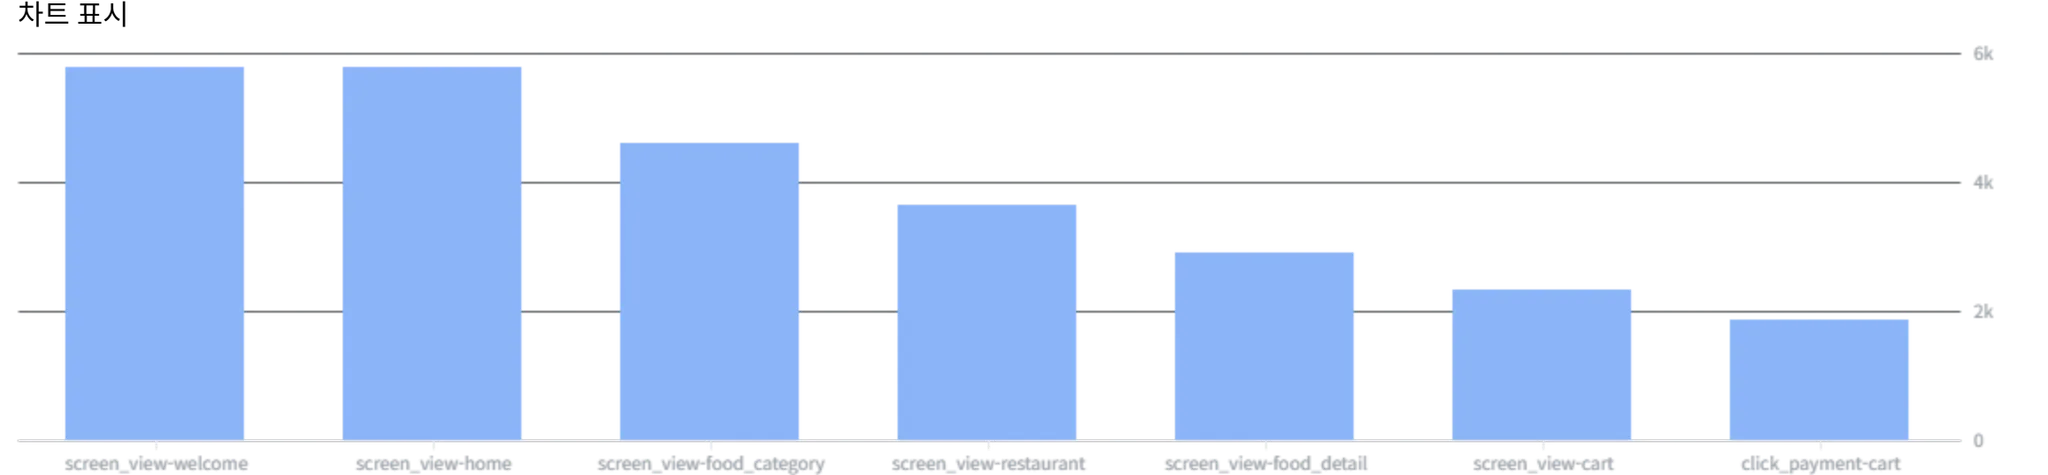

---

→ 단계별 전환율

``` sql
SELECT
  *,
  CONCAT(ROUND(SAFE_DIVIDE(funnel_cnt, pre_funnel_cnt), 2) * 100, '%') AS `funnel_step_bounce_rate`
FROM (
  SELECT
  *,
  LAG(funnel_cnt) OVER (ORDER BY step) AS `pre_funnel_cnt`
FROM set_category_funnel)
ORDER BY step;
```

| event\_name\_with\_screen   | step | funnel\_cnt | pre\_funnel\_cnt | funnel\_step\_bounce\_rate |
| --------------------------- | ---: | ----------: | ---------------: | -------------------------: |
| screen\_view-welcome        |    1 |        5785 |                  |                            |
| screen\_view-home           |    2 |        5785 |             5785 |                       100% |
| screen\_view-food\_category |    3 |        4611 |             5785 |                        80% |
| screen\_view-restaurant     |    4 |        3646 |             4611 |                        79% |
| screen\_view-food\_detail   |    5 |        2896 |             3646 |                        79% |
| screen\_view-cart           |    6 |        2339 |             2896 |                        81% |
| click\_payment-cart         |    7 |        1860 |             2339 |                        80% |


---

→ 누적 전환율

``` sql
SELECT
  *,
  CONCAT(ROUND(SAFE_DIVIDE(funnel_cnt, root_funnel_cnt), 2) * 100, '%') AS `funnel_root_bounce_rate`
FROM (
  SELECT
  *,
  MAX(funnel_cnt) OVER (ORDER BY step) AS `root_funnel_cnt`
FROM set_category_funnel)
ORDER BY step
```

| event\_name\_with\_screen   | step | root\_funnel\_cnt | funnel\_cnt | funnel\_root\_bounce\_rate |
| --------------------------- | ---: | ----------------: | ----------: | -------------------------: |
| screen\_view-welcome        |    1 |              5785 |        5785 |                       100% |
| screen\_view-home           |    2 |              5785 |        5785 |                       100% |
| screen\_view-food\_category |    3 |              5785 |        4611 |                        80% |
| screen\_view-restaurant     |    4 |              5785 |        3646 |                        63% |
| screen\_view-food\_detail   |    5 |              5785 |        2896 |                        50% |
| screen\_view-cart           |    6 |              5785 |        2339 |                        40% |
| click\_payment-cart         |    7 |              5785 |        1860 |                        32% |


#### 검색을 통한 결제 퍼널

``` sql
WITH base AS (
  SELECT
    event_date,
    event_datetime,
    event_name,
    user_pseudo_id,
    session_id,
    platform,
    MAX(IF(event_param.key = "firebase_screen", event_param.value.string_value, NULL)) AS firebase_screen,
  FROM foodie.holiday_user_logs, UNNEST(event_params) AS event_param
  GROUP BY ALL
), set_event_name_with_screen AS (
  SELECT
    user_pseudo_id,
    session_id,
    event_datetime,
    event_name,
    firebase_screen,
    platform,
    CONCAT(event_name, '-', firebase_screen)AS event_name_with_screen,
  FROM base
), select_food_search_funnel AS (
  SELECT
    user_pseudo_id,
    session_id,
    event_datetime,
    event_name_with_screen,
    platform,
    MAX(check_num) OVER (PARTITION BY user_pseudo_id, session_id) AS `check_search_funnel`
  FROM (SELECT
      *,
      IF(event_name_with_screen = 'screen_view-search', 1, null) AS `check_num`
    FROM set_event_name_with_screen)
  QUALIFY check_search_funnel IS NOT NULL
), set_funnel_step AS (
  SELECT
    * EXCEPT(check_search_funnel, platform),
    CASE
      WHEN event_name_with_screen = 'screen_view-search' THEN 3
      WHEN event_name_with_screen = 'screen_view-search_result' THEN 4
      WHEN event_name_with_screen = 'screen_view-restaurant' THEN 5
      WHEN event_name_with_screen = 'screen_view-food_detail' THEN 6
      WHEN event_name_with_screen = 'screen_view-cart' THEN 7
      WHEN event_name_with_screen = 'click_payment-cart' THEN 8
      ELSE NULL
    END AS step
  FROM select_food_search_funnel
), set_search_funnel AS (
  SELECT
    event_name_with_screen,
    CASE 
      WHEN event_name_with_screen = 'screen_view-welcome' THEN 1
      WHEN event_name_with_screen = 'screen_view-home' THEN 2
    END AS step,
    COUNT(*) AS funnel_cnt
  FROM (
    SELECT
      # 다른 화면을 보다가 screen_view-home으로 돌아가는 경우 존재
      DISTINCT
        user_pseudo_id,
        session_id,
        event_name_with_screen
    FROM set_event_name_with_screen
    WHERE event_name_with_screen IN ('screen_view-welcome', 'screen_view-home')
  )
  GROUP BY event_name_with_screen
  UNION ALL
  SELECT
    event_name_with_screen,
    step,
    COUNT(*) AS `funnel_cnt`
  FROM set_funnel_step
  WHERE step IS NOT NULL
  GROUP BY event_name_with_screen, step
)
```

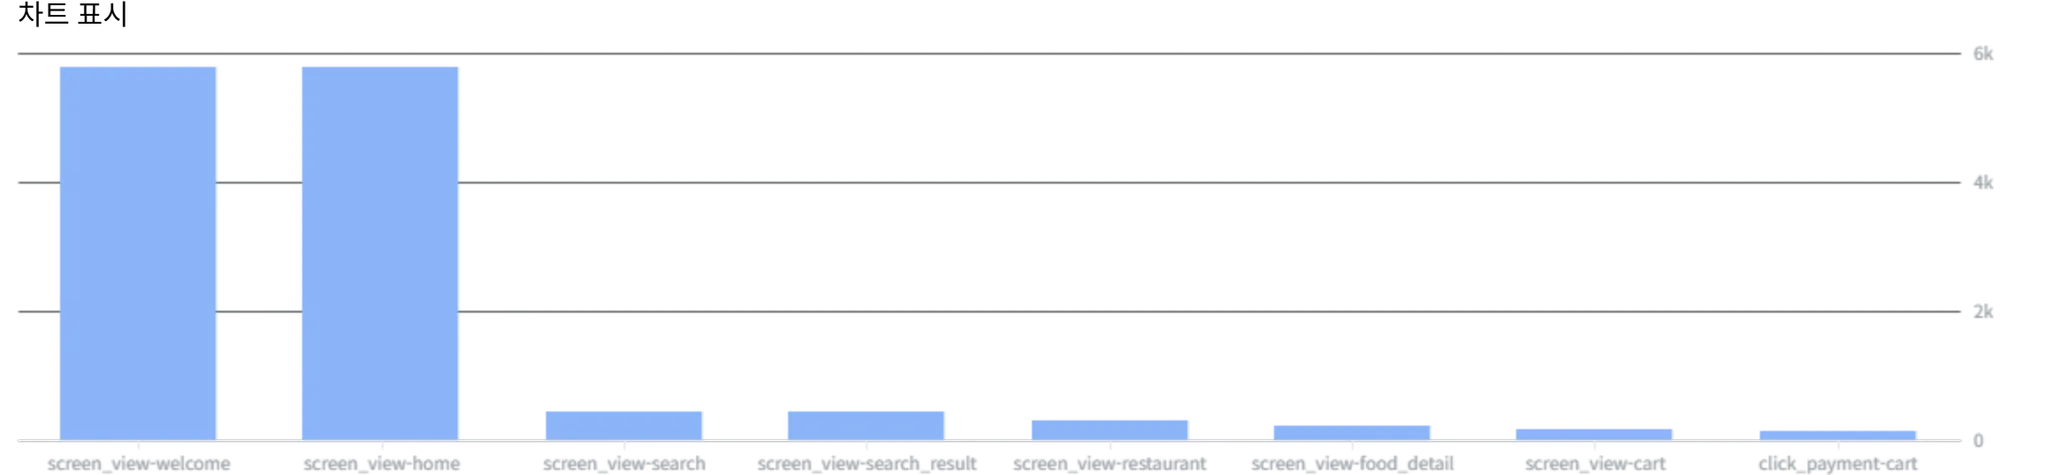

---

→ 단계별 전환율

``` sql
SELECT
  *,
  CONCAT(ROUND(SAFE_DIVIDE(funnel_cnt, pre_funnel_cnt), 2) * 100, '%') AS `funnel_step_bounce_rate`
FROM (
  SELECT
  *,
  LAG(funnel_cnt) OVER (ORDER BY step) AS `pre_funnel_cnt`
FROM set_search_funnel)
ORDER BY step;
```

| event\_name\_with\_screen   | step | funnel\_cnt | pre\_funnel\_cnt | funnel\_step\_bounce\_rate |
| --------------------------- | ---: | ----------: | ---------------: | -------------------------: |
| screen\_view-welcome        |    1 |        5785 |                  |                            |
| screen\_view-home           |    2 |        5785 |             5785 |                       100% |
| screen\_view-search         |    3 |         426 |             5785 |                         7% |
| screen\_view-search\_result |    4 |         426 |              426 |                       100% |
| screen\_view-restaurant     |    5 |         302 |              426 |                        71% |
| screen\_view-food\_detail   |    6 |         211 |              302 |                        70% |
| screen\_view-cart           |    7 |         171 |              211 |                        81% |
| click\_payment-cart         |    8 |         137 |              171 |                        80% |


---

→ 누적 전환율

``` sql
SELECT
  *,
  CONCAT(ROUND(SAFE_DIVIDE(funnel_cnt, max_funnel_cnt), 2) * 100, '%') AS `funnel_root_bounce_rate`
FROM (
  SELECT
  *,
  MAX(funnel_cnt) OVER (ORDER BY step) AS `max_funnel_cnt`
FROM set_search_funnel)
ORDER BY step;
```

| event\_name\_with\_screen   | step | funnel\_cnt | max\_funnel\_cnt | funnel\_root\_bounce\_rate |
| --------------------------- | ---: | ----------: | ---------------: | -------------------------: |
| screen\_view-welcome        |    1 |        5785 |             5785 |                       100% |
| screen\_view-home           |    2 |        5785 |             5785 |                       100% |
| screen\_view-search         |    3 |         426 |             5785 |                         7% |
| screen\_view-search\_result |    4 |         426 |             5785 |                         7% |
| screen\_view-restaurant     |    5 |         302 |             5785 |                         5% |
| screen\_view-food\_detail   |    6 |         211 |             5785 |                         4% |
| screen\_view-cart           |    7 |         171 |             5785 |                         3% |
| click\_payment-cart         |    8 |         137 |             5785 |                         2% |


#### 근처 음식점을 통한 결제 퍼널

``` sql
WITH base AS (
  SELECT
    event_date,
    event_datetime,
    event_name,
    user_pseudo_id,
    session_id,
    platform,
    MAX(IF(event_param.key = "firebase_screen", event_param.value.string_value, NULL)) AS firebase_screen,
  FROM foodie.holiday_user_logs, UNNEST(event_params) AS event_param
  GROUP BY ALL
), set_event_name_with_screen AS (
  SELECT
    user_pseudo_id,
    session_id,
    event_datetime,
    event_name,
    firebase_screen,
    platform,
    CONCAT(event_name, '-', firebase_screen)AS event_name_with_screen,
  FROM base
), select_nearby_restaurant_funnel AS (
  SELECT
    user_pseudo_id,
    session_id,
    event_datetime,
    event_name_with_screen,
    platform,
    MAX(check_num) OVER (PARTITION BY user_pseudo_id, session_id) AS `check_nearby_restaurant_funnel`
  FROM (SELECT
      *,
      IF(event_name_with_screen = 'click_restaurant_nearby-home', 1, null) AS `check_num`
    FROM set_event_name_with_screen)
  QUALIFY check_nearby_restaurant_funnel IS NOT NULL
), set_funnel_step AS (
  SELECT
    * EXCEPT(check_nearby_restaurant_funnel, platform),
    CASE
      WHEN event_name_with_screen = 'click_restaurant_nearby-home' THEN 3
      WHEN event_name_with_screen = 'screen_view-food_detail' THEN 4
      WHEN event_name_with_screen = 'screen_view-cart' THEN 5
      WHEN event_name_with_screen = 'click_payment-cart' THEN 6
      ELSE NULL
    END AS step
  FROM select_nearby_restaurant_funnel
), set_nearby_restaurant_funnel AS (
  SELECT
    event_name_with_screen,
    CASE 
      WHEN event_name_with_screen = 'screen_view-welcome' THEN 1
      WHEN event_name_with_screen = 'screen_view-home' THEN 2
    END AS step,
    COUNT(*) AS funnel_cnt
  FROM (
    SELECT
      # 다른 화면을 보다가 screen_view-home으로 돌아가는 경우 존재
      DISTINCT
        user_pseudo_id,
        session_id,
        event_name_with_screen
    FROM set_event_name_with_screen
    WHERE event_name_with_screen IN ('screen_view-welcome', 'screen_view-home')
  )
  GROUP BY event_name_with_screen
  UNION ALL
  SELECT
    event_name_with_screen,
    step,
    COUNT(*) AS `funnel_cnt`
  FROM set_funnel_step
  WHERE step IS NOT NULL
  GROUP BY event_name_with_screen, step
)
```

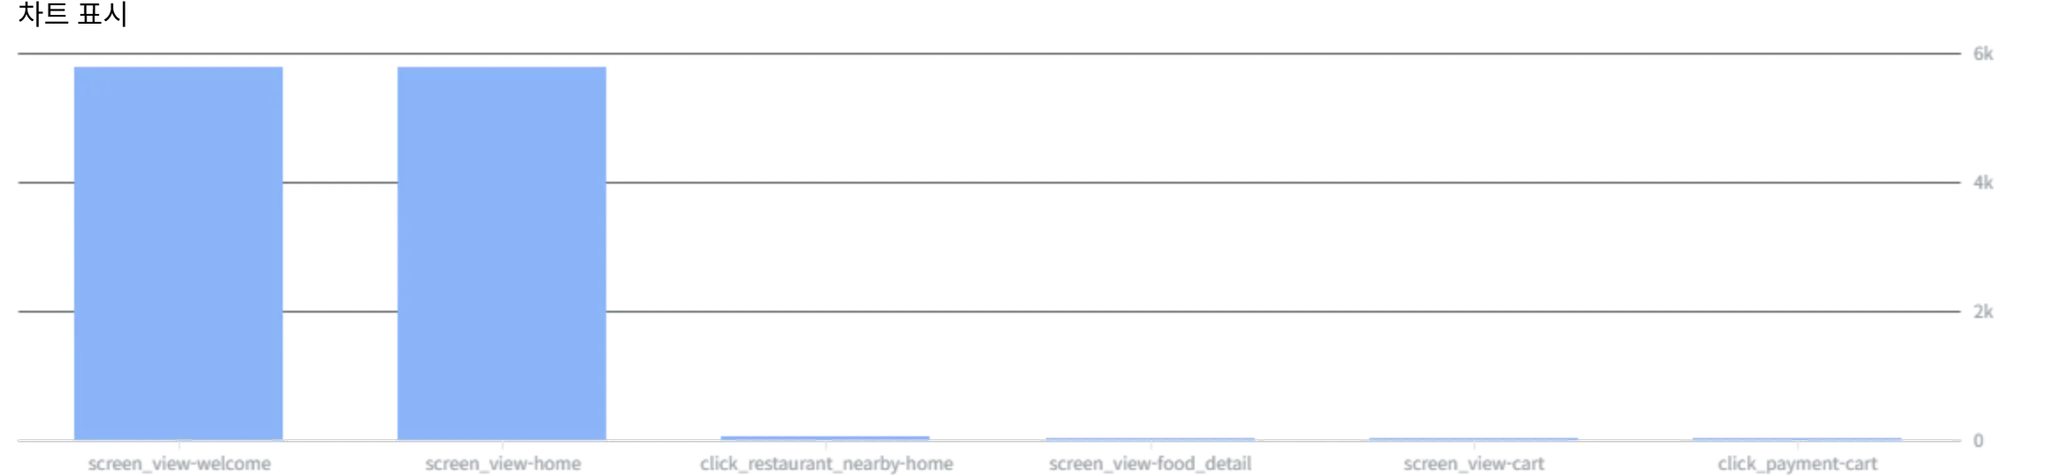

---

→ 단계별 전환율

``` sql
SELECT
  *,
  CONCAT(ROUND(SAFE_DIVIDE(funnel_cnt, pre_funnel_cnt), 2) * 100, '%') AS `funnel_step_bounce_rate`
FROM (
  SELECT
  *,
  LAG(funnel_cnt) OVER (ORDER BY step) AS `pre_funnel_cnt`
FROM set_nearby_restaurant_funnel)
ORDER BY step;
```

| event\_name\_with\_screen      | step | funnel\_cnt | pre\_funnel\_cnt | funnel\_step\_bounce\_rate |
| ------------------------------ | ---: | ----------: | ---------------: | -------------------------: |
| screen\_view-welcome           |    1 |        5785 |                  |                            |
| screen\_view-home              |    2 |        5785 |             5785 |                       100% |
| click\_restaurant\_nearby-home |    3 |          54 |             5785 |                         1% |
| screen\_view-food\_detail      |    4 |          39 |               54 |                        72% |
| screen\_view-cart              |    5 |          35 |               39 |                        90% |
| click\_payment-cart            |    6 |          30 |               35 |                        86% |


---

→ 누적 전환율

``` sql
SELECT
  *,
  CONCAT(ROUND(SAFE_DIVIDE(funnel_cnt, pre_funnel_cnt), 2) * 100, '%') AS `funnel_root_bounce_rate`
FROM (
  SELECT
  *,
  MAX(funnel_cnt) OVER (ORDER BY step) AS `pre_funnel_cnt`
FROM set_nearby_restaurant_funnel)
ORDER BY step;
```

| event\_name\_with\_screen      | step | funnel\_cnt | pre\_funnel\_cnt | funnel\_root\_bounce\_rate |
| ------------------------------ | ---: | ----------: | ---------------: | -------------------------: |
| screen\_view-welcome           |    1 |        5785 |             5785 |                       100% |
| screen\_view-home              |    2 |        5785 |             5785 |                       100% |
| click\_restaurant\_nearby-home |    3 |          54 |             5785 |                         1% |
| screen\_view-food\_detail      |    4 |          39 |             5785 |                         1% |
| screen\_view-cart              |    5 |          35 |             5785 |                         1% |
| click\_payment-cart            |    6 |          30 |             5785 |                         1% |


#### 음식 추천을 통한 결제 퍼널

``` sql
WITH base AS (
  SELECT
    event_date,
    event_datetime,
    event_name,
    user_pseudo_id,
    session_id,
    platform,
    MAX(IF(event_param.key = "firebase_screen", event_param.value.string_value, NULL)) AS firebase_screen,
  FROM foodie.holiday_user_logs, UNNEST(event_params) AS event_param
  GROUP BY ALL
), set_event_name_with_screen AS (
  SELECT
    user_pseudo_id,
    session_id,
    event_datetime,
    event_name,
    firebase_screen,
    platform,
    CONCAT(event_name, '-', firebase_screen)AS event_name_with_screen,
  FROM base
), select_recommend_food_funnel AS (
  SELECT
    user_pseudo_id,
    session_id,
    event_datetime,
    event_name_with_screen,
    platform,
    MAX(check_num) OVER (PARTITION BY user_pseudo_id, session_id) AS `check_recommend_food_funnel`
  FROM (SELECT
      *,
      IF(event_name_with_screen = 'click_recommend_food-home', 1, null) AS `check_num`
    FROM set_event_name_with_screen)
  QUALIFY check_recommend_food_funnel IS NOT NULL
), set_funnel_step AS (
  SELECT
    * EXCEPT(check_recommend_food_funnel, platform),
    CASE
      WHEN event_name_with_screen = 'click_recommend_food-home' THEN 3
      WHEN event_name_with_screen = 'screen_view-cart' THEN 4
      WHEN event_name_with_screen = 'click_payment-cart' THEN 5
      ELSE NULL
    END AS step
  FROM select_recommend_food_funnel
), set_recommend_food_funnel AS (
  SELECT
    event_name_with_screen,
    CASE 
      WHEN event_name_with_screen = 'screen_view-welcome' THEN 1
      WHEN event_name_with_screen = 'screen_view-home' THEN 2
    END AS step,
    COUNT(*) AS funnel_cnt
  FROM (
    SELECT
      # 다른 화면을 보다가 screen_view-home으로 돌아가는 경우 존재
      DISTINCT
        user_pseudo_id,
        session_id,
        event_name_with_screen
    FROM set_event_name_with_screen
    WHERE event_name_with_screen IN ('screen_view-welcome', 'screen_view-home')
  )
  GROUP BY event_name_with_screen
  UNION ALL
  SELECT
    event_name_with_screen,
    step,
    COUNT(*) AS `funnel_cnt`
  FROM set_funnel_step
  WHERE step IS NOT NULL
  GROUP BY event_name_with_screen, step
)
```

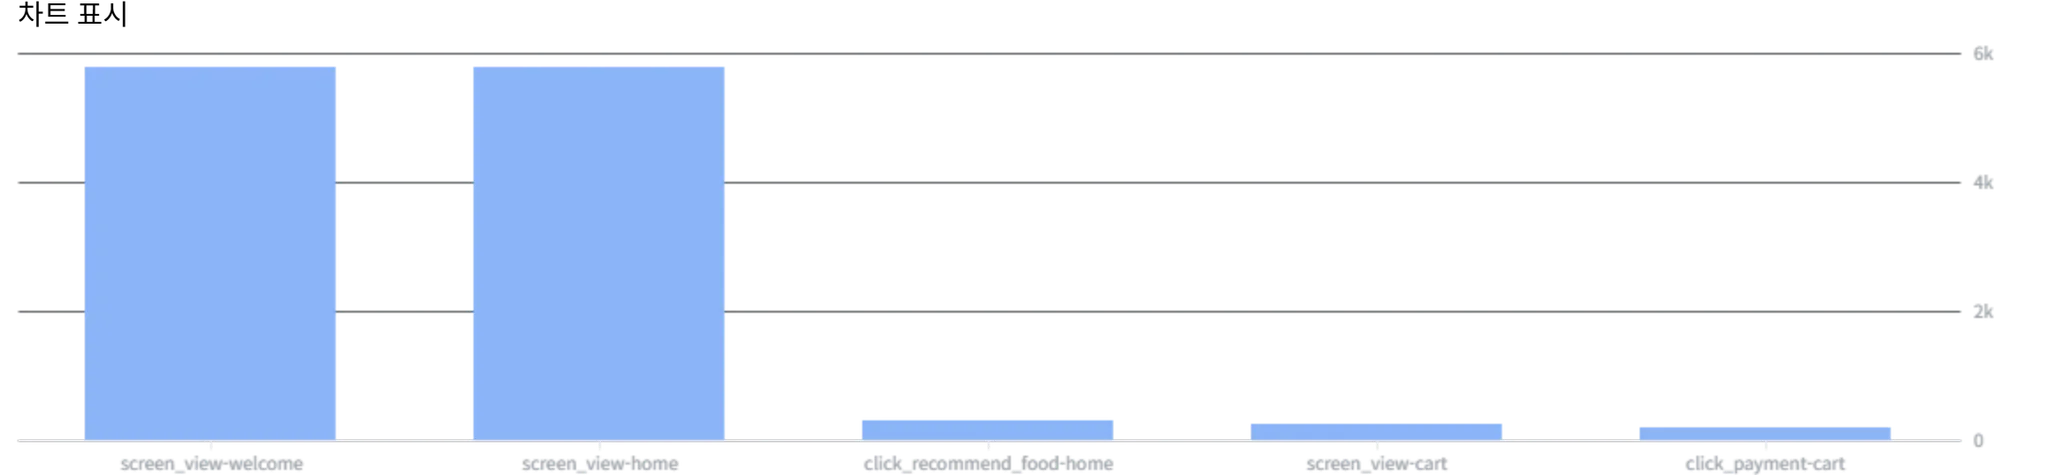

---

→ 단계별 전환율

``` sql
SELECT
  *,
  CONCAT(ROUND(SAFE_DIVIDE(funnel_cnt, pre_funnel_cnt), 2) * 100, '%') AS `funnel_step_bounce_rate`
FROM (
  SELECT
  *,
  LAG(funnel_cnt) OVER (ORDER BY step) AS `pre_funnel_cnt`
FROM set_recommend_food_funnel)
ORDER BY step;
```

| event\_name\_with\_screen   | step | funnel\_cnt | pre\_funnel\_cnt | funnel\_step\_bounce\_rate |
| --------------------------- | ---: | ----------: | ---------------: | -------------------------: |
| screen\_view-welcome        |    1 |        5785 |                  |                            |
| screen\_view-home           |    2 |        5785 |             5785 |                       100% |
| click\_recommend\_food-home |    3 |         303 |             5785 |                         5% |
| screen\_view-cart           |    4 |         256 |              303 |                        84% |
| click\_payment-cart         |    5 |         204 |              256 |                        80% |


---

→ 누적 전환율

``` sql
SELECT
  *,
  CONCAT(ROUND(SAFE_DIVIDE(funnel_cnt, pre_funnel_cnt), 2) * 100, '%') AS `funnel_root_bounce_rate`
FROM (
  SELECT
  *,
  MAX(funnel_cnt) OVER (ORDER BY step) AS `pre_funnel_cnt`
FROM set_recommend_food_funnel)
ORDER BY step;
```

| event\_name\_with\_screen   | step | funnel\_cnt | pre\_funnel\_cnt | funnel\_root\_bounce\_rate |
| --------------------------- | ---: | ----------: | ---------------: | -------------------------: |
| screen\_view-welcome        |    1 |        5785 |             5785 |                       100% |
| screen\_view-home           |    2 |        5785 |             5785 |                       100% |
| click\_recommend\_food-home |    3 |         303 |             5785 |                         5% |
| screen\_view-cart           |    4 |         256 |             5785 |                         4% |
| click\_payment-cart         |    5 |         204 |             5785 |                         4% |


#### 시간대별 카테고리를 통한 전활율 파악
→ 점심과 저녁 시간에 사용자들이 가장 많이 이용. 공휴일 접속 사용자들의 전체 전환율은 약 39%인데 카테고리를 통한 전환은 사용하는 사람 수는 많지만 전환율은 높지 않음. 사용자들이 가장 많이 이용하는 시간대인 점심, 저녁 시간대 집중 분석

``` sql
WITH base AS (
  SELECT
    event_date,
    event_datetime,
    event_name,
    user_pseudo_id,
    session_id,
    MAX(IF(event_param.key = "firebase_screen", event_param.value.string_value, NULL)) AS firebase_screen,
  FROM foodie.holiday_user_logs, UNNEST(event_params) AS event_param
  GROUP BY ALL
), set_event_name_with_screen AS (
  SELECT
    user_pseudo_id,
    session_id,
    event_datetime,
    CASE
      WHEN event_hour IN (0, 1, 2, 3) THEN '늦은 야식'
      WHEN event_hour IN (4, 5, 6) THEN '이른 아침'
      WHEN event_hour IN (7, 8, 9) THEN '아침'
      WHEN event_hour IN (10, 11) THEN '늦은 아침'
      WHEN event_hour IN (12, 13, 14) THEN '점심'
      WHEN event_hour IN (15, 16) THEN '애프터눈 티'
      WHEN event_hour IN (17, 18, 19, 20) THEN '저녁'
      WHEN event_hour IN (21, 22, 23) THEN  '야식'
    END AS meal_time,
    CONCAT(event_name, '-', firebase_screen)AS event_name_with_screen
  FROM (
    SELECT
      *,
      EXTRACT(HOUR FROM event_datetime) AS `event_hour`
    FROM base
  )
), select_food_category_funnel AS (
  SELECT
    user_pseudo_id,
    session_id,
    event_datetime,
    meal_time,
    event_name_with_screen,
    MAX(check_num) OVER (PARTITION BY user_pseudo_id, session_id) AS `check_category_funnel`
  FROM (SELECT
      *,
      IF(event_name_with_screen = 'screen_view-food_category', 1, null) AS `check_num`
    FROM set_event_name_with_screen)
  QUALIFY check_category_funnel IS NOT NULL
), set_funnel_step AS (
  SELECT
    * EXCEPT(check_category_funnel),
    CASE
      WHEN event_name_with_screen = 'screen_view-food_category' THEN 3
      WHEN event_name_with_screen = 'screen_view-restaurant' THEN 4
      WHEN event_name_with_screen = 'screen_view-food_detail' THEN 5
      WHEN event_name_with_screen = 'screen_view-cart' THEN 6
      WHEN event_name_with_screen = 'click_payment-cart' THEN 7
      ELSE NULL
    END AS step
  FROM select_food_category_funnel
), set_category_funnel AS (
  SELECT
    event_name_with_screen,
    CASE 
      WHEN event_name_with_screen = 'screen_view-welcome' THEN 1
      WHEN event_name_with_screen = 'screen_view-home' THEN 2
    END AS step,
    meal_time,
    COUNT(*) AS funnel_cnt
  FROM (
    SELECT
      # 다른 화면을 보다가 screen_view-home으로 돌아가는 경우 존재
      DISTINCT
        user_pseudo_id,
        session_id,
        event_name_with_screen,
        meal_time
    FROM set_event_name_with_screen
    WHERE event_name_with_screen IN ('screen_view-welcome', 'screen_view-home')
  )
  GROUP BY event_name_with_screen, meal_time
  UNION ALL
  SELECT
    event_name_with_screen,
    step,
    meal_time,
    COUNT(*) AS `funnel_cnt`
  FROM set_funnel_step
  WHERE step IS NOT NULL
  GROUP BY event_name_with_screen, step, meal_time
)
```

##### 이른 아침

``` sql
SELECT
  *,
  CONCAT(ROUND(SAFE_DIVIDE(funnel_cnt, root_funnel_cnt), 2) * 100, '%') AS `funnel_root_bounce_rate`
FROM (
  SELECT
  *,
  MAX(funnel_cnt) OVER (PARTITION BY meal_time) AS `root_funnel_cnt`
FROM set_category_funnel)
WHERE meal_time = '이른 아침'
ORDER BY meal_time, step;
```

| event\_name\_with\_screen   | step | meal\_time | funnel\_cnt | root\_funnel\_cnt | funnel\_root\_bounce\_rate |
| --------------------------- | ---: | ---------- | ----------: | ----------------: | -------------------------: |
| screen\_view-welcome        |    1 | 이른 아침      |         183 |               183 |                       100% |
| screen\_view-home           |    2 | 이른 아침      |         183 |               183 |                       100% |
| screen\_view-food\_category |    3 | 이른 아침      |         148 |               183 |                        81% |
| screen\_view-restaurant     |    4 | 이른 아침      |         124 |               183 |                        68% |
| screen\_view-food\_detail   |    5 | 이른 아침      |          94 |               183 |                        51% |
| screen\_view-cart           |    6 | 이른 아침      |          76 |               183 |                        42% |
| click\_payment-cart         |    7 | 이른 아침      |          62 |               183 |                        34% |


##### 아침

``` sql
SELECT
  *,
  CONCAT(ROUND(SAFE_DIVIDE(funnel_cnt, root_funnel_cnt), 2) * 100, '%') AS `funnel_root_bounce_rate`
FROM (
  SELECT
  *,
  MAX(funnel_cnt) OVER (PARTITION BY meal_time) AS `root_funnel_cnt`
FROM set_category_funnel)
WHERE meal_time = '아침'
ORDER BY meal_time, step;
```

| event\_name\_with\_screen   | step | meal\_time | funnel\_cnt | root\_funnel\_cnt | funnel\_root\_bounce\_rate |
| --------------------------- | ---: | ---------- | ----------: | ----------------: | -------------------------: |
| screen\_view-welcome        |    1 | 아침         |         262 |               262 |                       100% |
| screen\_view-home           |    2 | 아침         |         262 |               262 |                       100% |
| screen\_view-food\_category |    3 | 아침         |         213 |               262 |                        81% |
| screen\_view-restaurant     |    4 | 아침         |         174 |               262 |                        66% |
| screen\_view-food\_detail   |    5 | 아침         |         139 |               262 |                        53% |
| screen\_view-cart           |    6 | 아침         |         116 |               262 |                        44% |
| click\_payment-cart         |    7 | 아침         |          96 |               262 |                        37% |


##### 늦은 아침

``` sql
SELECT
  *,
  CONCAT(ROUND(SAFE_DIVIDE(funnel_cnt, root_funnel_cnt), 2) * 100, '%') AS `funnel_root_bounce_rate`
FROM (
  SELECT
  *,
  MAX(funnel_cnt) OVER (PARTITION BY meal_time) AS `root_funnel_cnt`
FROM set_category_funnel)
WHERE meal_time = '늦은 아침'
ORDER BY meal_time, step;
```

| event\_name\_with\_screen   | step | meal\_time | funnel\_cnt | root\_funnel\_cnt | funnel\_root\_bounce\_rate |
| --------------------------- | ---: | ---------- | ----------: | ----------------: | -------------------------: |
| screen\_view-welcome        |    1 | 늦은 아침      |         496 |               496 |                       100% |
| screen\_view-home           |    2 | 늦은 아침      |         496 |               496 |                       100% |
| screen\_view-food\_category |    3 | 늦은 아침      |         386 |               496 |                        78% |
| screen\_view-restaurant     |    4 | 늦은 아침      |         302 |               496 |                        61% |
| screen\_view-food\_detail   |    5 | 늦은 아침      |         246 |               496 |                        50% |
| screen\_view-cart           |    6 | 늦은 아침      |         203 |               496 |                        41% |
| click\_payment-cart         |    7 | 늦은 아침      |         162 |               496 |                        33% |


##### 점심

``` sql
SELECT
  *,
  CONCAT(ROUND(SAFE_DIVIDE(funnel_cnt, root_funnel_cnt), 2) * 100, '%') AS `funnel_root_bounce_rate`
FROM (
  SELECT
  *,
  MAX(funnel_cnt) OVER (PARTITION BY meal_time) AS `root_funnel_cnt`
FROM set_category_funnel)
WHERE meal_time = '점심'
ORDER BY meal_time, step;
```

| event\_name\_with\_screen   | step | meal\_time | funnel\_cnt | root\_funnel\_cnt | funnel\_root\_bounce\_rate |
| --------------------------- | ---: | ---------- | ----------: | ----------------: | -------------------------: |
| screen\_view-welcome        |    1 | 점심         |        1252 |              1252 |                       100% |
| screen\_view-home           |    2 | 점심         |        1252 |              1252 |                       100% |
| screen\_view-food\_category |    3 | 점심         |         994 |              1252 |                        79% |
| screen\_view-restaurant     |    4 | 점심         |         783 |              1252 |                        63% |
| screen\_view-food\_detail   |    5 | 점심         |         620 |              1252 |                        50% |
| screen\_view-cart           |    6 | 점심         |         497 |              1252 |                        40% |
| click\_payment-cart         |    7 | 점심         |         401 |              1252 |                        32% |


##### 애프터눈 티

``` sql
SELECT
  *,
  CONCAT(ROUND(SAFE_DIVIDE(funnel_cnt, root_funnel_cnt), 2) * 100, '%') AS `funnel_root_bounce_rate`
FROM (
  SELECT
  *,
  MAX(funnel_cnt) OVER (PARTITION BY meal_time) AS `root_funnel_cnt`
FROM set_category_funnel)
WHERE meal_time = '애프터눈 티'
ORDER BY meal_time, step;
```

| event\_name\_with\_screen   | step | meal\_time | funnel\_cnt | root\_funnel\_cnt | funnel\_root\_bounce\_rate |
| --------------------------- | ---: | ---------- | ----------: | ----------------: | -------------------------: |
| screen\_view-welcome        |    1 | 애프터눈 티     |         801 |               801 |                       100% |
| screen\_view-home           |    2 | 애프터눈 티     |         801 |               801 |                       100% |
| screen\_view-food\_category |    3 | 애프터눈 티     |         641 |               801 |                        80% |
| screen\_view-restaurant     |    4 | 애프터눈 티     |         517 |               801 |                        65% |
| screen\_view-food\_detail   |    5 | 애프터눈 티     |         414 |               801 |                        52% |
| screen\_view-cart           |    6 | 애프터눈 티     |         321 |               801 |                        40% |
| click\_payment-cart         |    7 | 애프터눈 티     |         250 |               801 |                        31% |


##### 저녁

``` sql
SELECT
  *,
  CONCAT(ROUND(SAFE_DIVIDE(funnel_cnt, root_funnel_cnt), 2) * 100, '%') AS `funnel_root_bounce_rate`
FROM (
  SELECT
  *,
  MAX(funnel_cnt) OVER (PARTITION BY meal_time) AS `root_funnel_cnt`
FROM set_category_funnel)
WHERE meal_time = '저녁'
ORDER BY meal_time, step;
```

| event\_name\_with\_screen   | step | meal\_time | funnel\_cnt | root\_funnel\_cnt | funnel\_root\_bounce\_rate |
| --------------------------- | ---: | ---------- | ----------: | ----------------: | -------------------------: |
| screen\_view-welcome        |    1 | 저녁         |        1705 |              1705 |                       100% |
| screen\_view-home           |    2 | 저녁         |        1705 |              1705 |                       100% |
| screen\_view-food\_category |    3 | 저녁         |        1381 |              1705 |                        81% |
| screen\_view-restaurant     |    4 | 저녁         |        1093 |              1705 |                        64% |
| screen\_view-food\_detail   |    5 | 저녁         |         858 |              1705 |                        50% |
| screen\_view-cart           |    6 | 저녁         |         700 |              1705 |                        41% |
| click\_payment-cart         |    7 | 저녁         |         552 |              1705 |                        32% |


##### 야식

``` sql
SELECT
  *,
  CONCAT(ROUND(SAFE_DIVIDE(funnel_cnt, root_funnel_cnt), 2) * 100, '%') AS `funnel_root_bounce_rate`
FROM (
  SELECT
  *,
  MAX(funnel_cnt) OVER (PARTITION BY meal_time) AS `root_funnel_cnt`
FROM set_category_funnel)
WHERE meal_time = '야식'
```

| event\_name\_with\_screen   | step | meal\_time | funnel\_cnt | root\_funnel\_cnt | funnel\_root\_bounce\_rate |
| --------------------------- | ---: | ---------- | ----------: | ----------------: | -------------------------: |
| screen\_view-welcome        |    1 | 야식         |         847 |               847 |                       100% |
| screen\_view-home           |    2 | 야식         |         847 |               847 |                       100% |
| screen\_view-food\_category |    3 | 야식         |         673 |               847 |                        79% |
| screen\_view-restaurant     |    4 | 야식         |         517 |               847 |                        61% |
| screen\_view-food\_detail   |    5 | 야식         |         415 |               847 |                        49% |
| screen\_view-cart           |    6 | 야식         |         334 |               847 |                        39% |
| click\_payment-cart         |    7 | 야식         |         267 |               847 |                        32% |


##### 늦은 야식

``` sql
SELECT
  *,
  CONCAT(ROUND(SAFE_DIVIDE(funnel_cnt, root_funnel_cnt), 2) * 100, '%') AS `funnel_root_bounce_rate`
FROM (
  SELECT
  *,
  MAX(funnel_cnt) OVER (PARTITION BY meal_time) AS `root_funnel_cnt`
FROM set_category_funnel)
WHERE meal_time = '늦은 야식'
```

| event\_name\_with\_screen   | step | meal\_time | funnel\_cnt | root\_funnel\_cnt | funnel\_root\_bounce\_rate |
| --------------------------- | ---: | ---------- | ----------: | ----------------: | -------------------------: |
| screen\_view-welcome        |    1 | 늦은 야식      |         239 |               239 |                       100% |
| screen\_view-home           |    2 | 늦은 야식      |         239 |               239 |                       100% |
| screen\_view-food\_category |    3 | 늦은 야식      |         175 |               239 |                        73% |
| screen\_view-restaurant     |    4 | 늦은 야식      |         136 |               239 |                        57% |
| screen\_view-food\_detail   |    5 | 늦은 야식      |         110 |               239 |                        46% |
| screen\_view-cart           |    6 | 늦은 야식      |          92 |               239 |                        38% |
| click\_payment-cart         |    7 | 늦은 야식      |          70 |               239 |                        29% |


### 5-2. 공휴일에 접속하는 사용자들의 전환이 가장 많이 이루어지는 점심, 저녁 시간대의 관심 음식 파악
→ 점심, 저녁 모두 일식을 클릭해보는 비율이 높았으나 다른 카테고리 메뉴와 큰 차이를 보이지 않음. 사용자들이 치킨을 가장 많이 검색해봤는데 치킨을 카테고리 메뉴 중 하나로 넣는 것 고려

#### 공휴일 접속 사용자들의 관심 키워드 파악

``` sql
WITH base AS (
  SELECT
    * EXCEPT(platform, event_params)
  FROM foodie.holiday_user_logs, UNNEST(event_params) AS param
)

SELECT
  search_keyword,
  COUNT(*) AS `keyword_cnt`
FROM (
  SELECT
    event_datetime,
    IF(value.string_value IN ('ㅊㅋ', 'ㅊ킨'), '치킨', value.string_value) AS `search_keyword`
  FROM base
  WHERE event_name = 'request_search' AND key = 'search_keyword'
  )
GROUP BY search_keyword
ORDER BY keyword_cnt DESC
LIMIT 3;
```

| search\_keyword | keyword\_cnt |
| --------------- | -----------: |
| 치킨              |          114 |
| 탄산              |           49 |
| 카일              |           40 |


#### 공휴일 접속 사용자들의 관심 Food_Category 파악

##### 점심

``` sql
WITH base AS (
  SELECT
    user_pseudo_id,
    session_id,
    event_date,
    event_datetime,
    EXTRACT(HOUR FROM event_datetime) AS `event_hour`,
    param.value.string_value AS `food_category`
  FROM foodie.holiday_user_logs, UNNEST(event_params) AS `param`
  WHERE event_name = 'click_food_category' AND param.key = 'food_category'
), set_meal_time AS (
  SELECT
    * EXCEPT(event_hour),
    CASE
      WHEN event_hour IN (0, 1, 2, 3) THEN '늦은 야식'
      WHEN event_hour IN (4, 5, 6) THEN '이른 아침'
      WHEN event_hour IN (7, 8, 9) THEN '아침'
      WHEN event_hour IN (10, 11) THEN '늦은 아침'
      WHEN event_hour IN (12, 13, 14) THEN '점심'
      WHEN event_hour IN (15, 16) THEN '애프터눈 티'
      WHEN event_hour IN (17, 18, 19, 20) THEN '저녁'
      WHEN event_hour IN (21, 22, 23) THEN  '야식'
    END AS meal_time,
  FROM base
)

SELECT
  meal_time,
  food_category,
  COUNT(*) AS `food_category_cnt`
FROM set_meal_time
WHERE meal_time = '점심'
GROUP BY meal_time, food_category
ORDER BY food_category_cnt DESC;
```

| meal\_time | food\_category | food\_category\_cnt |
| ---------- | -------------- | ------------------: |
| 점심         | 일식             |                 178 |
| 점심         | 피자             |                 173 |
| 점심         | 한식             |                 166 |
| 점심         | 햄버거            |                 164 |
| 점심         | 고기             |                 160 |
| 점심         | 커피             |                 153 |


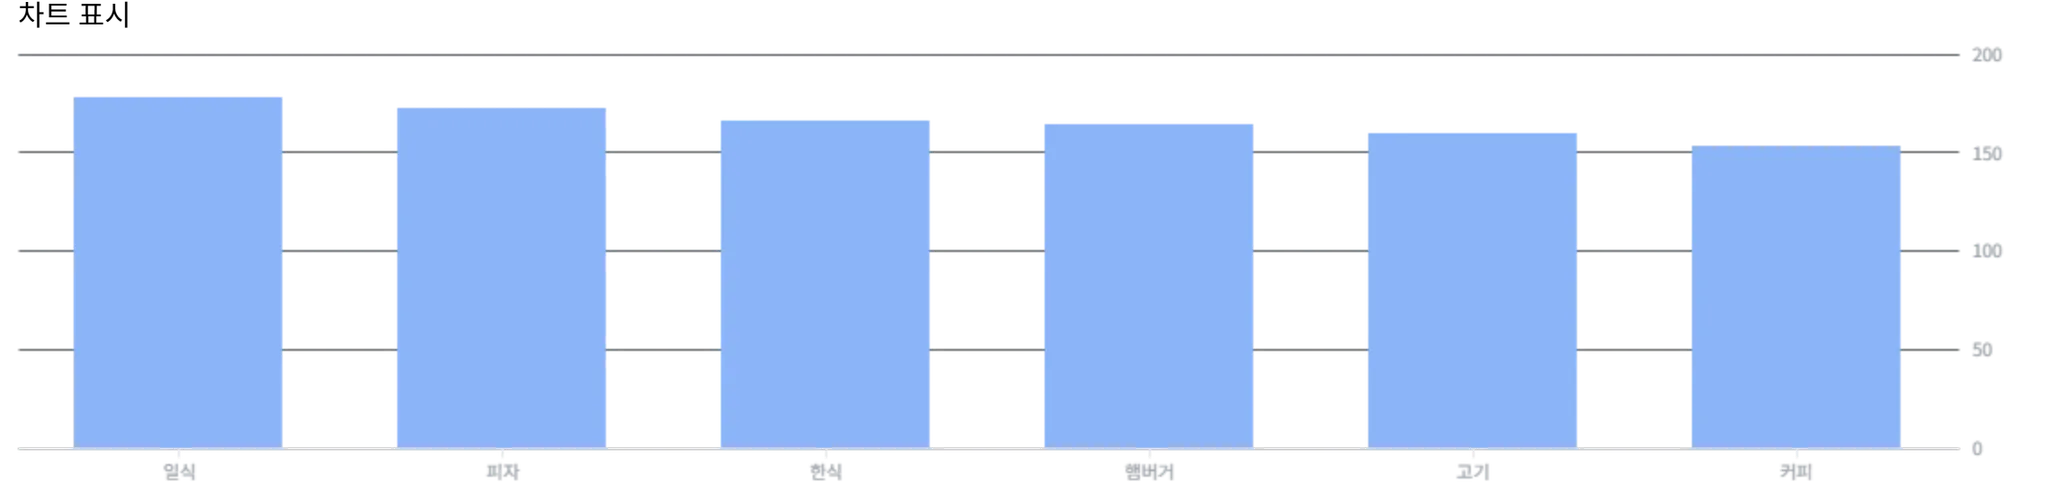

##### 저녁

``` sql
WITH base AS (
  SELECT
    user_pseudo_id,
    session_id,
    event_date,
    event_datetime,
    EXTRACT(HOUR FROM event_datetime) AS `event_hour`,
    param.value.string_value AS `food_category`
  FROM foodie.holiday_user_logs, UNNEST(event_params) AS `param`
  WHERE event_name = 'click_food_category' AND param.key = 'food_category'
), set_meal_time AS (
  SELECT
    * EXCEPT(event_hour),
    CASE
      WHEN event_hour IN (0, 1, 2, 3) THEN '늦은 야식'
      WHEN event_hour IN (4, 5, 6) THEN '이른 아침'
      WHEN event_hour IN (7, 8, 9) THEN '아침'
      WHEN event_hour IN (10, 11) THEN '늦은 아침'
      WHEN event_hour IN (12, 13, 14) THEN '점심'
      WHEN event_hour IN (15, 16) THEN '애프터눈 티'
      WHEN event_hour IN (17, 18, 19, 20) THEN '저녁'
      WHEN event_hour IN (21, 22, 23) THEN  '야식'
    END AS meal_time
  FROM base
)

SELECT
  meal_time,
  food_category,
  COUNT(*) AS `food_category_cnt`
FROM set_meal_time
WHERE meal_time = '저녁'
GROUP BY meal_time, food_category
ORDER BY food_category_cnt DESC;
```

| meal\_time | food\_category | food\_category\_cnt |
| ---------- | -------------- | ------------------: |
| 저녁         | 일식             |                 266 |
| 저녁         | 고기             |                 239 |
| 저녁         | 피자             |                 230 |
| 저녁         | 한식             |                 229 |
| 저녁         | 커피             |                 211 |
| 저녁         | 햄버거            |                 206 |


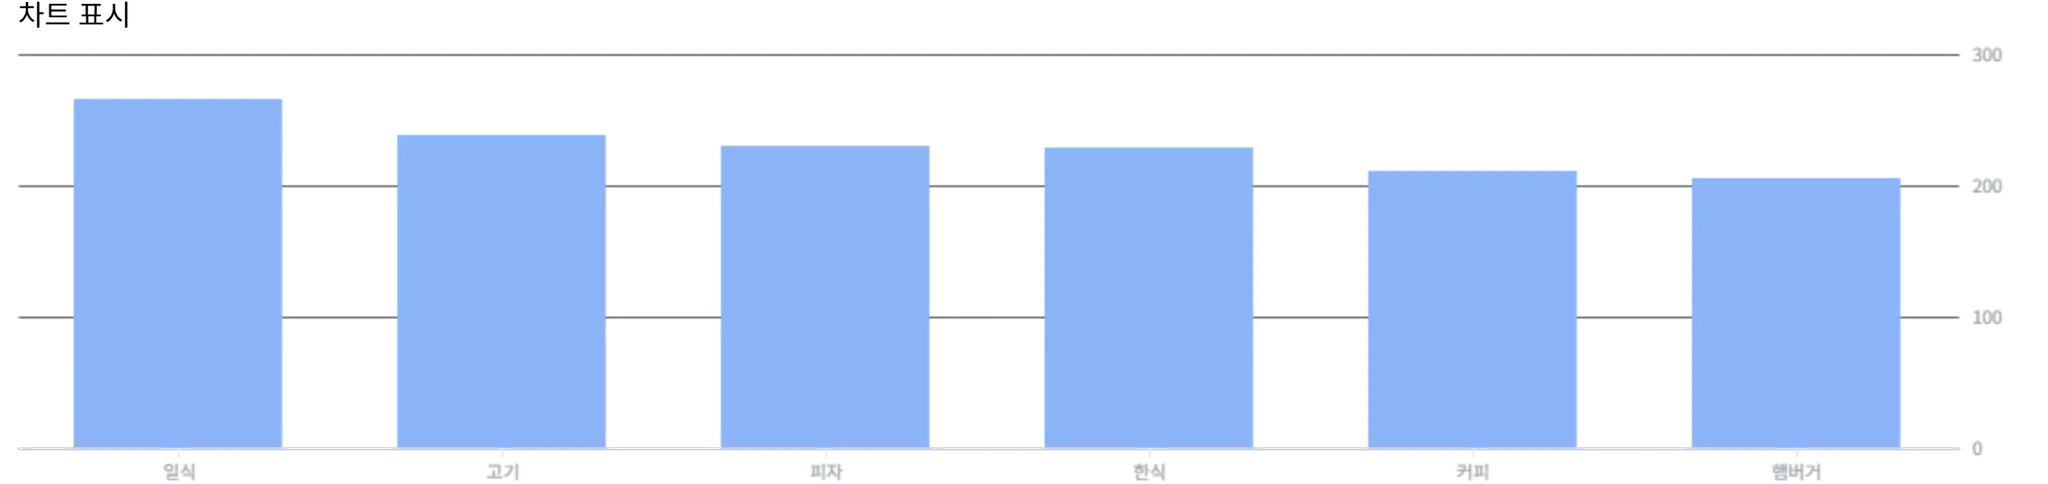

### 5-3. 공휴일 접속 사용자들이 장바구니(Cart)에 진입할 때 최소 주문 금액 충족 여부 파악

#### 점심

``` sql
WITH base AS (
  SELECT
    *,
    CASE
      WHEN event_hour IN (0, 1, 2, 3) THEN '늦은 야식'
      WHEN event_hour IN (4, 5, 6) THEN '이른 아침'
      WHEN event_hour IN (7, 8, 9) THEN '아침'
      WHEN event_hour IN (10, 11) THEN '늦은 아침'
      WHEN event_hour IN (12, 13, 14) THEN '점심'
      WHEN event_hour IN (15, 16) THEN '애프터눈 티'
      WHEN event_hour IN (17, 18, 19, 20) THEN '저녁'
      WHEN event_hour IN (21, 22, 23) THEN  '야식'
    END AS meal_time
  FROM (
    SELECT
      * EXCEPT(platform, event_params),
      EXTRACT(HOUR FROM event_datetime) AS `event_hour`
    FROM foodie.holiday_user_logs, UNNEST(event_params) AS param
    )
), check_cart_session AS (
  SELECT
    * EXCEPT (check_num),
    MAX(check_num) OVER (PARTITION BY user_pseudo_id, session_id) AS `check_num`
  FROM (
    SELECT
      *,
      IF(event_name = 'view_recommend_extra_food', 1, null) AS `check_num`
    FROM base
    )
), select_cart_session AS (
  SELECT
    user_pseudo_id,
    session_id,
    event_datetime,
    meal_time,
    value.int_value AS `is_meet_min_order_price`
  FROM check_cart_session
  WHERE event_name = 'view_recommend_extra_food' AND key = 'is_meet_min_order_price'
)

SELECT 
  is_meet_min_order_price,
  COUNT(*) AS `cnt`
FROM (
  SELECT
    user_pseudo_id,
    session_id,
    event_datetime,
    meal_time,
    IF(is_meet_min_order_price = 1, '충족', '불충족') AS `is_meet_min_order_price`
  FROM select_cart_session)
WHERE meal_time = '점심'
GROUP BY meal_time, is_meet_min_order_price;
```

| is\_meet\_min\_order\_price | cnt |
| --------------------------- | --: |
| 불충족                         | 475 |
| 충족                          | 112 |


#### 저녁

``` sql
WITH base AS (
  SELECT
    *,
    CASE
      WHEN event_hour IN (0, 1, 2, 3) THEN '늦은 야식'
      WHEN event_hour IN (4, 5, 6) THEN '이른 아침'
      WHEN event_hour IN (7, 8, 9) THEN '아침'
      WHEN event_hour IN (10, 11) THEN '늦은 아침'
      WHEN event_hour IN (12, 13, 14) THEN '점심'
      WHEN event_hour IN (15, 16) THEN '애프터눈 티'
      WHEN event_hour IN (17, 18, 19, 20) THEN '저녁'
      WHEN event_hour IN (21, 22, 23) THEN  '야식'
    END AS meal_time
  FROM (
    SELECT
      * EXCEPT(platform, event_params),
      EXTRACT(HOUR FROM event_datetime) AS `event_hour`
    FROM foodie.holiday_user_logs, UNNEST(event_params) AS param
    )
), check_cart_session AS (
  SELECT
    * EXCEPT (check_num),
    MAX(check_num) OVER (PARTITION BY user_pseudo_id, session_id) AS `check_num`
  FROM (
    SELECT
      *,
      IF(event_name = 'view_recommend_extra_food', 1, null) AS `check_num`
    FROM base
    )
), select_cart_session AS (
  SELECT
    user_pseudo_id,
    session_id,
    event_datetime,
    meal_time,
    value.int_value AS `is_meet_min_order_price`
  FROM check_cart_session
  WHERE event_name = 'view_recommend_extra_food' AND key = 'is_meet_min_order_price'
)

SELECT 
  is_meet_min_order_price,
  COUNT(*) AS `cnt`
FROM (
  SELECT
    user_pseudo_id,
    session_id,
    event_datetime,
    meal_time,
    IF(is_meet_min_order_price = 1, '충족', '불충족') AS `is_meet_min_order_price`
  FROM select_cart_session)
WHERE meal_time = '저녁'
GROUP BY meal_time, is_meet_min_order_price;
```

| is\_meet\_min\_order\_price | cnt |
| --------------------------- | --: |
| 불충족                         | 645 |
| 충족                          | 184 |


### 5-4. 공휴일 접속 사용자들이 주문 직전 추천 음식 추가 비율 파악

#### 점심

``` sql
WITH base AS (
  SELECT
    *,
    value.int_value AS `is_meet_min_order_price`,
    CASE
      WHEN event_hour IN (0, 1, 2, 3) THEN '늦은 야식'
      WHEN event_hour IN (4, 5, 6) THEN '이른 아침'
      WHEN event_hour IN (7, 8, 9) THEN '아침'
      WHEN event_hour IN (10, 11) THEN '늦은 아침'
      WHEN event_hour IN (12, 13, 14) THEN '점심'
      WHEN event_hour IN (15, 16) THEN '애프터눈 티'
      WHEN event_hour IN (17, 18, 19, 20) THEN '저녁'
      WHEN event_hour IN (21, 22, 23) THEN  '야식'
    END AS meal_time
  FROM (
    SELECT
      * EXCEPT(platform, event_params),
      EXTRACT(HOUR FROM event_datetime) AS `event_hour`
    FROM foodie.holiday_user_logs, UNNEST(event_params) AS param
    WHERE event_name = 'click_recommend_extra_food'
    )
)

SELECT
  is_meet_min_order_price,
  COUNT(*) AS `cnt`
FROM (
  SELECT
    user_pseudo_id,
    session_id,
    event_datetime,
    meal_time,
    IF(is_meet_min_order_price = 1, '충족', '불충족') AS `is_meet_min_order_price`
  FROM base
  WHERE key='is_meet_min_order_price'
  )
WHERE meal_time = '점심'
GROUP BY meal_time, is_meet_min_order_price;
```

| is\_meet\_min\_order\_price | cnt |
| --------------------------- | --: |
| 불충족                         | 187 |
| 충족                          |  44 |


#### 저녁

```sql
WITH base AS (
  SELECT
    *,
    value.int_value AS `is_meet_min_order_price`,
    CASE
      WHEN event_hour IN (0, 1, 2, 3) THEN '늦은 야식'
      WHEN event_hour IN (4, 5, 6) THEN '이른 아침'
      WHEN event_hour IN (7, 8, 9) THEN '아침'
      WHEN event_hour IN (10, 11) THEN '늦은 아침'
      WHEN event_hour IN (12, 13, 14) THEN '점심'
      WHEN event_hour IN (15, 16) THEN '애프터눈 티'
      WHEN event_hour IN (17, 18, 19, 20) THEN '저녁'
      WHEN event_hour IN (21, 22, 23) THEN  '야식'
    END AS meal_time
  FROM (
    SELECT
      * EXCEPT(platform, event_params),
      EXTRACT(HOUR FROM event_datetime) AS `event_hour`
    FROM foodie.holiday_user_logs, UNNEST(event_params) AS param
    WHERE event_name = 'click_recommend_extra_food'
    )
)

SELECT
  is_meet_min_order_price,
  COUNT(*) AS `cnt`
FROM (
  SELECT
    user_pseudo_id,
    session_id,
    event_datetime,
    meal_time,
    IF(is_meet_min_order_price = 1, '충족', '불충족') AS `is_meet_min_order_price`
  FROM base
  WHERE key='is_meet_min_order_price'
  )
WHERE meal_time = '저녁'
GROUP BY meal_time, is_meet_min_order_price;
```

| is\_meet\_min\_order\_price | cnt |
| --------------------------- | --: |
| 불충족                         | 262 |
| 충족                          |  75 |

### 5.5 공휴일 접속 사용자들이 추천 음식을 추가하고 결제까지 이어지는 비율 파악

#### 점심

``` sql
WITH base AS (
  SELECT
    *,
    CASE
      WHEN event_hour IN (0, 1, 2, 3) THEN '늦은 야식'
      WHEN event_hour IN (4, 5, 6) THEN '이른 아침'
      WHEN event_hour IN (7, 8, 9) THEN '아침'
      WHEN event_hour IN (10, 11) THEN '늦은 아침'
      WHEN event_hour IN (12, 13, 14) THEN '점심'
      WHEN event_hour IN (15, 16) THEN '애프터눈 티'
      WHEN event_hour IN (17, 18, 19, 20) THEN '저녁'
      WHEN event_hour IN (21, 22, 23) THEN  '야식'
    END AS meal_time
  FROM (
    SELECT
      * EXCEPT(platform, event_params),
      EXTRACT(HOUR FROM event_datetime) AS `event_hour`
    FROM foodie.holiday_user_logs, UNNEST(event_params) AS param
    )
), check_extra_food_session AS (
  SELECT
    *,
    IF(event_name = 'click_recommend_extra_food', 1, null) AS `extra_check_num`
  FROM base
), select_extra_food_session AS (
  SELECT
    * EXCEPT(check)
  FROM (
    SELECT
      * EXCEPT(extra_check_num),
      MAX(extra_check_num) OVER (PARTITION BY user_pseudo_id, session_id) AS `check`
    FROM check_extra_food_session
  )
  WHERE check = 1
), select_extra_payment_session AS (
  SELECT
    * EXCEPT(check),
    MAX(check) OVER (PARTITION BY user_pseudo_id, session_id) AS `payment_check_num`
  FROM (
    SELECT
      *,
      IF(event_name = 'click_payment', 1, null) AS `check`
    FROM select_extra_food_session
    )
  QUALIFY payment_check_num = 1
), is_meet_min_order_user_recommend_food AS (
SELECT
    DISTINCT
      user_pseudo_id,
      session_id,
      event_date,
      meal_time,
      MAX(use_recommend_food) OVER (PARTITION BY user_pseudo_id, session_id) AS `use_recommend_food`,
      MAX(is_meet_min_order_price) OVER (PARTITION BY user_pseudo_id, session_id) AS `is_meet_min_order_price`
  FROM (
    SELECT
      user_pseudo_id,
      session_id,
      event_date,
      meal_time,
      value.string_value AS `use_recommend_food`,
      value.int_value AS `is_meet_min_order_price`
    FROM select_extra_payment_session
      WHERE (event_name = 'click_payment' AND key = 'use_recommend_food') OR (event_name = 'click_recommend_extra_food' AND key='is_meet_min_order_price')
  )
)

SELECT
  IF(is_meet_min_order_price=1, '충족', '불충족') AS `is_meet_min_order_price`,
  COUNT(*) AS `cnt`
FROM is_meet_min_order_user_recommend_food
WHERE meal_time = '점심'
GROUP BY meal_time, is_meet_min_order_price;
```

| is\_meet\_min\_order\_price | cnt |
| --------------------------- | --: |
| 불충족                         | 149 |
| 충족                          |  37 |


#### 저녁

``` sql
WITH base AS (
  SELECT
    *,
    CASE
      WHEN event_hour IN (0, 1, 2, 3) THEN '늦은 야식'
      WHEN event_hour IN (4, 5, 6) THEN '이른 아침'
      WHEN event_hour IN (7, 8, 9) THEN '아침'
      WHEN event_hour IN (10, 11) THEN '늦은 아침'
      WHEN event_hour IN (12, 13, 14) THEN '점심'
      WHEN event_hour IN (15, 16) THEN '애프터눈 티'
      WHEN event_hour IN (17, 18, 19, 20) THEN '저녁'
      WHEN event_hour IN (21, 22, 23) THEN  '야식'
    END AS meal_time
  FROM (
    SELECT
      * EXCEPT(platform, event_params),
      EXTRACT(HOUR FROM event_datetime) AS `event_hour`
    FROM foodie.holiday_user_logs, UNNEST(event_params) AS param
    )
), check_extra_food_session AS (
  SELECT
    *,
    IF(event_name = 'click_recommend_extra_food', 1, null) AS `extra_check_num`
  FROM base
), select_extra_food_session AS (
  SELECT
    * EXCEPT(check)
  FROM (
    SELECT
      * EXCEPT(extra_check_num),
      MAX(extra_check_num) OVER (PARTITION BY user_pseudo_id, session_id) AS `check`
    FROM check_extra_food_session
  )
  WHERE check = 1
), select_extra_payment_session AS (
  SELECT
    * EXCEPT(check),
    MAX(check) OVER (PARTITION BY user_pseudo_id, session_id) AS `payment_check_num`
  FROM (
    SELECT
      *,
      IF(event_name = 'click_payment', 1, null) AS `check`
    FROM select_extra_food_session
    )
  QUALIFY payment_check_num = 1
), is_meet_min_order_user_recommend_food AS (
SELECT
    DISTINCT
      user_pseudo_id,
      session_id,
      event_date,
      meal_time,
      MAX(use_recommend_food) OVER (PARTITION BY user_pseudo_id, session_id) AS `use_recommend_food`,
      MAX(is_meet_min_order_price) OVER (PARTITION BY user_pseudo_id, session_id) AS `is_meet_min_order_price`
  FROM (
    SELECT
      user_pseudo_id,
      session_id,
      event_date,
      meal_time,
      value.string_value AS `use_recommend_food`,
      value.int_value AS `is_meet_min_order_price`
    FROM select_extra_payment_session
      WHERE (event_name = 'click_payment' AND key = 'use_recommend_food') OR (event_name = 'click_recommend_extra_food' AND key='is_meet_min_order_price')
  )
)

SELECT
  IF(is_meet_min_order_price=1, '충족', '불충족') AS `is_meet_min_order_price`,
  COUNT(*) AS `cnt`
FROM is_meet_min_order_user_recommend_food
WHERE meal_time = '저녁'
GROUP BY meal_time, is_meet_min_order_price;
```

| is\_meet\_min\_order\_price | cnt |
| --------------------------- | --: |
| 불충족                         | 211 |
| 충족                          |  58 |


### 5.6 공휴일 접속 사용자들이 결제시 앱에서 제공하는 결제 수단 사용 비율 파악

#### 점심
→ card: 402건

→ foodiepay: 67건

``` sql
WITH base AS (
  SELECT
    *,
    CASE
      WHEN event_hour IN (0, 1, 2, 3) THEN '늦은 야식'
      WHEN event_hour IN (4, 5, 6) THEN '이른 아침'
      WHEN event_hour IN (7, 8, 9) THEN '아침'
      WHEN event_hour IN (10, 11) THEN '늦은 아침'
      WHEN event_hour IN (12, 13, 14) THEN '점심'
      WHEN event_hour IN (15, 16) THEN '애프터눈 티'
      WHEN event_hour IN (17, 18, 19, 20) THEN '저녁'
      WHEN event_hour IN (21, 22, 23) THEN  '야식'
    END AS meal_time
  FROM (
    SELECT
      * EXCEPT(platform, event_params),
      EXTRACT(HOUR FROM event_datetime) AS `event_hour`
    FROM foodie.holiday_user_logs, UNNEST(event_params) AS param
    WHERE event_name = 'click_payment' AND key = 'payment_type'
    )
)

SELECT
  value.string_value AS `payment_type`,
  COUNT(*) AS `cnt`
FROM base
WHERE meal_time = '점심'
GROUP BY meal_time, value.string_value;
```

#### 저녁
→ card: 569건

→ foodiepay: 90건

``` sql
WITH base AS (
  SELECT
    *,
    CASE
      WHEN event_hour IN (0, 1, 2, 3) THEN '늦은 야식'
      WHEN event_hour IN (4, 5, 6) THEN '이른 아침'
      WHEN event_hour IN (7, 8, 9) THEN '아침'
      WHEN event_hour IN (10, 11) THEN '늦은 아침'
      WHEN event_hour IN (12, 13, 14) THEN '점심'
      WHEN event_hour IN (15, 16) THEN '애프터눈 티'
      WHEN event_hour IN (17, 18, 19, 20) THEN '저녁'
      WHEN event_hour IN (21, 22, 23) THEN  '야식'
    END AS meal_time
  FROM (
    SELECT
      * EXCEPT(platform, event_params),
      EXTRACT(HOUR FROM event_datetime) AS `event_hour`
    FROM foodie.holiday_user_logs, UNNEST(event_params) AS param
    WHERE event_name = 'click_payment' AND key = 'payment_type'
    )
)

SELECT
  value.string_value AS `payment_type`,
  COUNT(*) AS `cnt`
FROM base
WHERE meal_time = '저녁'
GROUP BY meal_time, value.string_value;
```

## 6. 인사이트 및 액션 제안

1. 치킨 카테고리 신설
    - 액션 플랜
        
        → ‘치킨’ 카테고리 신설(아이콘·컬렉션 포함)
        → 홈/검색/추천 영역에 노출
        
    - 제안 근거
        1. 카테고리 이용률 **80%**로 가장 높음
        2. 카테고리별 선호는 고르게 쓰이지만, 검색 최다 키워드가 ‘치킨’인데 전용 카테고리 없음
    - 기대 효과
        1. 카테고리 진입률 ↑, 치킨 관련 탐색 사용자 전환율 ↑
        2. 치킨 관련 제로서치/재검색 비율 ↓, 전체 CVR 간접 상승 기대
2. 장바구니 미충족 업셀 및 장벽 완화
    - 액션 플랜
        
        → 최소주문 미충족 사용자에 개인화 추천 묶음/소액 토핑 원탭 추가 제공
        
    - 제안 근거
        1. 미충족 진입 비율이 **약 3.8배** 정도 큼
        2. 미충족 사용자의 **61%**가 추천 음식 추가 없이 이탈
    - 기대 효과
        1. 미충족 사용자의 장바구니 이탈률↓, 추천 추가율↑, 결제 전환율↑
        2. 최소 주문 관련 CS/이탈 사유 감소 기대
3. 앱페이 습관화 프로모션
    - 액션 플랜
        - 첫 앱페이 결제 할인, 7일 내 재방문 시 쿠폰/배달비 면제 제공
    - 제안 근거
        1. 앱페이 사용률 **12%**로 매우 낮음
        2. 앱 내 결제 습관 형성은 재구매 마찰↓, 리텐션↑에 직접 기여
    - 기대 효과
        1. 앱페이 사용 비중↑, 결제 실패/이탈률↓, 7일 내 재방문율↑
        2. 장기적으로 LTV/리텐션 개선 및 프로모션 효율 향상 기대

## 7. 회고

Summary
 1. BigQuery의 ARRAY/STRUCT 중첩 스키마를 UNNEST로 풀어 퍼널 재구성 및 지표 산출수행
 2. 피크시기(공휴일)를대표구간으로설정해,짧은시간에행동인사이트와액션플랜을도출
 3. 장바구니단계에서최소주문충족·추천음식추가·결제수단등실행연계지표에집중

---

Data Limitations & Constraints
 1. 음식, 음식점,광고정보가정수형ID만존재해정확한개체를확정하기어려움
 2. 배너광고와음식/음식점매칭정보부재로,어떤광고가무엇을홍보했는지파악불가→광고효과분석불가
 3. 분석범위가하위퍼널(장바구니/결제)중심→상단퍼널의유입품질·검색품질원인규명에한계
 4. 사용자기준vs세션기준지표가혼재되어해석혼선가능성존재
 5. 전체리텐션이매우낮아세분화시표본부족/검정력저하위험

---

Planned Future Actions (90 Days Roadmap)
 1. 0~30 Day: 지표정의서통일(사용자/세션기준),차원테이블설계·적재,퍼널쿼리표준화
 2. 30~60 Day: 장바구니미충족세그먼트A/B(개인화추천·금액선완화·진행바),치킨카테고리신설테스트
 3. 60~90 Day: 앱페이습관화프로모션실험(첫결제혜택+7일내리마인드), 공휴일운영가이드수립(재고/편성/알림)